# TELECOM X — PARTE 2: PREDICCIÓN DE CANCELACIÓN

# Paso 1. Reimportando los Datos Limpios de Telecom X Parte:1

In [1]:
# ============================================================
# TELECOM X — PARTE 2
## ============================================================

# 📦 Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="Set2")

# ── Función auxiliar de secciones ─────────────────────────
def seccion(titulo):
    print("\n" + "="*60)
    print(f"  {titulo}")
    print("="*60)


In [2]:
# ============================================================
# 1 — REIMPORTAR Y VERIFICAR EL CSV
# ============================================================

# ============================================================
# TELECOM X — PARTE 2: PREDICCIÓN DE CHURN
# Paso 1: Importación de Librerías y Carga del Dataset Limpio
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="Set2")

def seccion(titulo):
    print("\n" + "="*60)
    print(f"  {titulo}")
    print("="*60)


# ============================================================
# CARGA DEL ARCHIVO LIMPIO
# ============================================================

seccion("CARGA DEL DATASET LIMPIO — TELECOM X PARTE 2")

df = None

try:
    from google.colab import files
    print("  📂 Selecciona el archivo 'telecomx_limpio.csv':")
    uploaded = files.upload()

    if not uploaded:
        raise ValueError("No se subió ningún archivo.")

    # ✅ Fix: leer el primer archivo subido sin importar el nombre
    nombre_real = list(uploaded.keys())[0]
    print(f"  📄 Archivo recibido: '{nombre_real}'")

    import io
    df = pd.read_csv(io.BytesIO(uploaded[nombre_real]), encoding='utf-8')
    print(f"  ✅ Dataset cargado exitosamente")

except Exception as e:
    print(f"  ❌ Error cargando el archivo: {e}")


# ============================================================
# VERIFICACIÓN RÁPIDA DEL DATASET
# ============================================================

seccion("VERIFICACIÓN DEL DATASET")

try:
    if df is None:
        raise ValueError("El DataFrame no se cargó correctamente.")

    nulos      = df.isnull().sum().sum()
    duplicados = df.duplicated().sum()

    print(f"  📐 Filas              : {df.shape[0]:,}")
    print(f"  📏 Columnas           : {df.shape[1]}")
    print(f"  🔴 Nulos              : {nulos}")
    print(f"  🔁 Duplicados         : {duplicados}")
    print(f"  🔢 Columnas numéricas : {len(df.select_dtypes(include=np.number).columns)}")
    print(f"  🔤 Columnas texto     : {len(df.select_dtypes(include='object').columns)}")

    print(f"\n  📋 Columnas disponibles:")
    for i, col in enumerate(df.columns, 1):
        print(f"     {i:>2}. {col:<35} | {str(df[col].dtype):<10}")

    if nulos == 0 and duplicados == 0:
        print("\n  ✅ Dataset limpio — listo para comenzar la Parte 2")
    else:
        print("\n  ⚠️  Hay problemas pendientes — revisar antes de continuar")

    print(f"\n  👀 Vista previa:")
    display(df.head())

except ValueError as e:
    print(f"  ❌ {e}")
except Exception as e:
    print(f"  ❌ Error inesperado: {e}")


  CARGA DEL DATASET LIMPIO — TELECOM X PARTE 2
  📂 Selecciona el archivo 'telecomx_limpio.csv':


Saving telecomx_limpio.csv to telecomx_limpio.csv
  📄 Archivo recibido: 'telecomx_limpio.csv'
  ✅ Dataset cargado exitosamente

  VERIFICACIÓN DEL DATASET
  📐 Filas              : 7,088
  📏 Columnas           : 20
  🔴 Nulos              : 0
  🔁 Duplicados         : 0
  🔢 Columnas numéricas : 6
  🔤 Columnas texto     : 10

  📋 Columnas disponibles:
      1. Evasion                             | int64     
      2. Genero                              | object    
      3. Adulto_Mayor                        | int64     
      4. Tiene_Pareja                        | bool      
      5. Tiene_Dependientes                  | bool      
      6. customer.tenure                     | int64     
      7. Servicio_Telefono                   | bool      
      8. Lineas_Multiples                    | object    
      9. Tipo_Internet                       | object    
     10. Backup_Online                       | object    
     11. Proteccion_Dispositivo              | object    
     12. Sop

,Evasion,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,customer.tenure,Servicio_Telefono,Lineas_Multiples,Tipo_Internet,Backup_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cargo_Diario
0,0,Femenino,0,True,True,9,True,No,Dsl,Yes,No,Yes,Yes,No,Un Año,True,Cheque por Correo,65.6,593.30,2.19
1,0,Masculino,0,False,False,9,True,Si,Dsl,No,No,No,No,Yes,Mes a Mes,False,Cheque por Correo,59.9,542.40,2.00
2,1,Masculino,0,False,False,4,True,No,Fibra Optica,No,Yes,No,No,No,Mes a Mes,True,Cheque Electronico,73.9,280.85,2.46
3,1,Masculino,1,True,False,13,True,No,Fibra Optica,Yes,Yes,No,Yes,Yes,Mes a Mes,True,Cheque Electronico,98.0,1237.85,3.27
4,1,Femenino,1,True,False,3,True,No,Fibra Optica,No,No,Yes,Yes,No,Mes a Mes,True,Cheque por Correo,83.9,267.40,2.80


#Paso 2: Eliminación de Columnas Irrelevantes

###2.1 Panorama General de Columnas

In [3]:

seccion("2 — ELIMINACIÓN DE COLUMNAS IRRELEVANTES")


# ============================================================
# 2.1 — PANORAMA GENERAL DE COLUMNAS
# ============================================================

seccion("2.1 — PANORAMA GENERAL DE COLUMNAS")

try:
    print(f"  📐 Shape actual: {df.shape[0]:,} filas x {df.shape[1]} columnas\n")

    resumen = []
    for col in df.columns:
        resumen.append({
            'Columna'       : col,
            'Tipo'          : str(df[col].dtype),
            'Únicos'        : df[col].nunique(),
            'Nulos'         : df[col].isnull().sum(),
            '% Nulos'       : round(df[col].isnull().sum() / len(df) * 100, 1),
            'Ejemplo'       : str(df[col].dropna().iloc[0]) if len(df[col].dropna()) > 0 else 'N/A'
        })

    df_resumen = pd.DataFrame(resumen)
    display(df_resumen)

except Exception as e:
    print(f"  ❌ Error generando panorama: {e}")




  2 — ELIMINACIÓN DE COLUMNAS IRRELEVANTES

  2.1 — PANORAMA GENERAL DE COLUMNAS
  📐 Shape actual: 7,088 filas x 20 columnas



,Columna,Tipo,Únicos,Nulos,% Nulos,Ejemplo
0,Evasion,int64,2,0,0.0,0
1,Genero,object,2,0,0.0,Femenino
2,Adulto_Mayor,int64,2,0,0.0,0
3,Tiene_Pareja,bool,2,0,0.0,True
4,Tiene_Dependientes,bool,2,0,0.0,True
5,customer.tenure,int64,73,0,0.0,9
6,Servicio_Telefono,bool,2,0,0.0,True
7,Lineas_Multiples,object,3,0,0.0,No
8,Tipo_Internet,object,3,0,0.0,Dsl
9,Backup_Online,object,3,0,0.0,Yes


### 2.2 Detección Automática de Columnas a Eliminar

In [4]:
# ============================================================
# 2.2 — DETECCIÓN AUTOMÁTICA DE COLUMNAS A ELIMINAR
# ============================================================

seccion("2.2 — DETECCIÓN DE COLUMNAS CANDIDATAS A ELIMINAR")

try:
    cols_a_eliminar = {}

    for col in df.columns:
        try:
            motivos = []
            n_unicos = df[col].nunique()
            pct_nulos = df[col].isnull().sum() / len(df) * 100

            # ── Identificadores únicos ────────────────────────
            if n_unicos == len(df):
                motivos.append("🔑 ID único por fila — no aporta al modelo")

            # ── Columnas con nombre de ID ─────────────────────
            elif any(kw in col.lower() for kw in ['id', 'codigo', 'code', 'key']):
                motivos.append("🔑 Nombre sugiere identificador")

            # ── Columnas constantes (un solo valor) ───────────
            if n_unicos == 1:
                motivos.append("📌 Columna constante — sin variabilidad")

            # ── Columnas con más del 80% de nulos ────────────
            if pct_nulos > 80:
                motivos.append(f"🕳️  {pct_nulos:.1f}% de valores nulos")

            # ── Columnas de texto con demasiados únicos ───────
            if df[col].dtype == 'object' and n_unicos > len(df) * 0.8:
                motivos.append(f"📝 Texto libre ({n_unicos} únicos) — no categorizable")

            if motivos:
                cols_a_eliminar[col] = motivos

        except Exception as e_col:
            print(f"  ⚠️  Error analizando '{col}': {e_col}")

    if not cols_a_eliminar:
        print("  ✅ No se detectaron columnas irrelevantes automáticamente.")
    else:
        print(f"  ⚠️  {len(cols_a_eliminar)} columna(s) candidata(s) a eliminar:\n")
        for col, motivos in cols_a_eliminar.items():
            print(f"  🗑️  '{col}':")
            for m in motivos:
                print(f"      → {m}")

except Exception as e:
    print(f"  ❌ Error en detección automática: {e}")



  2.2 — DETECCIÓN DE COLUMNAS CANDIDATAS A ELIMINAR
  ✅ No se detectaron columnas irrelevantes automáticamente.


###2.3 Eliminación de Columnas

In [5]:
# ============================================================
# 2.3 — ELIMINACIÓN DE COLUMNAS
# ============================================================

seccion("2.3 — ELIMINACIÓN DE COLUMNAS")

try:
    # ── Columnas detectadas automáticamente ───────────────────
    cols_automaticas = list(cols_a_eliminar.keys())

    # ── Columnas adicionales a eliminar manualmente ───────────
    # Agrega aquí cualquier columna que quieras excluir manualmente
    cols_manuales = [
        col for col in [
            'ID_Cliente', 'customerID', 'id', 'Cargo_Diario'
        ]
        if col in df.columns
        and col not in cols_automaticas
    ]

    # ── Lista final unificada ──────────────────────────────────
    todas_a_eliminar = list(set(cols_automaticas + cols_manuales))

    if not todas_a_eliminar:
        print("  ✅ No hay columnas que eliminar — el dataset ya está optimizado.")
    else:
        shape_antes = df.shape
        df = df.drop(columns=todas_a_eliminar, errors='ignore')
        shape_despues = df.shape

        print(f"  🗑️  Columnas eliminadas ({len(todas_a_eliminar)}):")
        for col in todas_a_eliminar:
            origen = "automática" if col in cols_automaticas else "manual"
            print(f"     → '{col}' ({origen})")

        print(f"\n  📐 Shape antes  : {shape_antes[0]:,} filas x {shape_antes[1]} columnas")
        print(f"  📐 Shape después: {shape_despues[0]:,} filas x {shape_despues[1]} columnas")
        print(f"  ✅ {shape_antes[1] - shape_despues[1]} columna(s) eliminada(s)")

except Exception as e:
    print(f"  ❌ Error eliminando columnas: {e}")


  2.3 — ELIMINACIÓN DE COLUMNAS
  🗑️  Columnas eliminadas (1):
     → 'Cargo_Diario' (manual)

  📐 Shape antes  : 7,088 filas x 20 columnas
  📐 Shape después: 7,088 filas x 19 columnas
  ✅ 1 columna(s) eliminada(s)


###2.4 Resumen Final de la Unificación

In [6]:
# ============================================================
# 2.4 — RESUMEN FINAL
# ============================================================

seccion("2.4 — RESUMEN FINAL")

try:
    print(f"  📐 Dataset listo  : {df.shape[0]:,} filas x {df.shape[1]} columnas")
    print(f"\n  📋 Columnas que continúan al modelo:\n")

    for i, col in enumerate(df.columns, 1):
        tipo    = str(df[col].dtype)
        unicos  = df[col].nunique()
        icono   = "🔢" if pd.api.types.is_numeric_dtype(df[col]) else "🔤"
        print(f"     {i:>2}. {icono} {col:<35} | tipo: {tipo:<10} | únicos: {unicos}")

    print(f"\n  👉 Siguiente paso: Análisis de Correlación y Selección de Variables")

except Exception as e:
    print(f"  ❌ Error en resumen final: {e}")


  2.4 — RESUMEN FINAL
  📐 Dataset listo  : 7,088 filas x 19 columnas

  📋 Columnas que continúan al modelo:

      1. 🔢 Evasion                             | tipo: int64      | únicos: 2
      2. 🔤 Genero                              | tipo: object     | únicos: 2
      3. 🔢 Adulto_Mayor                        | tipo: int64      | únicos: 2
      4. 🔢 Tiene_Pareja                        | tipo: bool       | únicos: 2
      5. 🔢 Tiene_Dependientes                  | tipo: bool       | únicos: 2
      6. 🔢 customer.tenure                     | tipo: int64      | únicos: 73
      7. 🔢 Servicio_Telefono                   | tipo: bool       | únicos: 2
      8. 🔤 Lineas_Multiples                    | tipo: object     | únicos: 3
      9. 🔤 Tipo_Internet                       | tipo: object     | únicos: 3
     10. 🔤 Backup_Online                       | tipo: object     | únicos: 3
     11. 🔤 Proteccion_Dispositivo              | tipo: object     | únicos: 3
     12. 🔤 Soporte_Tecnico     

#Paso 3: Encoding de Variables Categóricas

### 3.1 Identificar Variables Categóricas

In [7]:
# ============================================================
# 3.1 — IDENTIFICAR VARIABLES CATEGÓRICAS
# ============================================================

seccion("3.1 — IDENTIFICAR VARIABLES CATEGÓRICAS")

try:
    cols_categoricas = df.select_dtypes(include='object').columns.tolist()
    cols_numericas   = df.select_dtypes(include=np.number).columns.tolist()

    print(f"  🔤 Columnas categóricas: {len(cols_categoricas)}")
    print(f"  🔢 Columnas numéricas  : {len(cols_numericas)}\n")

    for col in cols_categoricas:
        unicos = df[col].unique().tolist()
        print(f"  📌 '{col}' — {df[col].nunique()} únicos: {unicos}")

except Exception as e:
    print(f"  ❌ Error: {e}")


  3.1 — IDENTIFICAR VARIABLES CATEGÓRICAS
  🔤 Columnas categóricas: 10
  🔢 Columnas numéricas  : 5

  📌 'Genero' — 2 únicos: ['Femenino', 'Masculino']
  📌 'Lineas_Multiples' — 3 únicos: ['No', 'Si', 'Sin Servicio']
  📌 'Tipo_Internet' — 3 únicos: ['Dsl', 'Fibra Optica', 'Sin Internet']
  📌 'Backup_Online' — 3 únicos: ['Yes', 'No', 'Sin Internet']
  📌 'Proteccion_Dispositivo' — 3 únicos: ['No', 'Yes', 'Sin Internet']
  📌 'Soporte_Tecnico' — 3 únicos: ['Yes', 'No', 'Sin Internet']
  📌 'Streaming_TV' — 3 únicos: ['Yes', 'No', 'Sin Internet']
  📌 'Streaming_Peliculas' — 3 únicos: ['No', 'Yes', 'Sin Internet']
  📌 'Tipo_Contrato' — 3 únicos: ['Un Año', 'Mes a Mes', 'Dos Años']
  📌 'Metodo_Pago' — 4 únicos: ['Cheque por Correo', 'Cheque Electronico', 'Tarjeta de Credito', 'Transferencia Bancaria']


###3.2 Estrategia de Encoding por Columna

In [8]:
# ============================================================
# 3.2 — ESTRATEGIA DE ENCODING POR COLUMNA
# ============================================================

seccion("3.2 — ESTRATEGIA DE ENCODING POR COLUMNA")

try:
    estrategias = {}

    for col in cols_categoricas:
        try:
            n_unicos = df[col].nunique()
            if n_unicos == 2:
                estrategias[col] = 'label'
            elif n_unicos <= 10:
                estrategias[col] = 'onehot'
            else:
                estrategias[col] = 'label'
        except Exception as e_col:
            print(f"  ⚠️  Error evaluando '{col}': {e_col}")

    print(f"  {'Columna':<35} {'Únicos':>8}  {'Estrategia':<20}")
    print(f"  {'-'*65}")
    for col, estrategia in estrategias.items():
        icono = "🔵 Label Encoding" if estrategia == 'label' else "🟠 One-Hot Encoding"
        print(f"  {col:<35} {df[col].nunique():>8}  {icono}")

except Exception as e:
    print(f"  ❌ Error: {e}")


  3.2 — ESTRATEGIA DE ENCODING POR COLUMNA
  Columna                               Únicos  Estrategia          
  -----------------------------------------------------------------
  Genero                                     2  🔵 Label Encoding
  Lineas_Multiples                           3  🟠 One-Hot Encoding
  Tipo_Internet                              3  🟠 One-Hot Encoding
  Backup_Online                              3  🟠 One-Hot Encoding
  Proteccion_Dispositivo                     3  🟠 One-Hot Encoding
  Soporte_Tecnico                            3  🟠 One-Hot Encoding
  Streaming_TV                               3  🟠 One-Hot Encoding
  Streaming_Peliculas                        3  🟠 One-Hot Encoding
  Tipo_Contrato                              3  🟠 One-Hot Encoding
  Metodo_Pago                                4  🟠 One-Hot Encoding


###3.3 Label Encoding(Columnas Binarias)

In [9]:
# ============================================================
# 3.3 — LABEL ENCODING (columnas binarias)
# ============================================================

seccion("3.3 — LABEL ENCODING")

try:
    cols_label = [col for col, est in estrategias.items() if est == 'label']

    if not cols_label:
        print("  ✅ No hay columnas para Label Encoding.")
    else:
        for col in cols_label:
            try:
                valores_unicos = sorted(df[col].dropna().unique())
                mapa           = {valores_unicos[0]: 0, valores_unicos[1]: 1}
                df[col]        = df[col].map(mapa)
                print(f"  ✅ '{col}': {mapa}")
            except Exception as e_col:
                print(f"  ⚠️  Error en '{col}': {e_col}")

except Exception as e:
    print(f"  ❌ Error: {e}")


  3.3 — LABEL ENCODING
  ✅ 'Genero': {'Femenino': 0, 'Masculino': 1}


###3.4 One Hot Encoding

In [10]:
# ============================================================
# 3.4 — ONE-HOT ENCODING (baja cardinalidad)
# ============================================================

seccion("3.4 — ONE-HOT ENCODING")

try:
    cols_onehot = [col for col, est in estrategias.items() if est == 'onehot']

    if not cols_onehot:
        print("  ✅ No hay columnas para One-Hot Encoding.")
    else:
        shape_antes = df.shape
        df = pd.get_dummies(df, columns=cols_onehot, drop_first=True, dtype=int)

        print(f"  ✅ One-Hot Encoding aplicado a {len(cols_onehot)} columna(s):\n")
        for col in cols_onehot:
            nuevas = [c for c in df.columns if c.startswith(col + '_')]
            print(f"     → '{col}' generó {len(nuevas)} columna(s): {nuevas}")

        print(f"\n  📐 Shape antes  : {shape_antes[0]:,} x {shape_antes[1]}")
        print(f"  📐 Shape después: {df.shape[0]:,} x {df.shape[1]}")

except Exception as e:
    print(f"  ❌ Error: {e}")


  3.4 — ONE-HOT ENCODING
  ✅ One-Hot Encoding aplicado a 9 columna(s):

     → 'Lineas_Multiples' generó 2 columna(s): ['Lineas_Multiples_Si', 'Lineas_Multiples_Sin Servicio']
     → 'Tipo_Internet' generó 2 columna(s): ['Tipo_Internet_Fibra Optica', 'Tipo_Internet_Sin Internet']
     → 'Backup_Online' generó 2 columna(s): ['Backup_Online_Sin Internet', 'Backup_Online_Yes']
     → 'Proteccion_Dispositivo' generó 2 columna(s): ['Proteccion_Dispositivo_Sin Internet', 'Proteccion_Dispositivo_Yes']
     → 'Soporte_Tecnico' generó 2 columna(s): ['Soporte_Tecnico_Sin Internet', 'Soporte_Tecnico_Yes']
     → 'Streaming_TV' generó 2 columna(s): ['Streaming_TV_Sin Internet', 'Streaming_TV_Yes']
     → 'Streaming_Peliculas' generó 2 columna(s): ['Streaming_Peliculas_Sin Internet', 'Streaming_Peliculas_Yes']
     → 'Tipo_Contrato' generó 2 columna(s): ['Tipo_Contrato_Mes a Mes', 'Tipo_Contrato_Un Año']
     → 'Metodo_Pago' generó 3 columna(s): ['Metodo_Pago_Cheque por Correo', 'Metodo_Pago_Tarje

###3.5 Vericación de los Valores Codificados

In [11]:
# ============================================================
# 3.5 — VERIFICACIÓN FINAL
# ============================================================

seccion("3.5 — VERIFICACIÓN FINAL")

try:
    cols_texto_restantes = df.select_dtypes(include='object').columns.tolist()
    nulos_nuevos         = df.isnull().sum().sum()

    # ── Columnas de texto restantes ────────────────────────────
    if cols_texto_restantes:
        print(f"  ⚠️  Quedan {len(cols_texto_restantes)} columna(s) sin encodear:")
        for col in cols_texto_restantes:
            print(f"     → '{col}'")
    else:
        print("  ✅ Todas las columnas categóricas fueron encodeadas")

    # ── NaN generados ──────────────────────────────────────────
    if nulos_nuevos > 0:
        print(f"\n  ⚠️  Se generaron {nulos_nuevos} NaN durante el encoding:")
        for col in df.columns[df.isnull().any()]:
            print(f"     → '{col}': {df[col].isnull().sum()} nulos")
    else:
        print("  ✅ Sin NaN generados durante el encoding")

    # ── Resumen ────────────────────────────────────────────────
    todo_numerico = len(df.select_dtypes(include=np.number).columns) == df.shape[1]
    print(f"\n  📐 Shape final    : {df.shape[0]:,} filas x {df.shape[1]} columnas")
    print(f"  🔢 Todo numérico  : {'✅ Sí' if todo_numerico else '❌ No'}")
    print(f"\n  👀 Vista previa:")
    display(df.head())

except Exception as e:
    print(f"  ❌ Error: {e}")


  3.5 — VERIFICACIÓN FINAL
  ✅ Todas las columnas categóricas fueron encodeadas
  ✅ Sin NaN generados durante el encoding

  📐 Shape final    : 7,088 filas x 29 columnas
  🔢 Todo numérico  : ❌ No

  👀 Vista previa:


,Evasion,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,customer.tenure,Servicio_Telefono,Factura_Digital,Cargo_Mensual,Cargo_Total,...,Soporte_Tecnico_Yes,Streaming_TV_Sin Internet,Streaming_TV_Yes,Streaming_Peliculas_Sin Internet,Streaming_Peliculas_Yes,Tipo_Contrato_Mes a Mes,Tipo_Contrato_Un Año,Metodo_Pago_Cheque por Correo,Metodo_Pago_Tarjeta de Credito,Metodo_Pago_Transferencia Bancaria
0,0,0,0,True,True,9,True,True,65.6,593.30,...,1,0,1,0,0,0,1,1,0,0
1,0,1,0,False,False,9,True,False,59.9,542.40,...,0,0,0,0,1,1,0,1,0,0
2,1,1,0,False,False,4,True,True,73.9,280.85,...,0,0,0,0,0,1,0,0,0,0
3,1,1,1,True,False,13,True,True,98.0,1237.85,...,0,0,1,0,1,1,0,0,0,0
4,1,0,1,True,False,3,True,True,83.9,267.40,...,1,0,1,0,0,1,0,1,0,0


#Paso 4. Proporción de Cancelación

###4.1 Verificación de la Proporción de cancelación(churn)

In [12]:
# ============================================================
# 4.1 — PROPORCIÓN DE CLASES
# ============================================================

seccion("4.1 — PROPORCIÓN DE CLASES")

try:
    col_objetivo = [
        c for c in df.columns
        if 'evasi' in c.lower() or 'churn' in c.lower()
    ][0]

    total      = len(df)
    evadidos   = int(df[col_objetivo].sum())
    retenidos  = total - evadidos
    pct_evad   = round(evadidos  / total * 100, 2)
    pct_ret    = round(retenidos / total * 100, 2)
    ratio      = round(retenidos / evadidos, 2)

    # ✅ Fix: formatear los números directamente sin str()
    print(f"  📌 Columna objetivo : '{col_objetivo}'")
    print(f"""
  ┌─────────────────────────────────────────┐
  │        PROPORCIÓN DE CLASES             │
  ├─────────────────────────────────────────┤
  │  👥 Total clientes  : {total:>6,}          │
  │  ✅ Se quedaron     : {retenidos:>6,} ({pct_ret}%)  │
  │  ❌ Se fueron       : {evadidos:>6,} ({pct_evad}%)  │
  │  ⚖️  Ratio           : {ratio:>6} : 1        │
  └─────────────────────────────────────────┘""")

except IndexError:
    print("  ❌ No se encontró la columna objetivo (Evasion/Churn)")
except Exception as e:
    print(f"  ❌ Error: {e}")


  4.1 — PROPORCIÓN DE CLASES
  📌 Columna objetivo : 'Evasion'

  ┌─────────────────────────────────────────┐
  │        PROPORCIÓN DE CLASES             │
  ├─────────────────────────────────────────┤
  │  👥 Total clientes  :  7,088          │
  │  ✅ Se quedaron     :  5,231 (73.8%)  │
  │  ❌ Se fueron       :  1,857 (26.2%)  │
  │  ⚖️  Ratio           :   2.82 : 1        │
  └─────────────────────────────────────────┘


###4.2 Diagnóstico de Desbalance

In [13]:
# ============================================================
# 4.2 — DIAGNÓSTICO DE DESBALANCE
# ============================================================

seccion("4.2 — DIAGNÓSTICO DE DESBALANCE")

try:
    print("  📊 Nivel de desbalance:\n")

    # Barra visual proporcional
    barra_ret  = '█' * int(pct_ret  / 2)
    barra_evad = '█' * int(pct_evad / 2)
    print(f"  ✅ Se quedaron ({pct_ret}%)  {barra_ret}")
    print(f"  ❌ Se fueron   ({pct_evad}%)  {barra_evad}")

    # Clasificación del desbalance
    print("\n  📌 Clasificación:")
    if pct_evad >= 40:
        nivel   = "✅ BALANCEADO"
        detalle = "No requiere tratamiento especial."
        color   = "green"
    elif pct_evad >= 25:
        nivel   = "🟡 DESBALANCE LEVE"
        detalle = "Monitorear métricas — considerar class_weight='balanced'."
    elif pct_evad >= 15:
        nivel   = "🟠 DESBALANCE MODERADO"
        detalle = "Recomendado usar class_weight='balanced' o SMOTE."
    else:
        nivel   = "🔴 DESBALANCE SEVERO"
        detalle = "Necesario aplicar técnicas de balanceo (SMOTE, undersampling)."

    print(f"\n     {nivel}")
    print(f"     → {detalle}")

    # Impacto en métricas
    print("""
  ⚠️  Impacto del desbalance en el modelo:

     → Accuracy puede ser engañosa:
       Un modelo que predice SIEMPRE 'Se quedó'
       tendría alta accuracy pero sería inútil.

     → Métricas recomendadas para este caso:
       • Recall    — detectar el máximo de evadidos
       • Precision — minimizar falsas alarmas
       • F1-Score  — balance entre ambas
       • ROC-AUC   — rendimiento general del modelo
""")

except Exception as e:
    print(f"  ❌ Error: {e}")


  4.2 — DIAGNÓSTICO DE DESBALANCE
  📊 Nivel de desbalance:

  ✅ Se quedaron (73.8%)  ████████████████████████████████████
  ❌ Se fueron   (26.2%)  █████████████

  📌 Clasificación:

     🟡 DESBALANCE LEVE
     → Monitorear métricas — considerar class_weight='balanced'.

  ⚠️  Impacto del desbalance en el modelo:

     → Accuracy puede ser engañosa:
       Un modelo que predice SIEMPRE 'Se quedó'
       tendría alta accuracy pero sería inútil.

     → Métricas recomendadas para este caso:
       • Recall    — detectar el máximo de evadidos
       • Precision — minimizar falsas alarmas
       • F1-Score  — balance entre ambas
       • ROC-AUC   — rendimiento general del modelo



###4.3 Visualización de Desbalance


  4.3 — VISUALIZACIÓN


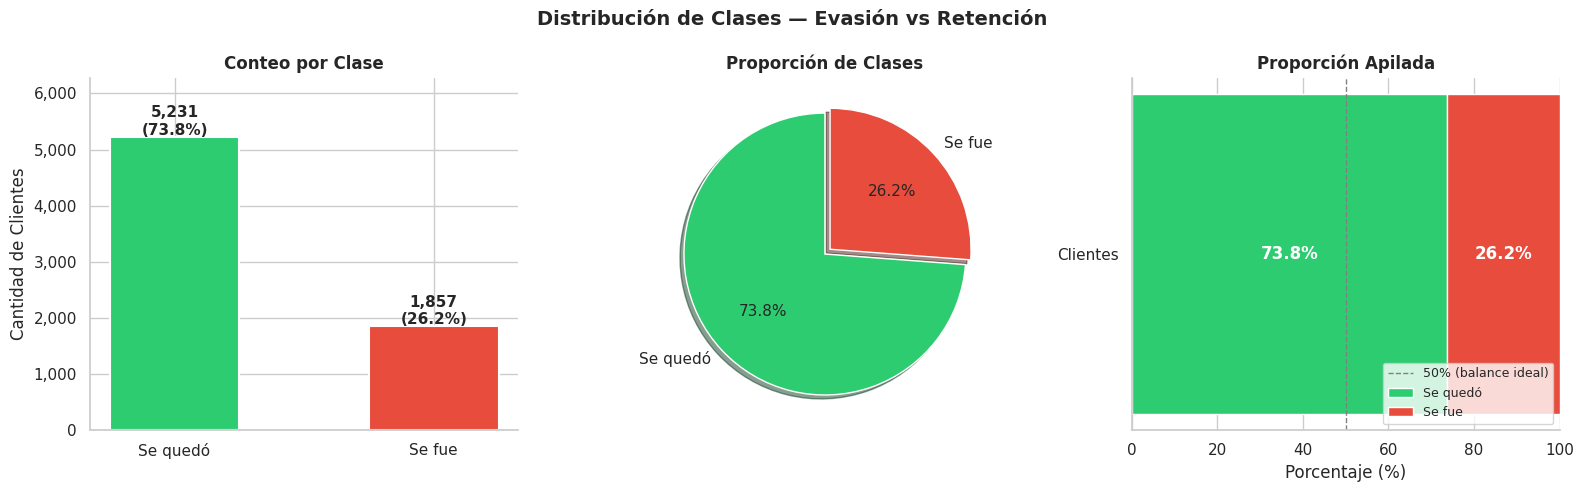

In [14]:
# ============================================================
# 4.3 — VISUALIZACIÓN DEL DESBALANCE
# ============================================================

seccion("4.3 — VISUALIZACIÓN")

try:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(
        'Distribución de Clases — Evasión vs Retención',
        fontsize=14, fontweight='bold'
    )

    COLORES   = ['#2ecc71', '#e74c3c']
    ETIQUETAS = ['Se quedó', 'Se fue']
    VALORES   = [retenidos, evadidos]
    PORCS     = [pct_ret, pct_evad]

    # ── Gráfica 1: Barras ─────────────────────────────────────
    try:
        ax1    = axes[0]
        barras = ax1.bar(ETIQUETAS, VALORES, color=COLORES,
                         width=0.5, edgecolor='white', linewidth=1.5)
        for barra, val, pct in zip(barras, VALORES, PORCS):
            ax1.text(
                barra.get_x() + barra.get_width() / 2,
                barra.get_height() + 30,
                f'{val:,}\n({pct}%)',
                ha='center', fontsize=11, fontweight='bold'
            )
        ax1.set_title('Conteo por Clase', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Cantidad de Clientes')
        ax1.set_ylim(0, max(VALORES) * 1.2)
        ax1.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
        )
        sns.despine(ax=ax1)
    except Exception as e:
        print(f"  ⚠️  Error en gráfica de barras: {e}")

    # ── Gráfica 2: Pie ────────────────────────────────────────
    try:
        ax2 = axes[1]
        ax2.pie(
            VALORES, labels=ETIQUETAS, colors=COLORES,
            autopct='%1.1f%%', startangle=90,
            explode=(0, 0.05), shadow=True,
            textprops={'fontsize': 11}
        )
        ax2.set_title('Proporción de Clases', fontsize=12, fontweight='bold')
    except Exception as e:
        print(f"  ⚠️  Error en pie chart: {e}")

    # ── Gráfica 3: Barras apiladas al 100% ───────────────────
    try:
        ax3 = axes[2]
        ax3.barh(['Clientes'], [pct_ret],  color='#2ecc71', label='Se quedó')
        ax3.barh(['Clientes'], [pct_evad], color='#e74c3c', label='Se fue',
                 left=[pct_ret])
        ax3.set_xlim(0, 100)
        ax3.set_xlabel('Porcentaje (%)')
        ax3.set_title('Proporción Apilada', fontsize=12, fontweight='bold')
        ax3.axvline(50, color='gray', linestyle='--',
                    linewidth=1, label='50% (balance ideal)')

        # Etiquetas dentro de la barra
        ax3.text(pct_ret / 2,       0, f'{pct_ret}%',
                 ha='center', va='center', fontsize=12,
                 fontweight='bold', color='white')
        ax3.text(pct_ret + pct_evad / 2, 0, f'{pct_evad}%',
                 ha='center', va='center', fontsize=12,
                 fontweight='bold', color='white')
        ax3.legend(fontsize=9, loc='lower right')
        sns.despine(ax=ax3)
    except Exception as e:
        print(f"  ⚠️  Error en barras apiladas: {e}")

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"  ❌ Error general en visualización: {e}")

###4.5 Decisión de Tratamiento del Desbalance

In [15]:
# ============================================================
# 4.4 — DECISIÓN DE TRATAMIENTO DEL DESBALANCE
# ============================================================

seccion("4.4 — ESTRATEGIA A APLICAR")

try:
    print("  Basado en el nivel de desbalance detectado,")
    print("  aplicaremos la siguiente estrategia en el modelado:\n")

    if pct_evad >= 40:
        print("  ✅ Sin tratamiento especial necesario.")
        print("     Se usarán métricas estándar.")
        estrategia_balanceo = 'ninguna'

    elif pct_evad >= 15:
        print("  🟡 Estrategia: class_weight='balanced'")
        print("     → Le da más peso a la clase minoritaria")
        print("       durante el entrenamiento sin modificar el dataset.")
        print("     → Compatible con Regresión Logística y Random Forest.")
        estrategia_balanceo = 'class_weight'

    else:
        print("  🔴 Estrategia: SMOTE (Synthetic Minority Oversampling)")
        print("     → Genera ejemplos sintéticos de la clase minoritaria.")
        print("     → Se aplica SOLO sobre el conjunto de entrenamiento.")
        estrategia_balanceo = 'smote'

    print(f"\n  📌 Variable guardada: estrategia_balanceo = '{estrategia_balanceo}'")


except Exception as e:
    print(f"  ❌ Error: {e}")


  4.4 — ESTRATEGIA A APLICAR
  Basado en el nivel de desbalance detectado,
  aplicaremos la siguiente estrategia en el modelado:

  🟡 Estrategia: class_weight='balanced'
     → Le da más peso a la clase minoritaria
       durante el entrenamiento sin modificar el dataset.
     → Compatible con Regresión Logística y Random Forest.

  📌 Variable guardada: estrategia_balanceo = 'class_weight'


####4.5.1 Instalación E importación

In [16]:
# ============================================================
# 4.5.1B — INSTALACIÓN E IMPORTACIÓN
# ============================================================

seccion("4.5.1B — INSTALACIÓN E IMPORTACIÓN")

try:
    import subprocess
    subprocess.run(['pip', 'install', 'imbalanced-learn', '-q'], check=True)
    print("  ✅ imbalanced-learn instalado correctamente")
except Exception as e:
    print(f"  ⚠️  Error instalando: {e}")

try:
    from imblearn.over_sampling  import SMOTE
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.pipeline       import Pipeline
    print("  ✅ Librerías de balanceo importadas correctamente")
except Exception as e:
    print(f"  ❌ Error importando librerías: {e}")


  4.5.1B — INSTALACIÓN E IMPORTACIÓN
  ✅ imbalanced-learn instalado correctamente
  ✅ Librerías de balanceo importadas correctamente


####4.5.2 Separar Features y Variables Objetivos

In [17]:
# ============================================================
# 4.5.2B.1 — SEPARAR FEATURES Y VARIABLE OBJETIVO
# ============================================================

seccion("4.5.2B.1 — SEPARAR X e y")

try:
    col_objetivo = [
        c for c in df.columns
        if 'evasi' in c.lower() or 'churn' in c.lower()
    ][0]

    X = df.drop(columns=[col_objetivo])
    y = df[col_objetivo]

    print(f"  📌 Variable objetivo  : '{col_objetivo}'")
    print(f"  📐 Shape X            : {X.shape}")
    print(f"  📐 Shape y            : {y.shape}")
    print(f"\n  📊 Distribución original:")
    for val, cnt in y.value_counts().items():
        pct   = round(cnt / len(y) * 100, 1)
        icono = "✅" if val == 0 else "❌"
        print(f"     {icono} Clase {val}: {cnt:,} ({pct}%)")

except IndexError:
    print("  ❌ No se encontró la columna objetivo")
except Exception as e:
    print(f"  ❌ Error: {e}")


  4.5.2B.1 — SEPARAR X e y
  📌 Variable objetivo  : 'Evasion'
  📐 Shape X            : (7088, 28)
  📐 Shape y            : (7088,)

  📊 Distribución original:
     ✅ Clase 0: 5,231 (73.8%)
     ❌ Clase 1: 1,857 (26.2%)


####4.5.3 SMOTE

In [18]:
# ============================================================
# 4.5.3B.2 — SMOTE (OVERSAMPLING)
# ============================================================

seccion("4.5.3B.2 — SMOTE (OVERSAMPLING)")

try:
    smote = SMOTE(random_state=42)
    X_smote, y_smote = smote.fit_resample(X, y)

    print("  ✅ SMOTE aplicado correctamente\n")
    print(f"  📐 Shape X original : {X.shape}  →  X_smote: {X_smote.shape}")
    print(f"  📐 Shape y original : {y.shape}  →  y_smote: {y_smote.shape}")
    print(f"\n  📊 Distribución después de SMOTE:")
    for val, cnt in pd.Series(y_smote).value_counts().items():
        pct   = round(cnt / len(y_smote) * 100, 1)
        barra = '█' * int(pct / 2)
        icono = "✅" if val == 0 else "❌"
        print(f"     {icono} Clase {val}: {cnt:,} ({pct}%)  {barra}")

    print(f"\n  💡 SMOTE genera ejemplos SINTÉTICOS de la clase minoritaria")
    print(f"     → Solo debe aplicarse sobre el conjunto de ENTRENAMIENTO")
    print(f"     → Nunca sobre el conjunto de TEST")

except Exception as e:
    print(f"  ❌ Error aplicando SMOTE: {e}")


  4.5.3B.2 — SMOTE (OVERSAMPLING)
  ✅ SMOTE aplicado correctamente

  📐 Shape X original : (7088, 28)  →  X_smote: (10462, 28)
  📐 Shape y original : (7088,)  →  y_smote: (10462,)

  📊 Distribución después de SMOTE:
     ✅ Clase 0: 5,231 (50.0%)  █████████████████████████
     ❌ Clase 1: 5,231 (50.0%)  █████████████████████████

  💡 SMOTE genera ejemplos SINTÉTICOS de la clase minoritaria
     → Solo debe aplicarse sobre el conjunto de ENTRENAMIENTO
     → Nunca sobre el conjunto de TEST


####4.5.4 Reducción de Clase Mayoritaria

In [19]:
# ============================================================
# 4.5.4B.3 — UNDERSAMPLING (REDUCCIÓN DE CLASE MAYORITARIA)
# ============================================================

seccion("4.5.4B.3 — UNDERSAMPLING")

try:
    under = RandomUnderSampler(random_state=42)
    X_under, y_under = under.fit_resample(X, y)

    print("  ✅ Undersampling aplicado correctamente\n")
    print(f"  📐 Shape X original  : {X.shape}  →  X_under: {X_under.shape}")
    print(f"  📐 Shape y original  : {y.shape}  →  y_under: {y_under.shape}")
    print(f"\n  📊 Distribución después de Undersampling:")
    for val, cnt in pd.Series(y_under).value_counts().items():
        pct   = round(cnt / len(y_under) * 100, 1)
        barra = '█' * int(pct / 2)
        icono = "✅" if val == 0 else "❌"
        print(f"     {icono} Clase {val}: {cnt:,} ({pct}%)  {barra}")

    perdidos = len(X) - len(X_under)
    print(f"\n  ⚠️  Se eliminaron {perdidos:,} registros de la clase mayoritaria")
    print(f"     → Útil cuando hay muchos datos — puede perder información")

except Exception as e:
    print(f"  ❌ Error aplicando Undersampling: {e}")


  4.5.4B.3 — UNDERSAMPLING
  ✅ Undersampling aplicado correctamente

  📐 Shape X original  : (7088, 28)  →  X_under: (3714, 28)
  📐 Shape y original  : (7088,)  →  y_under: (3714,)

  📊 Distribución después de Undersampling:
     ✅ Clase 0: 1,857 (50.0%)  █████████████████████████
     ❌ Clase 1: 1,857 (50.0%)  █████████████████████████

  ⚠️  Se eliminaron 3,374 registros de la clase mayoritaria
     → Útil cuando hay muchos datos — puede perder información


####4.5.5 Comparativa y Decisión final


  4.1B.4 — COMPARATIVA Y DECISIÓN FINAL


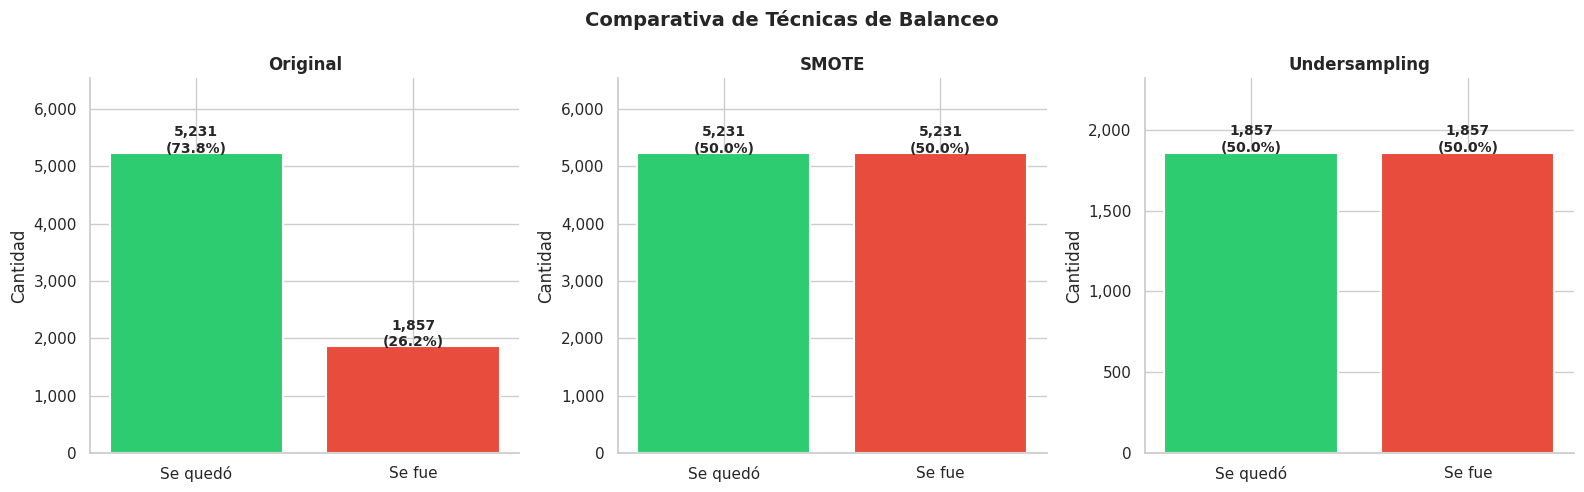


  Técnica               Total filas     % Clase 0     % Clase 1
  ------------------------------------------------------------
  Original                    7,088         73.8%         26.2%
  SMOTE                      10,462         50.0%         50.0%
  Undersampling               3,714         50.0%         50.0%

  📌 ¿Cuál usar?

     🔵 Original       → Si el desbalance es leve (<30% minoritaria)
                          y se usa class_weight='balanced'
     🟢 SMOTE          → Recomendado — no pierde datos, genera
                          ejemplos sintéticos de calidad
     🔴 Undersampling  → Solo si el dataset es muy grande y
                          puedes permitirte perder registros

  ✅ Para este proyecto usaremos: SMOTE
     → X_smote, y_smote como datos de entrenamiento
     👉 Siguiente paso: Normalización de Variables Numéricas



In [20]:
# ============================================================
# 4.5.5B.4 — COMPARATIVA Y DECISIÓN FINAL
# ============================================================

seccion("4.1B.4 — COMPARATIVA Y DECISIÓN FINAL")

try:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(
        'Comparativa de Técnicas de Balanceo',
        fontsize=14, fontweight='bold'
    )

    DATASETS = [
        ('Original',      y,       '#3498db'),
        ('SMOTE',         y_smote, '#2ecc71'),
        ('Undersampling', y_under, '#e74c3c'),
    ]

    for ax, (titulo, y_data, color) in zip(axes, DATASETS):
        try:
            conteo = pd.Series(y_data).value_counts().sort_index()
            barras = ax.bar(
                ['Se quedó', 'Se fue'],
                conteo.values,
                color=['#2ecc71', '#e74c3c'],
                edgecolor='white', linewidth=1.5
            )
            for barra, val in zip(barras, conteo.values):
                pct = round(val / conteo.sum() * 100, 1)
                ax.text(
                    barra.get_x() + barra.get_width() / 2,
                    barra.get_height() + 10,
                    f'{val:,}\n({pct}%)',
                    ha='center', fontsize=10, fontweight='bold'
                )
            ax.set_title(titulo, fontsize=12, fontweight='bold')
            ax.set_ylabel('Cantidad')
            ax.set_ylim(0, max(conteo.values) * 1.25)
            ax.yaxis.set_major_formatter(
                mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
            )
            sns.despine(ax=ax)
        except Exception as e:
            print(f"  ⚠️  Error graficando '{titulo}': {e}")

    plt.tight_layout()
    plt.show()

    # ── Tabla comparativa ──────────────────────────────────────
    print(f"\n  {'Técnica':<20} {'Total filas':>12}  {'% Clase 0':>12}  {'% Clase 1':>12}")
    print(f"  {'-'*60}")

    for titulo, y_data in [('Original', y), ('SMOTE', y_smote), ('Undersampling', y_under)]:
        try:
            conteo = pd.Series(y_data).value_counts().sort_index()
            total  = conteo.sum()
            p0     = round(conteo[0] / total * 100, 1)
            p1     = round(conteo[1] / total * 100, 1)
            print(f"  {titulo:<20} {total:>12,}  {p0:>11}%  {p1:>11}%")
        except Exception as e:
            print(f"  ⚠️  Error en '{titulo}': {e}")

    # ── Decisión ───────────────────────────────────────────────
    print(f"""
  📌 ¿Cuál usar?

     🔵 Original       → Si el desbalance es leve (<30% minoritaria)
                          y se usa class_weight='balanced'
     🟢 SMOTE          → Recomendado — no pierde datos, genera
                          ejemplos sintéticos de calidad
     🔴 Undersampling  → Solo si el dataset es muy grande y
                          puedes permitirte perder registros

  ✅ Para este proyecto usaremos: SMOTE
     → X_smote, y_smote como datos de entrenamiento
     👉 Siguiente paso: Normalización de Variables Numéricas
""")

except Exception as e:
    print(f"  ❌ Error: {e}")

#Paso 5. Normalización o Estandarización

###5.1 Diagnóstico de Escalas

In [21]:
# ============================================================
# 5.1 — DIAGNÓSTICO DE ESCALAS
# ============================================================

seccion("5.1 — DIAGNÓSTICO DE ESCALAS")

try:
    cols_num = X.select_dtypes(include=np.number).columns.tolist()

    resumen_escala = []
    for col in cols_num:
        try:
            serie = X[col].dropna()
            resumen_escala.append({
                'Columna' : col,
                'Mínimo'  : round(serie.min(), 2),
                'Máximo'  : round(serie.max(), 2),
                'Media'   : round(serie.mean(), 2),
                'Std'     : round(serie.std(), 2),
                'Rango'   : round(serie.max() - serie.min(), 2)
            })
        except Exception as e_col:
            print(f"  ⚠️  Error en '{col}': {e_col}")

    df_escala = pd.DataFrame(resumen_escala).set_index('Columna')
    display(df_escala)

    # ── Detectar columnas con escalas muy diferentes ──────────
    rango_max = df_escala['Rango'].max()
    rango_min = df_escala['Rango'].min()
    diferencia = round(rango_max / rango_min, 1) if rango_min > 0 else 999

    print(f"\n  📌 Rango mayor  : {rango_max}")
    print(f"  📌 Rango menor  : {rango_min}")
    print(f"  📌 Diferencia   : {diferencia}x entre columnas")

    if diferencia > 10:
        print("\n  ⚠️  Escalas muy diferentes — normalización recomendada")
    else:
        print("\n  ✅ Escalas similares — normalización opcional")

except Exception as e:
    print(f"  ❌ Error: {e}")


  5.1 — DIAGNÓSTICO DE ESCALAS


,Mínimo,Máximo,Media,Std,Rango
Columna,,,,,
Genero,0.00,1.00,0.50,0.50,1.0
Adulto_Mayor,0.00,1.00,0.16,0.37,1.0
customer.tenure,0.00,72.00,32.36,24.53,72.0
Cargo_Mensual,18.25,118.75,64.92,30.05,100.5
Cargo_Total,18.80,8684.80,2284.48,2264.85,8666.0
Lineas_Multiples_Si,0.00,1.00,0.42,0.49,1.0
Lineas_Multiples_Sin Servicio,0.00,1.00,0.10,0.30,1.0
Tipo_Internet_Fibra Optica,0.00,1.00,0.44,0.50,1.0
Tipo_Internet_Sin Internet,0.00,1.00,0.21,0.41,1.0



  📌 Rango mayor  : 8666.0
  📌 Rango menor  : 1.0
  📌 Diferencia   : 8666.0x entre columnas

  ⚠️  Escalas muy diferentes — normalización recomendada


###5.2 Decisión de Normalización Según Modelo

In [22]:
# ============================================================
# 5.2 — DECISIÓN DE NORMALIZACIÓN SEGÚN MODELO
# ============================================================

seccion("5.2 — DECISIÓN SEGÚN TIPO DE MODELO")

try:
    print("""
  ┌─────────────────────────────────────────────────────────┐
  │           SENSIBILIDAD A LA ESCALA POR MODELO           │
  ├──────────────────────────────┬──────────────────────────┤
  │  🔴 REQUIEREN ESCALA         │  🟢 NO REQUIEREN ESCALA  │
  ├──────────────────────────────┼──────────────────────────┤
  │  Regresión Logística         │  Decision Tree           │
  │  KNN                         │  Random Forest           │
  │  SVM                         │  XGBoost                 │
  │  Redes Neuronales            │  LightGBM                │
  │  PCA                         │  CatBoost                │
  └──────────────────────────────┴──────────────────────────┘

  📌 Para este proyecto usaremos:
     → Regresión Logística  🔴 Requiere escala
     → Random Forest        🟢 No requiere escala

  ✅ Aplicaremos StandardScaler para compatibilidad
     con la Regresión Logística.
     Random Forest usará los datos sin escalar.
""")

    APLICAR_NORMALIZACION = True
    print(f"  📌 Variable guardada: APLICAR_NORMALIZACION = {APLICAR_NORMALIZACION}")

except Exception as e:
    print(f"  ❌ Error: {e}")


  5.2 — DECISIÓN SEGÚN TIPO DE MODELO

  ┌─────────────────────────────────────────────────────────┐
  │           SENSIBILIDAD A LA ESCALA POR MODELO           │
  ├──────────────────────────────┬──────────────────────────┤
  │  🔴 REQUIEREN ESCALA         │  🟢 NO REQUIEREN ESCALA  │
  ├──────────────────────────────┼──────────────────────────┤
  │  Regresión Logística         │  Decision Tree           │
  │  KNN                         │  Random Forest           │
  │  SVM                         │  XGBoost                 │
  │  Redes Neuronales            │  LightGBM                │
  │  PCA                         │  CatBoost                │
  └──────────────────────────────┴──────────────────────────┘

  📌 Para este proyecto usaremos:
     → Regresión Logística  🔴 Requiere escala
     → Random Forest        🟢 No requiere escala

  ✅ Aplicaremos StandardScaler para compatibilidad
     con la Regresión Logística.
     Random Forest usará los datos sin escalar.

  📌 Variable guar

###5.3 Aplicar Standardscaler

In [23]:
# ============================================================
# 5.3 — APLICAR STANDARDSCALER
# ============================================================

seccion("5.3 — ESTANDARIZACIÓN CON STANDARDSCALER")

try:
    from sklearn.preprocessing import StandardScaler

    cols_escalar = X.select_dtypes(include=np.number).columns.tolist()

    scaler   = StandardScaler()

    # ── Escalar datos originales ───────────────────────────────
    X_scaled              = X.copy()
    X_scaled[cols_escalar] = scaler.fit_transform(X[cols_escalar])

    # ── Escalar datos SMOTE ────────────────────────────────────
    X_smote_scaled              = pd.DataFrame(X_smote, columns=X.columns)
    X_smote_scaled[cols_escalar] = scaler.transform(X_smote_scaled[cols_escalar])

    print(f"  ✅ StandardScaler aplicado a {len(cols_escalar)} columna(s):")
    for col in cols_escalar:
        print(f"     → '{col}'")

    print(f"""
  📌 ¿Qué hace StandardScaler?
     → Resta la media y divide por la desviación estándar
     → Resultado: media ≈ 0, desviación estándar ≈ 1
     → Fórmula: z = (x - μ) / σ

  ⚠️  Importante:
     → fit_transform() se aplica SOLO sobre X de entrenamiento
     → transform() se aplica sobre X_test y X_smote
     → Nunca hacer fit sobre datos de test — evita data leakage
""")

except Exception as e:
    print(f"  ❌ Error aplicando StandardScaler: {e}")


  5.3 — ESTANDARIZACIÓN CON STANDARDSCALER
  ✅ StandardScaler aplicado a 24 columna(s):
     → 'Genero'
     → 'Adulto_Mayor'
     → 'customer.tenure'
     → 'Cargo_Mensual'
     → 'Cargo_Total'
     → 'Lineas_Multiples_Si'
     → 'Lineas_Multiples_Sin Servicio'
     → 'Tipo_Internet_Fibra Optica'
     → 'Tipo_Internet_Sin Internet'
     → 'Backup_Online_Sin Internet'
     → 'Backup_Online_Yes'
     → 'Proteccion_Dispositivo_Sin Internet'
     → 'Proteccion_Dispositivo_Yes'
     → 'Soporte_Tecnico_Sin Internet'
     → 'Soporte_Tecnico_Yes'
     → 'Streaming_TV_Sin Internet'
     → 'Streaming_TV_Yes'
     → 'Streaming_Peliculas_Sin Internet'
     → 'Streaming_Peliculas_Yes'
     → 'Tipo_Contrato_Mes a Mes'
     → 'Tipo_Contrato_Un Año'
     → 'Metodo_Pago_Cheque por Correo'
     → 'Metodo_Pago_Tarjeta de Credito'
     → 'Metodo_Pago_Transferencia Bancaria'

  📌 ¿Qué hace StandardScaler?
     → Resta la media y divide por la desviación estándar
     → Resultado: media ≈ 0, desviación es

###5.4 Comparativa Antes y Después


  5.4 — COMPARATIVA ANTES / DESPUÉS


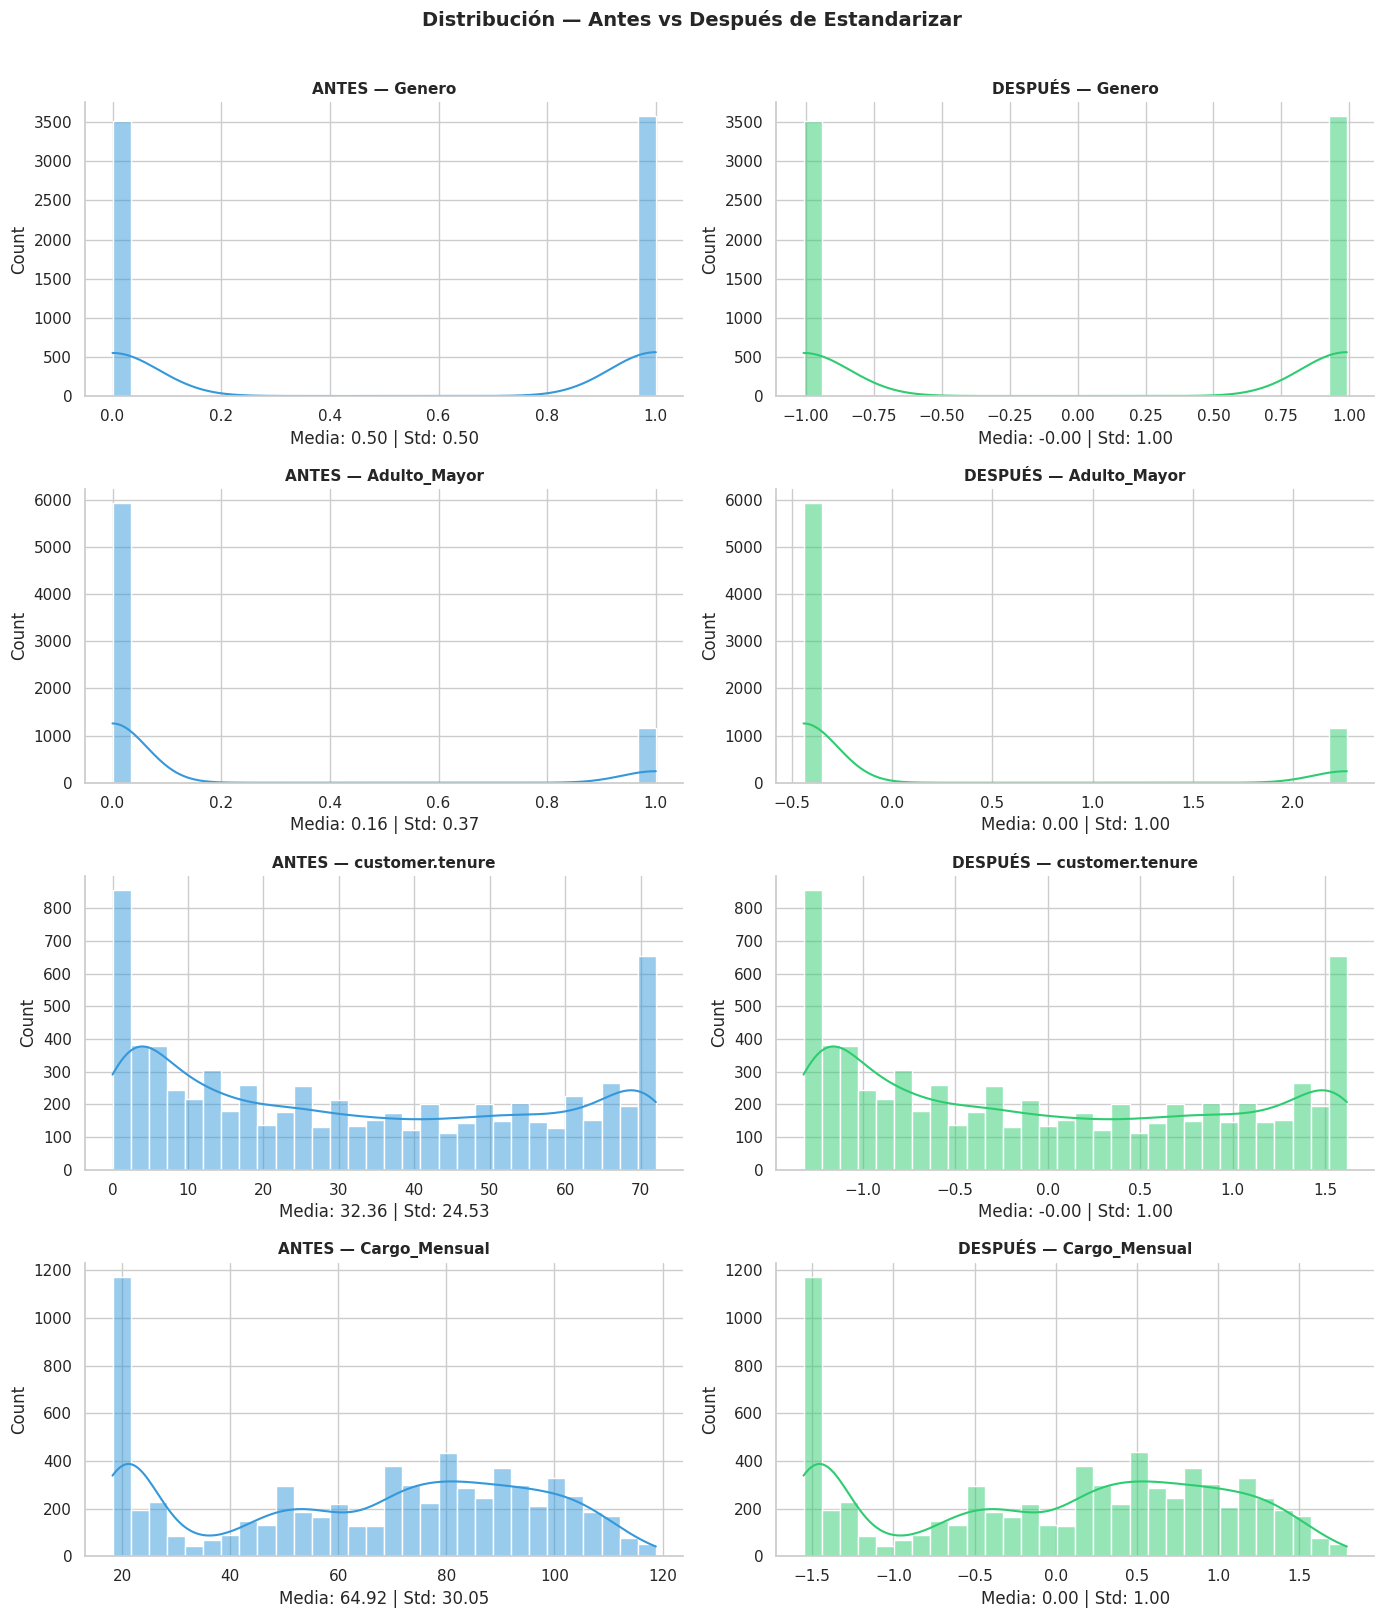

In [24]:
# ============================================================
# 5.4 — COMPARATIVA ANTES Y DESPUÉS DE ESCALAR
# ============================================================

seccion("5.4 — COMPARATIVA ANTES / DESPUÉS")

try:
    cols_plot = cols_escalar[:4]  # Mostrar máximo 4 columnas

    fig, axes = plt.subplots(
        nrows=len(cols_plot), ncols=2,
        figsize=(14, 4 * len(cols_plot))
    )
    fig.suptitle(
        'Distribución — Antes vs Después de Estandarizar',
        fontsize=14, fontweight='bold', y=1.01
    )

    for i, col in enumerate(cols_plot):
        try:
            # ── Antes ─────────────────────────────────────────
            ax1 = axes[i][0]
            sns.histplot(X[col].dropna(), kde=True, ax=ax1,
                         color='#3498db', bins=30)
            ax1.set_title(f'ANTES — {col}', fontsize=11, fontweight='bold')
            ax1.set_xlabel(f'Media: {X[col].mean():.2f} | Std: {X[col].std():.2f}')
            sns.despine(ax=ax1)

            # ── Después ────────────────────────────────────────
            ax2 = axes[i][1]
            sns.histplot(X_scaled[col].dropna(), kde=True, ax=ax2,
                         color='#2ecc71', bins=30)
            ax2.set_title(f'DESPUÉS — {col}', fontsize=11, fontweight='bold')
            ax2.set_xlabel(
                f'Media: {X_scaled[col].mean():.2f} | '
                f'Std: {X_scaled[col].std():.2f}'
            )
            sns.despine(ax=ax2)

        except Exception as e_col:
            print(f"  ⚠️  Error graficando '{col}': {e_col}")

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"  ❌ Error en comparativa: {e}")

### 5.5 Resumen Final de Normalización

In [25]:
# ============================================================
# 5.5 — RESUMEN FINAL
# ============================================================

seccion("5.5 — RESUMEN FINAL DE NORMALIZACIÓN")

try:
    print(f"""
  📦 Variables disponibles para el modelado:

  ┌─────────────────────────────────────────────────────────┐
  │  Variable         │ Descripción                         │
  ├─────────────────────────────────────────────────────────┤
  │  X                │ Features originales sin escalar      │
  │  X_scaled         │ Features estandarizadas (μ=0, σ=1)  │
  │  X_smote          │ Features con SMOTE sin escalar       │
  │  X_smote_scaled   │ Features con SMOTE estandarizadas    │
  │  y                │ Variable objetivo original           │
  │  y_smote          │ Variable objetivo con SMOTE          │
  └─────────────────────────────────────────────────────────┘

  🔢 Shape X               : {X.shape}
  🔢 Shape X_scaled        : {X_scaled.shape}
  🔢 Shape X_smote         : {X_smote.shape}
  🔢 Shape X_smote_scaled  : {X_smote_scaled.shape}

  📌 Uso por modelo:
     → Regresión Logística : X_smote_scaled  +  y_smote
     → Random Forest       : X_smote         +  y_smote
""")

except Exception as e:
    print(f"  ❌ Error: {e}")


  5.5 — RESUMEN FINAL DE NORMALIZACIÓN

  📦 Variables disponibles para el modelado:

  ┌─────────────────────────────────────────────────────────┐
  │  Variable         │ Descripción                         │
  ├─────────────────────────────────────────────────────────┤
  │  X                │ Features originales sin escalar      │
  │  X_scaled         │ Features estandarizadas (μ=0, σ=1)  │
  │  X_smote          │ Features con SMOTE sin escalar       │
  │  X_smote_scaled   │ Features con SMOTE estandarizadas    │
  │  y                │ Variable objetivo original           │
  │  y_smote          │ Variable objetivo con SMOTE          │
  └─────────────────────────────────────────────────────────┘

  🔢 Shape X               : (7088, 28)
  🔢 Shape X_scaled        : (7088, 28)
  🔢 Shape X_smote         : (10462, 28)
  🔢 Shape X_smote_scaled  : (10462, 28)

  📌 Uso por modelo:
     → Regresión Logística : X_smote_scaled  +  y_smote
     → Random Forest       : X_smote         +  y_smo

#Paso 6. Análisis de Correlación

###6.1 Matriz de Corellación General

In [26]:
# ============================================================
# 6.1 — MATRIZ DE CORRELACIÓN GENERAL
# ============================================================

seccion("6.1 — MATRIZ DE CORRELACIÓN GENERAL")

try:
    # Usar X con la variable objetivo incluida
    df_corr = X.copy()
    df_corr[col_objetivo] = y.values

    matriz_corr = df_corr.corr()

    print(f"  📐 Matriz de correlación: {matriz_corr.shape}")
    print(f"  📌 Total de variables   : {len(matriz_corr.columns)}")

    display(matriz_corr.round(2))

except Exception as e:
    print(f"  ❌ Error: {e}")


  6.1 — MATRIZ DE CORRELACIÓN GENERAL
  📐 Matriz de correlación: (29, 29)
  📌 Total de variables   : 29


,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,customer.tenure,Servicio_Telefono,Factura_Digital,Cargo_Mensual,Cargo_Total,Lineas_Multiples_Si,...,Streaming_TV_Sin Internet,Streaming_TV_Yes,Streaming_Peliculas_Sin Internet,Streaming_Peliculas_Yes,Tipo_Contrato_Mes a Mes,Tipo_Contrato_Un Año,Metodo_Pago_Cheque por Correo,Metodo_Pago_Tarjeta de Credito,Metodo_Pago_Transferencia Bancaria,Evasion
Genero,1.00,-0.00,-0.00,0.01,0.01,-0.01,-0.01,-0.01,0.00,-0.01,...,0.00,-0.01,0.00,-0.01,-0.00,0.01,0.01,0.00,-0.02,-0.01
Adulto_Mayor,-0.00,1.00,0.02,-0.21,0.01,0.01,0.16,0.22,0.10,0.14,...,-0.18,0.10,-0.18,0.12,0.14,-0.05,-0.15,-0.03,-0.02,0.15
Tiene_Pareja,-0.00,0.02,1.00,0.45,0.38,0.02,-0.02,0.09,0.32,0.14,...,0.00,0.12,0.00,0.11,-0.28,0.08,-0.09,0.08,0.11,-0.15
Tiene_Dependientes,0.01,-0.21,0.45,1.00,0.16,0.00,-0.11,-0.12,0.06,-0.03,...,0.14,-0.02,0.14,-0.04,-0.23,0.07,0.06,0.06,0.05,-0.16
customer.tenure,0.01,0.01,0.38,0.16,1.00,0.01,0.00,0.25,0.83,0.33,...,-0.03,0.28,-0.03,0.28,-0.64,0.20,-0.23,0.23,0.24,-0.35
Servicio_Telefono,-0.01,0.01,0.02,0.00,0.01,1.00,0.02,0.25,0.12,0.28,...,0.17,-0.02,0.17,-0.03,-0.00,-0.00,-0.00,-0.01,0.01,0.01
Factura_Digital,-0.01,0.16,-0.02,-0.11,0.00,0.02,1.00,0.35,0.16,0.16,...,-0.32,0.22,-0.32,0.21,0.17,-0.05,-0.20,-0.02,-0.02,0.19
Cargo_Mensual,-0.01,0.22,0.09,-0.12,0.25,0.25,0.35,1.00,0.65,0.49,...,-0.76,0.63,-0.76,0.63,0.06,0.00,-0.37,0.03,0.04,0.19
Cargo_Total,0.00,0.10,0.32,0.06,0.83,0.12,0.16,0.65,1.00,0.47,...,-0.37,0.51,-0.37,0.52,-0.44,0.17,-0.29,0.18,0.18,-0.20
Lineas_Multiples_Si,-0.01,0.14,0.14,-0.03,0.33,0.28,0.16,0.49,0.47,1.00,...,-0.21,0.25,-0.21,0.26,-0.09,-0.00,-0.23,0.06,0.07,0.04


###6.2 Heatmap de Correlación Completo


  6.2 — HEATMAP DE CORRELACIÓN


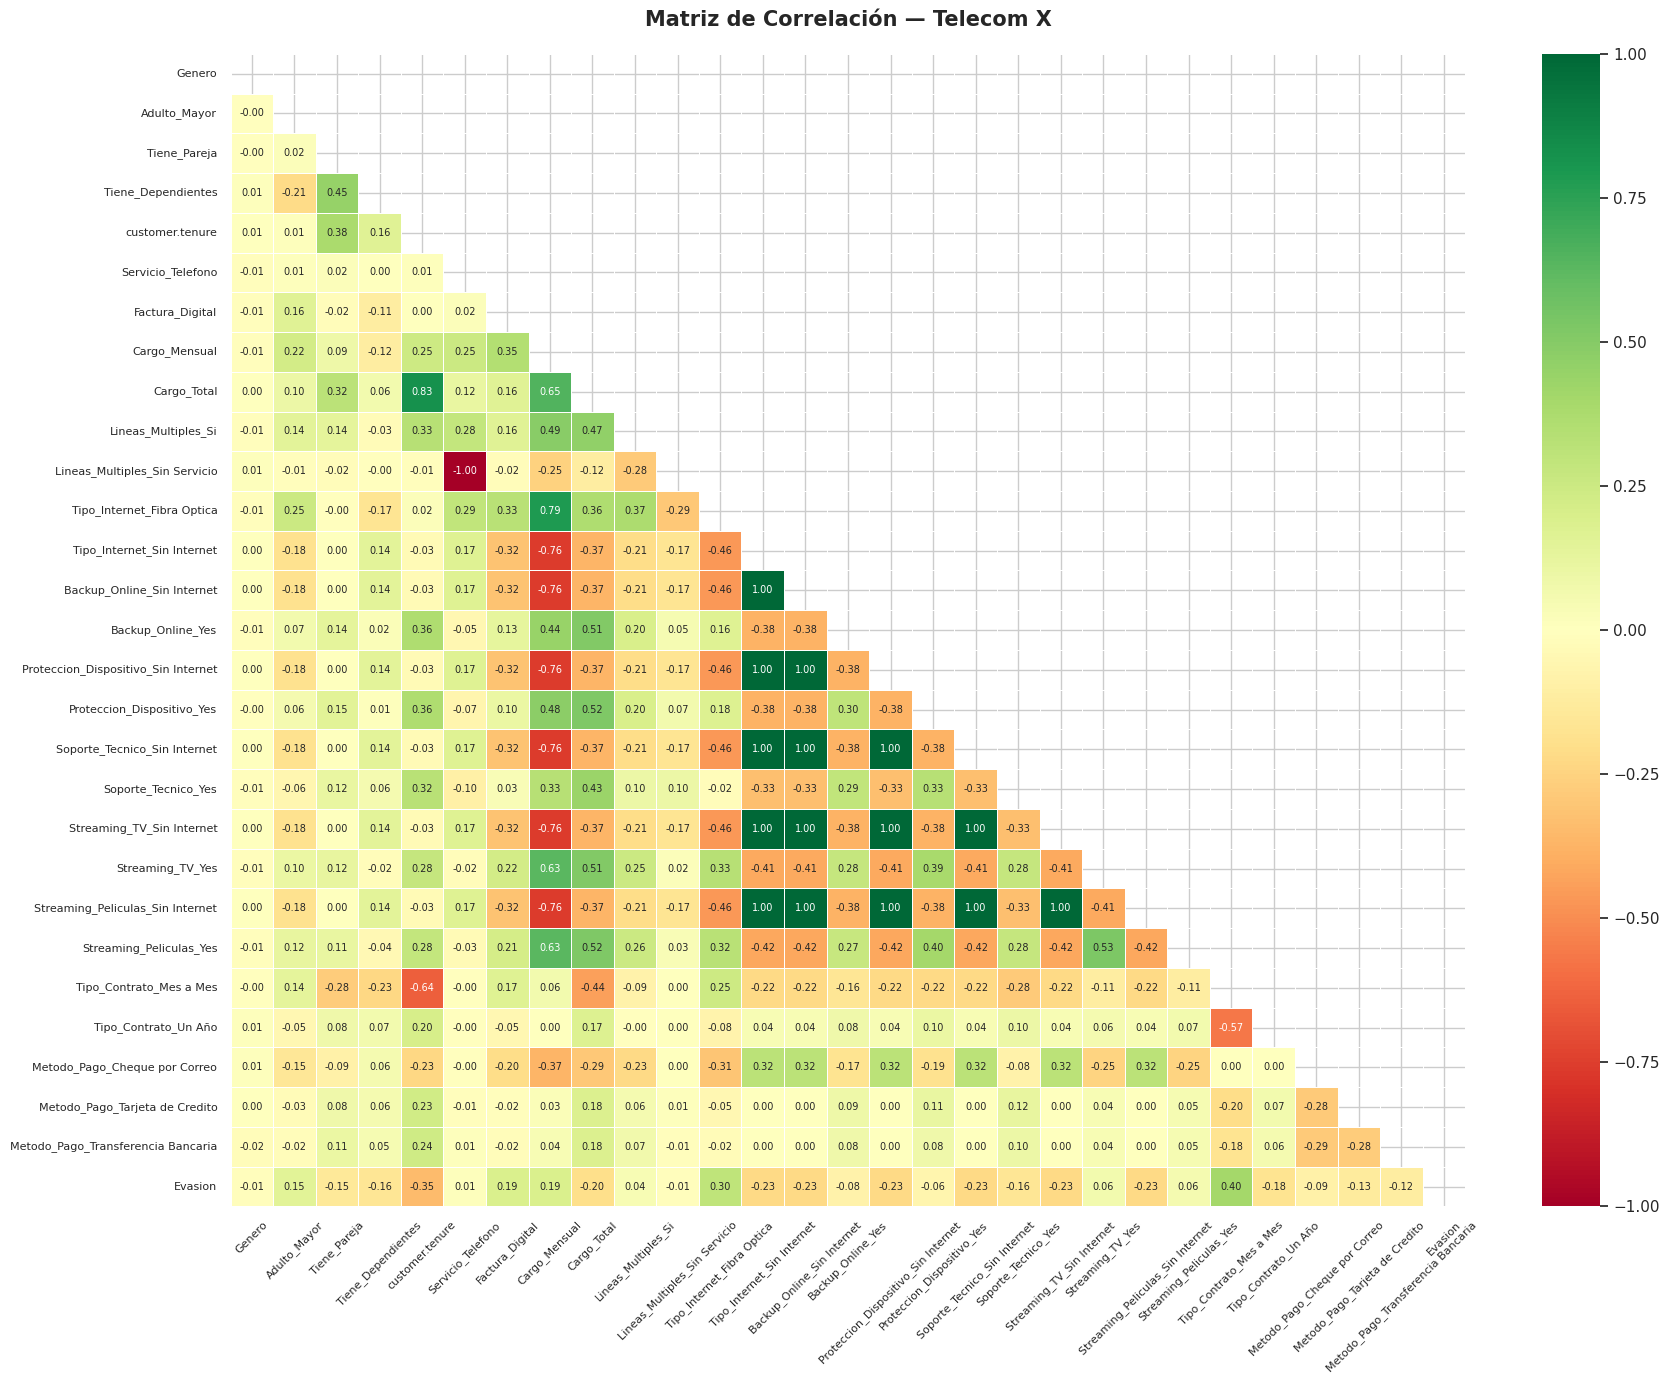

In [27]:
# ============================================================
# 6.2 — HEATMAP DE CORRELACIÓN COMPLETO
# ============================================================

seccion("6.2 — HEATMAP DE CORRELACIÓN")

try:
    fig, ax = plt.subplots(figsize=(18, 14))

    # Máscara para triángulo superior (evita duplicados)
    mascara = np.triu(np.ones_like(matriz_corr, dtype=bool))

    sns.heatmap(
        matriz_corr,
        mask=mascara,
        annot=True,
        fmt='.2f',
        cmap='RdYlGn',
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.5,
        linecolor='white',
        annot_kws={'size': 7},
        ax=ax
    )

    ax.set_title(
        'Matriz de Correlación — Telecom X',
        fontsize=15, fontweight='bold', pad=20
    )
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"  ❌ Error en heatmap: {e}")

###6.4 Correlación con la Variable Objetivo

In [28]:
# ============================================================
# 6.3 — CORRELACIÓN CON LA VARIABLE OBJETIVO
# ============================================================

seccion("6.3 — CORRELACIÓN CON 'Evasion'")

try:
    corr_objetivo = (
        matriz_corr[col_objetivo]
        .drop(col_objetivo)
        .sort_values(key=abs, ascending=False)
    )

    print(f"  📌 Correlación de cada variable con '{col_objetivo}':\n")
    print(f"  {'Variable':<40} {'Correlación':>12}  {'Nivel'}")
    print(f"  {'-'*70}")

    for var, corr in corr_objetivo.items():
        abs_corr = abs(corr)
        if abs_corr >= 0.5:
            nivel = "🔴 Alta"
        elif abs_corr >= 0.3:
            nivel = "🟠 Moderada"
        elif abs_corr >= 0.1:
            nivel = "🟡 Baja"
        else:
            nivel = "⚪ Muy baja"

        direccion = "⬆️" if corr > 0 else "⬇️"
        print(f"  {var:<40} {corr:>12.4f}  {nivel} {direccion}")

except Exception as e:
    print(f"  ❌ Error: {e}")


  6.3 — CORRELACIÓN CON 'Evasion'
  📌 Correlación de cada variable con 'Evasion':

  Variable                                  Correlación  Nivel
  ----------------------------------------------------------------------
  Tipo_Contrato_Mes a Mes                        0.3991  🟠 Moderada ⬆️
  customer.tenure                               -0.3467  🟠 Moderada ⬇️
  Tipo_Internet_Fibra Optica                     0.3038  🟠 Moderada ⬆️
  Tipo_Internet_Sin Internet                    -0.2256  🟡 Baja ⬇️
  Backup_Online_Sin Internet                    -0.2256  🟡 Baja ⬇️
  Streaming_Peliculas_Sin Internet              -0.2256  🟡 Baja ⬇️
  Soporte_Tecnico_Sin Internet                  -0.2256  🟡 Baja ⬇️
  Streaming_TV_Sin Internet                     -0.2256  🟡 Baja ⬇️
  Proteccion_Dispositivo_Sin Internet           -0.2256  🟡 Baja ⬇️
  Cargo_Total                                   -0.1955  🟡 Baja ⬇️
  Cargo_Mensual                                  0.1920  🟡 Baja ⬆️
  Factura_Digital              

###6.4 Gráfica de Correlación con Variable Objetivo


  6.4 — GRÁFICA DE CORRELACIÓN CON OBJETIVO


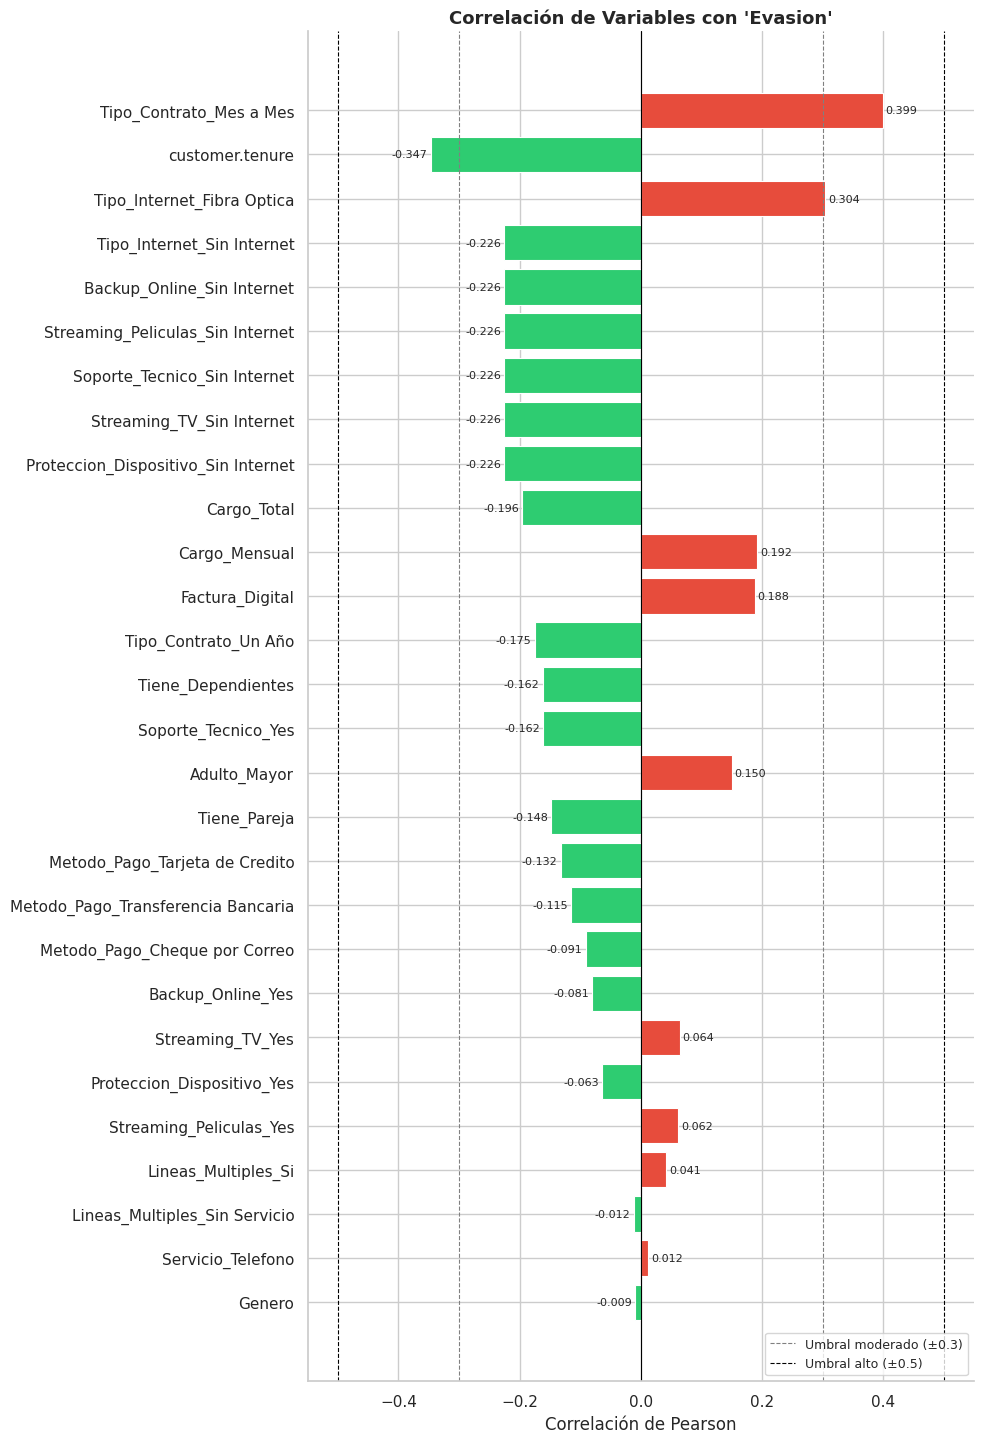

In [29]:
# ============================================================
# 6.4 — GRÁFICA DE CORRELACIÓN CON VARIABLE OBJETIVO
# ============================================================

seccion("6.4 — GRÁFICA DE CORRELACIÓN CON OBJETIVO")

try:
    fig, ax = plt.subplots(figsize=(10, len(corr_objetivo) * 0.45 + 2))

    colores = ['#e74c3c' if v > 0 else '#2ecc71' for v in corr_objetivo.values]

    barras = ax.barh(
        corr_objetivo.index,
        corr_objetivo.values,
        color=colores,
        edgecolor='white',
        linewidth=0.8
    )

    # Líneas de referencia
    ax.axvline(0,    color='black', linewidth=0.8)
    ax.axvline( 0.3, color='gray',  linewidth=0.8,
                linestyle='--', label='Umbral moderado (±0.3)')
    ax.axvline(-0.3, color='gray',  linewidth=0.8, linestyle='--')
    ax.axvline( 0.5, color='black', linewidth=0.8,
                linestyle='--', label='Umbral alto (±0.5)')
    ax.axvline(-0.5, color='black', linewidth=0.8, linestyle='--')

    # Etiquetas en cada barra
    for barra, val in zip(barras, corr_objetivo.values):
        ax.text(
            val + (0.005 if val >= 0 else -0.005),
            barra.get_y() + barra.get_height() / 2,
            f'{val:.3f}',
            va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=8
        )

    ax.set_title(
        f'Correlación de Variables con \'{col_objetivo}\'',
        fontsize=13, fontweight='bold'
    )
    ax.set_xlabel('Correlación de Pearson')
    ax.legend(fontsize=9, loc='lower right')
    ax.invert_yaxis()
    sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"  ❌ Error en gráfica: {e}")

### 6.5 Detección de Multicolinealidad

In [30]:
# ============================================================
# 6.5 — DETECCIÓN DE MULTICOLINEALIDAD ENTRE FEATURES
# ============================================================

seccion("6.5 — MULTICOLINEALIDAD ENTRE FEATURES")

try:
    UMBRAL_MULTICOL = 0.85
    pares_problematicos = []

    cols_features = [c for c in matriz_corr.columns if c != col_objetivo]

    for i, col1 in enumerate(cols_features):
        for col2 in cols_features[i+1:]:
            try:
                corr_val = abs(matriz_corr.loc[col1, col2])
                if corr_val >= UMBRAL_MULTICOL:
                    pares_problematicos.append({
                        'Variable 1'    : col1,
                        'Variable 2'    : col2,
                        'Correlación'   : round(corr_val, 4),
                        'Riesgo'        : '🔴 Alta' if corr_val >= 0.95 else '🟠 Moderada'
                    })
            except Exception:
                continue

    if not pares_problematicos:
        print(f"  ✅ No se detectó multicolinealidad crítica (umbral: {UMBRAL_MULTICOL})")
    else:
        print(f"  ⚠️  {len(pares_problematicos)} par(es) con alta correlación entre sí:\n")
        df_multi = pd.DataFrame(pares_problematicos).sort_values(
            'Correlación', ascending=False
        )
        display(df_multi)
        print(f"""
  💡 ¿Qué hacer con variables multicolineales?
     → Eliminar una de las dos (la de menor correlación con '{col_objetivo}')
     → O aplicar PCA para reducir dimensionalidad
     → Random Forest tolera multicolinealidad mejor que Regresión Logística
""")

except Exception as e:
    print(f"  ❌ Error en multicolinealidad: {e}")


  6.5 — MULTICOLINEALIDAD ENTRE FEATURES
  ⚠️  16 par(es) con alta correlación entre sí:



,Variable 1,Variable 2,Correlación,Riesgo
0,Servicio_Telefono,Lineas_Multiples_Sin Servicio,1.0,🔴 Alta
1,Tipo_Internet_Sin Internet,Backup_Online_Sin Internet,1.0,🔴 Alta
2,Tipo_Internet_Sin Internet,Proteccion_Dispositivo_Sin Internet,1.0,🔴 Alta
3,Tipo_Internet_Sin Internet,Soporte_Tecnico_Sin Internet,1.0,🔴 Alta
4,Tipo_Internet_Sin Internet,Streaming_TV_Sin Internet,1.0,🔴 Alta
5,Tipo_Internet_Sin Internet,Streaming_Peliculas_Sin Internet,1.0,🔴 Alta
6,Backup_Online_Sin Internet,Proteccion_Dispositivo_Sin Internet,1.0,🔴 Alta
7,Backup_Online_Sin Internet,Soporte_Tecnico_Sin Internet,1.0,🔴 Alta
8,Backup_Online_Sin Internet,Streaming_TV_Sin Internet,1.0,🔴 Alta
9,Backup_Online_Sin Internet,Streaming_Peliculas_Sin Internet,1.0,🔴 Alta



  💡 ¿Qué hacer con variables multicolineales?
     → Eliminar una de las dos (la de menor correlación con 'Evasion')
     → O aplicar PCA para reducir dimensionalidad
     → Random Forest tolera multicolinealidad mejor que Regresión Logística



###6.6 Resumen de Hallazgos de la correlación

In [32]:
# ============================================================
# 6.6 — RESUMEN DE HALLAZGOS DE CORRELACIÓN
# ============================================================

seccion("6.6 — RESUMEN DE HALLAZGOS")

try:
    top_positivas = corr_objetivo[corr_objetivo > 0].head(5)
    top_negativas = corr_objetivo[corr_objetivo < 0].head(5)

    print("  🔴 Variables que MÁS aumentan la probabilidad de evasión:\n")
    for var, val in top_positivas.items():
        print(f"     ⬆️  '{var}': {val:.4f}")

    print("\n  🟢 Variables que MÁS reducen la probabilidad de evasión:\n")
    for var, val in top_negativas.items():
        print(f"     ⬇️  '{var}': {val:.4f}")

    print(f"""
  📌 Variables seleccionadas para el modelo:
     → Las de correlación |r| > 0.1 con '{col_objetivo}'
     → Eliminando pares multicolineales si los hay


""")

    # Guardar top variables para el modelado
    vars_relevantes = corr_objetivo[abs(corr_objetivo) > 0.1].index.tolist()
    print(f"  📦 'vars_relevantes' guardado: {len(vars_relevantes)} variable(s)")

except Exception as e:
    print(f"  ❌ Error: {e}")


  6.6 — RESUMEN DE HALLAZGOS
  🔴 Variables que MÁS aumentan la probabilidad de evasión:

     ⬆️  'Tipo_Contrato_Mes a Mes': 0.3991
     ⬆️  'Tipo_Internet_Fibra Optica': 0.3038
     ⬆️  'Cargo_Mensual': 0.1920
     ⬆️  'Factura_Digital': 0.1880
     ⬆️  'Adulto_Mayor': 0.1498

  🟢 Variables que MÁS reducen la probabilidad de evasión:

     ⬇️  'customer.tenure': -0.3467
     ⬇️  'Tipo_Internet_Sin Internet': -0.2256
     ⬇️  'Backup_Online_Sin Internet': -0.2256
     ⬇️  'Streaming_Peliculas_Sin Internet': -0.2256
     ⬇️  'Soporte_Tecnico_Sin Internet': -0.2256

  📌 Variables seleccionadas para el modelo:
     → Las de correlación |r| > 0.1 con 'Evasion'
     → Eliminando pares multicolineales si los hay

 

  📦 'vars_relevantes' guardado: 19 variable(s)


#Paso 7. Análisis Dirigido

###7.1 Tiempo de Contrato x Cancelación

In [33]:
# ============================================================
# 7.1 — TIEMPO DE CONTRATO × CANCELACIÓN
# ============================================================

seccion("7.1 — TIEMPO DE CONTRATO × CANCELACIÓN")

try:
    col_tenure = [
        c for c in X.columns
        if 'tenure' in c.lower() or 'meses' in c.lower()
    ][0]

    df_analisis = X.copy()
    df_analisis[col_objetivo] = y.values
    df_analisis['Grupo'] = df_analisis[col_objetivo].map({
        0: 'Se quedó ✅', 1: 'Se fue ❌'
    })

    # ── Estadísticas por grupo ─────────────────────────────────
    stats = df_analisis.groupby('Grupo')[col_tenure].agg([
        'mean', 'median', 'std', 'min', 'max'
    ]).round(2)
    stats.columns = ['Media', 'Mediana', 'Std', 'Mínimo', 'Máximo']
    display(stats)

except IndexError:
    print("  ❌ No se encontró columna de tiempo de contrato")
except Exception as e:
    print(f"  ❌ Error: {e}")


  7.1 — TIEMPO DE CONTRATO × CANCELACIÓN


,Media,Mediana,Std,Mínimo,Máximo
Grupo,,,,,
Se fue ❌,18.09,10.0,19.55,1,72
Se quedó ✅,37.43,37.0,24.12,0,72


###7.2 Grafica de tiempo de Contrato



  7.2 — GRÁFICAS TIEMPO DE CONTRATO


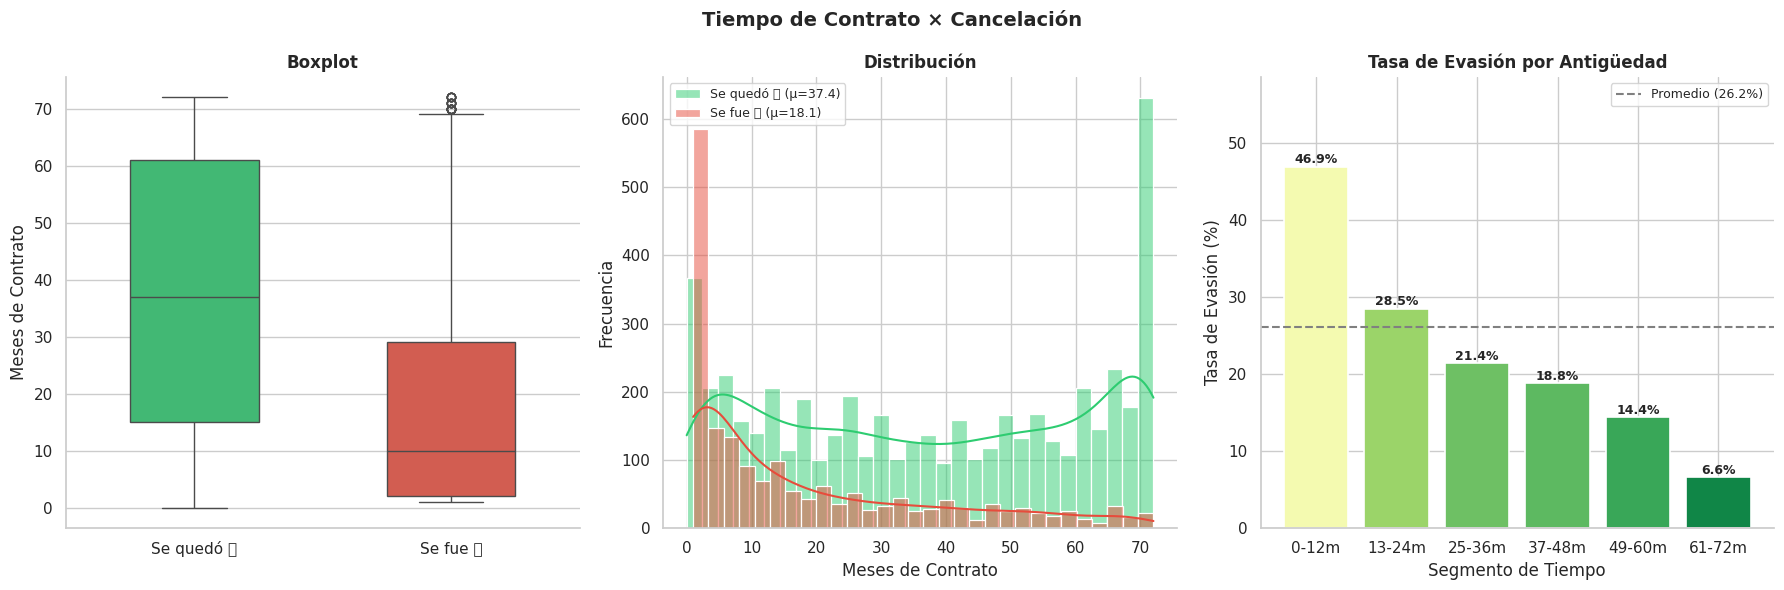

In [34]:
# ============================================================
# 7.2 — GRÁFICAS TIEMPO DE CONTRATO × CANCELACIÓN
# ============================================================

seccion("7.2 — GRÁFICAS TIEMPO DE CONTRATO")

try:
    COLORES = {'Se quedó ✅': '#2ecc71', 'Se fue ❌': '#e74c3c'}

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(
        'Tiempo de Contrato × Cancelación',
        fontsize=14, fontweight='bold'
    )

    # ── Boxplot ────────────────────────────────────────────────
    try:
        ax1 = axes[0]
        sns.boxplot(
            data=df_analisis,
            x='Grupo', y=col_tenure,
            palette=COLORES, width=0.5, ax=ax1
        )
        ax1.set_title('Boxplot', fontsize=12, fontweight='bold')
        ax1.set_xlabel('')
        ax1.set_ylabel('Meses de Contrato')
        sns.despine(ax=ax1)
    except Exception as e:
        print(f"  ⚠️  Error en boxplot: {e}")

    # ── Histograma superpuesto ─────────────────────────────────
    try:
        ax2 = axes[1]
        for grupo, color in COLORES.items():
            datos = df_analisis[df_analisis['Grupo'] == grupo][col_tenure]
            sns.histplot(
                datos, kde=True, ax=ax2,
                color=color, alpha=0.5,
                label=f'{grupo} (μ={datos.mean():.1f})',
                bins=30
            )
        ax2.set_title('Distribución', fontsize=12, fontweight='bold')
        ax2.set_xlabel('Meses de Contrato')
        ax2.set_ylabel('Frecuencia')
        ax2.legend(fontsize=9)
        sns.despine(ax=ax2)
    except Exception as e:
        print(f"  ⚠️  Error en histograma: {e}")

    # ── Tasa de evasión por segmento de tiempo ─────────────────
    try:
        ax3 = axes[2]
        df_analisis['_segmento'] = pd.cut(
            df_analisis[col_tenure],
            bins=[0, 12, 24, 36, 48, 60, 72],
            labels=['0-12m', '13-24m', '25-36m', '37-48m', '49-60m', '61-72m']
        )
        tasa_seg = df_analisis.groupby('_segmento', observed=True)[col_objetivo]\
                              .mean().mul(100).round(1)

        barras = ax3.bar(
            tasa_seg.index.astype(str),
            tasa_seg.values,
            color=plt.cm.RdYlGn_r(tasa_seg.values / 100),
            edgecolor='white', linewidth=1.2
        )
        tasa_gral = round(y.mean() * 100, 1)
        ax3.axhline(tasa_gral, color='gray', linestyle='--',
                    linewidth=1.5, label=f'Promedio ({tasa_gral}%)')

        for barra, val in zip(barras, tasa_seg.values):
            ax3.text(
                barra.get_x() + barra.get_width() / 2,
                barra.get_height() + 0.5,
                f'{val}%', ha='center', fontsize=9, fontweight='bold'
            )
        ax3.set_title('Tasa de Evasión por Antigüedad',
                      fontsize=12, fontweight='bold')
        ax3.set_xlabel('Segmento de Tiempo')
        ax3.set_ylabel('Tasa de Evasión (%)')
        ax3.set_ylim(0, tasa_seg.max() * 1.25)
        ax3.legend(fontsize=9)
        sns.despine(ax=ax3)
        df_analisis.drop(columns=['_segmento'], inplace=True, errors='ignore')
    except Exception as e:
        print(f"  ⚠️  Error en tasa por segmento: {e}")

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"  ❌ Error general: {e}")

###7.3 Gasto total x Cancelación

In [35]:
# ============================================================
# 7.3 — GASTO TOTAL × CANCELACIÓN
# ============================================================

seccion("7.3 — GASTO TOTAL × CANCELACIÓN")

try:
    col_total = [
        c for c in X.columns
        if 'total' in c.lower()
    ][0]

    # ── Estadísticas por grupo ─────────────────────────────────
    stats_total = df_analisis.groupby('Grupo')[col_total].agg([
        'mean', 'median', 'std', 'min', 'max'
    ]).round(2)
    stats_total.columns = ['Media', 'Mediana', 'Std', 'Mínimo', 'Máximo']

    print(f"  📌 Columna analizada: '{col_total}'\n")
    display(stats_total)

except IndexError:
    print("  ❌ No se encontró columna de gasto total")
except Exception as e:
    print(f"  ❌ Error: {e}")


  7.3 — GASTO TOTAL × CANCELACIÓN
  📌 Columna analizada: 'Cargo_Total'



,Media,Mediana,Std,Mínimo,Máximo
Grupo,,,,,
Se fue ❌,1541.38,713.10,1893.15,18.85,8684.80
Se quedó ✅,2548.28,1678.05,2326.65,18.80,8672.45


### 7.4 Graficas de gasto total x cancelación


  7.4 — GRÁFICAS GASTO TOTAL


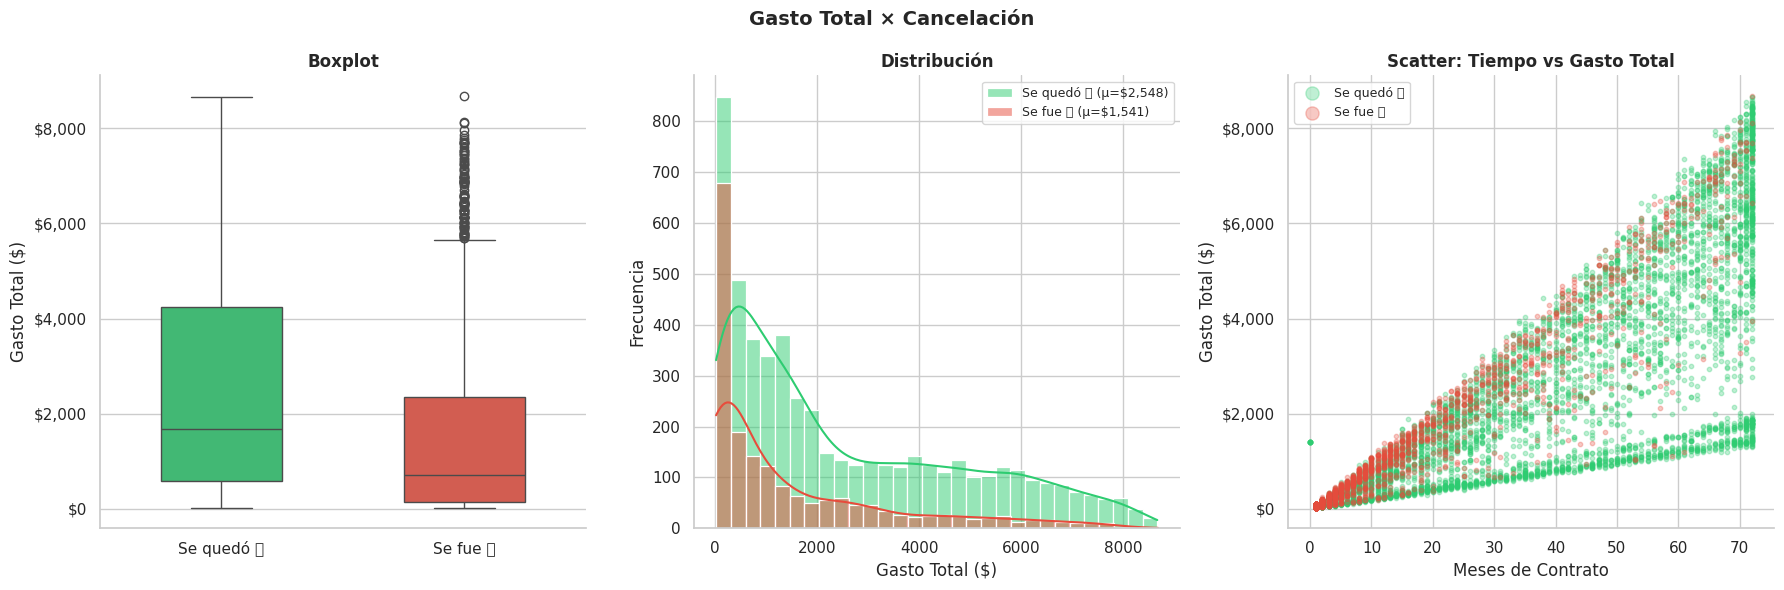

In [36]:
# ============================================================
# 7.4 — GRÁFICAS GASTO TOTAL × CANCELACIÓN
# ============================================================

seccion("7.4 — GRÁFICAS GASTO TOTAL")

try:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(
        'Gasto Total × Cancelación',
        fontsize=14, fontweight='bold'
    )

    # ── Boxplot ────────────────────────────────────────────────
    try:
        ax1 = axes[0]
        sns.boxplot(
            data=df_analisis,
            x='Grupo', y=col_total,
            palette=COLORES, width=0.5, ax=ax1
        )
        ax1.set_title('Boxplot', fontsize=12, fontweight='bold')
        ax1.set_xlabel('')
        ax1.set_ylabel('Gasto Total ($)')
        ax1.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
        )
        sns.despine(ax=ax1)
    except Exception as e:
        print(f"  ⚠️  Error en boxplot: {e}")

    # ── Histograma superpuesto ─────────────────────────────────
    try:
        ax2 = axes[1]
        for grupo, color in COLORES.items():
            datos = df_analisis[df_analisis['Grupo'] == grupo][col_total]
            sns.histplot(
                datos, kde=True, ax=ax2,
                color=color, alpha=0.5,
                label=f'{grupo} (μ=${datos.mean():,.0f})',
                bins=30
            )
        ax2.set_title('Distribución', fontsize=12, fontweight='bold')
        ax2.set_xlabel('Gasto Total ($)')
        ax2.set_ylabel('Frecuencia')
        ax2.legend(fontsize=9)
        sns.despine(ax=ax2)
    except Exception as e:
        print(f"  ⚠️  Error en histograma: {e}")

    # ── Scatter: Gasto Total vs Tiempo × Evasión ───────────────
    try:
        ax3 = axes[2]
        for grupo, color in COLORES.items():
            mask = df_analisis['Grupo'] == grupo
            ax3.scatter(
                df_analisis[mask][col_tenure],
                df_analisis[mask][col_total],
                c=color, alpha=0.3, s=10, label=grupo
            )
        ax3.set_title('Scatter: Tiempo vs Gasto Total',
                      fontsize=12, fontweight='bold')
        ax3.set_xlabel('Meses de Contrato')
        ax3.set_ylabel('Gasto Total ($)')
        ax3.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
        )
        ax3.legend(fontsize=9, markerscale=3)
        sns.despine(ax=ax3)
    except Exception as e:
        print(f"  ⚠️  Error en scatter: {e}")

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"  ❌ Error general: {e}")

###7.5 Cargo Mensual x Cancelación


  7.5 — CARGO MENSUAL × CANCELACIÓN


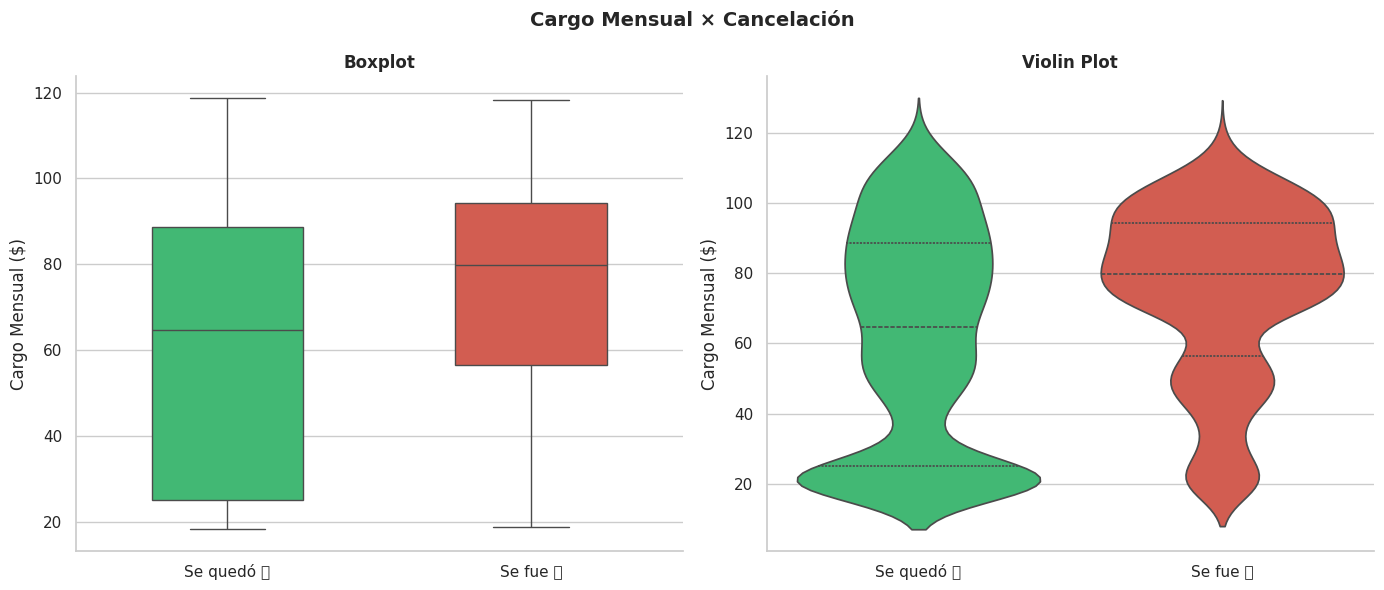

,Media,Mediana,Std
Grupo,,,
Se fue ❌,74.60,79.70,24.60
Se quedó ✅,61.49,64.75,31.04


In [38]:
# ============================================================
# 7.5 — CARGO MENSUAL × CANCELACIÓN
# ============================================================

seccion("7.5 — CARGO MENSUAL × CANCELACIÓN")

try:
    col_mensual = [
        c for c in X.columns
        if 'mensual' in c.lower() or 'monthly' in c.lower()
    ][0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(
        'Cargo Mensual × Cancelación',
        fontsize=14, fontweight='bold'
    )

    # ── Boxplot ────────────────────────────────────────────────
    try:
        ax1 = axes[0]
        sns.boxplot(
            data=df_analisis,
            x='Grupo', y=col_mensual,
            palette=COLORES, width=0.5, ax=ax1
        )
        ax1.set_title('Boxplot', fontsize=12, fontweight='bold')
        ax1.set_xlabel('')
        ax1.set_ylabel('Cargo Mensual ($)')
        sns.despine(ax=ax1)
    except Exception as e:
        print(f"  ⚠️  Error en boxplot: {e}")

    # ── Violin plot ────────────────────────────────────────────
    try:
        ax2 = axes[1]
        sns.violinplot(
            data=df_analisis,
            x='Grupo', y=col_mensual,
            palette=COLORES, ax=ax2,
            inner='quartile'
        )
        ax2.set_title('Violin Plot', fontsize=12, fontweight='bold')
        ax2.set_xlabel('')
        ax2.set_ylabel('Cargo Mensual ($)')
        sns.despine(ax=ax2)
    except Exception as e:
        print(f"  ⚠️  Error en violin: {e}")

    plt.tight_layout()
    plt.show()

    # ── Estadísticas ───────────────────────────────────────────
    stats_mensual = df_analisis.groupby('Grupo')[col_mensual].agg([
        'mean', 'median', 'std'
    ]).round(2)
    stats_mensual.columns = ['Media', 'Mediana', 'Std']
    display(stats_mensual)

except IndexError:
    print("  ❌ No se encontró columna de cargo mensual")
except Exception as e:
    print(f"  ❌ Error: {e}")

###7.6 Resumen de Análisis Dirigido

In [40]:
# ============================================================
# 7.6 — RESUMEN DE HALLAZGOS DEL ANÁLISIS DIRIGIDO
# ============================================================

seccion("7.6 — HALLAZGOS CLAVE")

try:
    media_tenure_ret  = round(df_analisis[df_analisis['Grupo']=='Se quedó ✅'][col_tenure].mean(), 1)
    media_tenure_evad = round(df_analisis[df_analisis['Grupo']=='Se fue ❌'][col_tenure].mean(), 1)
    media_total_ret   = round(df_analisis[df_analisis['Grupo']=='Se quedó ✅'][col_total].mean(), 2)
    media_total_evad  = round(df_analisis[df_analisis['Grupo']=='Se fue ❌'][col_total].mean(), 2)
    media_mens_ret    = round(df_analisis[df_analisis['Grupo']=='Se quedó ✅'][col_mensual].mean(), 2)
    media_mens_evad   = round(df_analisis[df_analisis['Grupo']=='Se fue ❌'][col_mensual].mean(), 2)

    print(f"""
  ┌──────────────────────────────────────────────────────────────┐
  │                  HALLAZGOS DEL ANÁLISIS DIRIGIDO             │
  ├────────────────────────┬─────────────────┬───────────────────┤
  │  Variable              │  Se quedó ✅    │  Se fue ❌        │
  ├────────────────────────┼─────────────────┼───────────────────┤
  │  Tiempo contrato (med) │  {str(media_tenure_ret)+' meses':<15} │  {str(media_tenure_evad)+' meses':<17} │
  │  Gasto total (med)     │  ${str(media_total_ret):<14} │  ${str(media_total_evad):<16} │
  │  Cargo mensual (med)   │  ${str(media_mens_ret):<14} │  ${str(media_mens_evad):<16} │
  └────────────────────────┴─────────────────┴───────────────────┘

  🔍 Conclusiones:

  📌 Tiempo de contrato:
     → Clientes que se van llevan ~{media_tenure_evad} meses vs ~{media_tenure_ret} de los que se quedan
     → Los primeros meses son el período de mayor riesgo de evasión

  📌 Gasto total:
     → Clientes evadidos tienen menor gasto total acumulado
     → Confirma que se van antes de acumular historial con la empresa

  📌 Cargo mensual:
     → Clientes evadidos pagan ${media_mens_evad}/mes vs ${media_mens_ret}/mes de los retenidos
     → Mayor costo mensual → mayor probabilidad de buscar alternativas


""")

except Exception as e:
    print(f"  ❌ Error: {e}")


  7.6 — HALLAZGOS CLAVE

  ┌──────────────────────────────────────────────────────────────┐
  │                  HALLAZGOS DEL ANÁLISIS DIRIGIDO             │
  ├────────────────────────┬─────────────────┬───────────────────┤
  │  Variable              │  Se quedó ✅    │  Se fue ❌        │
  ├────────────────────────┼─────────────────┼───────────────────┤
  │  Tiempo contrato (med) │  37.4 meses      │  18.1 meses        │
  │  Gasto total (med)     │  $2548.28        │  $1541.38          │
  │  Cargo mensual (med)   │  $61.49          │  $74.6             │
  └────────────────────────┴─────────────────┴───────────────────┘

  🔍 Conclusiones:

  📌 Tiempo de contrato:
     → Clientes que se van llevan ~18.1 meses vs ~37.4 de los que se quedan
     → Los primeros meses son el período de mayor riesgo de evasión

  📌 Gasto total:
     → Clientes evadidos tienen menor gasto total acumulado
     → Confirma que se van antes de acumular historial con la empresa

  📌 Cargo mensual:
     → Clie

#Paso 8. Modelado Predictivo

###8.1 Decidir la División del Dataset

In [42]:
# ============================================================
# 8.1 — DECIDIR LA DIVISIÓN DEL DATASET
# ============================================================

seccion("8.1 — DECISIÓN DE DIVISIÓN")

try:
    total_registros = len(X)

    print(f"  📐 Total de registros disponibles: {total_registros:,}\n")
    print(f"  📌 Criterio de selección:")

    if total_registros >= 100_000:
        TEST_SIZE = 0.10
        print(f"     → Dataset muy grande  (>100k) : 90% train / 10% test")
    elif total_registros >= 10_000:
        TEST_SIZE = 0.20
        print(f"     → Dataset grande (10k-100k)   : 80% train / 20% test")
    elif total_registros >= 1_000:
        TEST_SIZE = 0.30
        print(f"     → Dataset mediano (1k-10k)     : 70% train / 30% test  ✅ aplicado")
    else:
        TEST_SIZE = 0.30
        print(f"     → Dataset pequeño (<1k)        : 70% train / 30% test")

    RANDOM_STATE = 42
    train_size   = round((1 - TEST_SIZE) * 100)
    test_size    = round(TEST_SIZE * 100)

    # ✅ Fix: calcular filas como enteros y formatear sin str()
    filas_train = int(total_registros * (1 - TEST_SIZE))
    filas_test  = int(total_registros * TEST_SIZE)

    print(f"""
  ┌─────────────────────────────────────────┐
  │         CONFIGURACIÓN DE DIVISIÓN       │
  ├─────────────────────────────────────────┤
  │  📊 Total registros  : {total_registros:>6,}          │
  │  🏋️  Entrenamiento   : {train_size:>5}% ({filas_train:,} filas)  │
  │  🧪 Prueba           : {test_size:>5}% ({filas_test:,} filas)   │
  │  🎲 Random state     : {RANDOM_STATE:>6}           │
  │  ⚖️  Estratificado   :    Sí (Evasion)  │
  └─────────────────────────────────────────┘

  💡 Estratificado = Sí:
     → Garantiza que train y test tengan la misma
       proporción de evadidos que el dataset original
     → Evita que el test tenga más/menos churn por azar
""")

except Exception as e:
    print(f"  ❌ Error: {e}")


  8.1 — DECISIÓN DE DIVISIÓN
  📐 Total de registros disponibles: 7,088

  📌 Criterio de selección:
     → Dataset mediano (1k-10k)     : 70% train / 30% test  ✅ aplicado

  ┌─────────────────────────────────────────┐
  │         CONFIGURACIÓN DE DIVISIÓN       │
  ├─────────────────────────────────────────┤
  │  📊 Total registros  :  7,088          │
  │  🏋️  Entrenamiento   :    70% (4,961 filas)  │
  │  🧪 Prueba           :    30% (2,126 filas)   │
  │  🎲 Random state     :     42           │
  │  ⚖️  Estratificado   :    Sí (Evasion)  │
  └─────────────────────────────────────────┘

  💡 Estratificado = Sí:
     → Garantiza que train y test tengan la misma
       proporción de evadidos que el dataset original
     → Evita que el test tenga más/menos churn por azar



###8.2 Aplicar Train/Test Split

In [43]:
# ============================================================
# 8.2 — APLICAR TRAIN/TEST SPLIT
# ============================================================

seccion("8.2 — APLICAR TRAIN/TEST SPLIT")

try:
    from sklearn.model_selection import train_test_split

    # ── División sobre datos ORIGINALES (para Random Forest) ──
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size    = TEST_SIZE,
        random_state = RANDOM_STATE,
        stratify     = y        # ✅ Mantiene proporción de clases
    )

    # ── División sobre datos ESCALADOS (para Reg. Logística) ──
    X_train_scaled, X_test_scaled, _, _ = train_test_split(
        X_scaled, y,
        test_size    = TEST_SIZE,
        random_state = RANDOM_STATE,
        stratify     = y
    )

    print(f"  ✅ División aplicada correctamente\n")
    print(f"  {'Conjunto':<25} {'Shape X':>12}  {'Shape y':>10}")
    print(f"  {'-'*50}")
    print(f"  {'X_train':<25} {str(X_train.shape):>12}  {str(y_train.shape):>10}")
    print(f"  {'X_test':<25} {str(X_test.shape):>12}  {str(y_test.shape):>10}")
    print(f"  {'X_train_scaled':<25} {str(X_train_scaled.shape):>12}  {str(y_train.shape):>10}")
    print(f"  {'X_test_scaled':<25} {str(X_test_scaled.shape):>12}  {str(y_test.shape):>10}")

except Exception as e:
    print(f"  ❌ Error aplicando split: {e}")


  8.2 — APLICAR TRAIN/TEST SPLIT
  ✅ División aplicada correctamente

  Conjunto                       Shape X     Shape y
  --------------------------------------------------
  X_train                     (4961, 28)     (4961,)
  X_test                      (2127, 28)     (2127,)
  X_train_scaled              (4961, 28)     (4961,)
  X_test_scaled               (2127, 28)     (2127,)


###8.3 Aplicar SMOTE Solo al Train

In [44]:
# ============================================================
# 8.3 — APLICAR SMOTE SOLO SOBRE EL TRAIN
# ============================================================

seccion("8.3 — SMOTE SOBRE ENTRENAMIENTO")

try:
    from imblearn.over_sampling import SMOTE

    smote = SMOTE(random_state=RANDOM_STATE)

    # ── SMOTE sobre train original (Random Forest) ─────────────
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    # ── SMOTE sobre train escalado (Regresión Logística) ───────
    X_train_scaled_smote, y_train_scaled_smote = smote.fit_resample(
        X_train_scaled, y_train
    )

    print(f"  ✅ SMOTE aplicado SOLO sobre los conjuntos de entrenamiento\n")
    print(f"  {'Conjunto':<35} {'Antes':>10}  {'Después':>10}")
    print(f"  {'-'*58}")
    print(f"  {'X_train':<35} {str(X_train.shape[0]):>10}  {str(X_train_smote.shape[0]):>10}")
    print(f"  {'X_train_scaled':<35} {str(X_train_scaled.shape[0]):>10}  {str(X_train_scaled_smote.shape[0]):>10}")

    print(f"\n  📊 Distribución y_train ANTES del SMOTE:")
    for val, cnt in y_train.value_counts().sort_index().items():
        pct = round(cnt / len(y_train) * 100, 1)
        print(f"     Clase {val}: {cnt:,} ({pct}%)")

    print(f"\n  📊 Distribución y_train DESPUÉS del SMOTE:")
    for val, cnt in pd.Series(y_train_smote).value_counts().sort_index().items():
        pct = round(cnt / len(y_train_smote) * 100, 1)
        print(f"     Clase {val}: {cnt:,} ({pct}%)")

    print(f"""
  ⚠️  Regla de oro del SMOTE:
     ✅ Aplicado sobre X_train  → Correcto
     ✅ Aplicado sobre X_test   → NUNCA — contamina la evaluación
""")

except Exception as e:
    print(f"  ❌ Error aplicando SMOTE: {e}")


  8.3 — SMOTE SOBRE ENTRENAMIENTO
  ✅ SMOTE aplicado SOLO sobre los conjuntos de entrenamiento

  Conjunto                                 Antes     Después
  ----------------------------------------------------------
  X_train                                   4961        7322
  X_train_scaled                            4961        7322

  📊 Distribución y_train ANTES del SMOTE:
     Clase 0: 3,661 (73.8%)
     Clase 1: 1,300 (26.2%)

  📊 Distribución y_train DESPUÉS del SMOTE:
     Clase 0: 3,661 (50.0%)
     Clase 1: 3,661 (50.0%)

  ⚠️  Regla de oro del SMOTE:
     ✅ Aplicado sobre X_train  → Correcto
     ✅ Aplicado sobre X_test   → NUNCA — contamina la evaluación



###8.4 Verificar Estratificación

In [45]:
# ============================================================
# 8.4 — VERIFICAR ESTRATIFICACIÓN
# ============================================================

seccion("8.4 — VERIFICACIÓN DE ESTRATIFICACIÓN")

try:
    print(f"  📊 Proporción de evasión por conjunto:\n")
    print(f"  {'Conjunto':<25} {'Total':>8}  {'Evadidos':>10}  {'% Evasión':>12}")
    print(f"  {'-'*60}")

    conjuntos = [
        ('Dataset completo', y),
        ('y_train',          y_train),
        ('y_test',           y_test),
    ]

    for nombre, y_data in conjuntos:
        total    = len(y_data)
        evadidos = int(pd.Series(y_data).sum())
        pct      = round(evadidos / total * 100, 2)
        print(f"  {nombre:<25} {total:>8,}  {evadidos:>10,}  {pct:>11}%")

    print(f"""
  ✅ Si los porcentajes son similares entre conjuntos,
     la estratificación fue exitosa.
""")

except Exception as e:
    print(f"  ❌ Error en verificación: {e}")


  8.4 — VERIFICACIÓN DE ESTRATIFICACIÓN
  📊 Proporción de evasión por conjunto:

  Conjunto                     Total    Evadidos     % Evasión
  ------------------------------------------------------------
  Dataset completo             7,088       1,857         26.2%
  y_train                      4,961       1,300         26.2%
  y_test                       2,127         557        26.19%

  ✅ Si los porcentajes son similares entre conjuntos,
     la estratificación fue exitosa.



### 8.5 Resumen Final del modelado rpedictivo

In [47]:
# ============================================================
# 8.5 — RESUMEN FINAL DE LA SEPARACIÓN
# ============================================================

seccion("8.5 — RESUMEN FINAL")

try:
    print(f"""
  📦 Variables disponibles para el modelado:

  ┌──────────────────────────────┬────────────────┬──────────────────────────────┐
  │  Variable                    │  Shape         │  Uso                         │
  ├──────────────────────────────┼────────────────┼──────────────────────────────┤
  │  X_train_smote               │  {str(X_train_smote.shape):<14} │  Train — Random Forest      │
  │  X_train_scaled_smote        │  {str(X_train_scaled_smote.shape):<14} │  Train — Reg. Logística     │
  │  X_test                      │  {str(X_test.shape):<14} │  Test  — Random Forest      │
  │  X_test_scaled               │  {str(X_test_scaled.shape):<14} │  Test  — Reg. Logística     │
  │  y_train_smote               │  {str(y_train_smote.shape):<14} │  Labels train (ambos)       │
  │  y_test                      │  {str(y_test.shape):<14} │  Labels test  (ambos)       │
  └──────────────────────────────┴────────────────┴──────────────────────────────┘


""")

except Exception as e:
    print(f"  ❌ Error: {e}")


  8.5 — RESUMEN FINAL

  📦 Variables disponibles para el modelado:

  ┌──────────────────────────────┬────────────────┬──────────────────────────────┐
  │  Variable                    │  Shape         │  Uso                         │
  ├──────────────────────────────┼────────────────┼──────────────────────────────┤
  │  X_train_smote               │  (7322, 28)     │  Train — Random Forest      │
  │  X_train_scaled_smote        │  (7322, 28)     │  Train — Reg. Logística     │
  │  X_test                      │  (2127, 28)     │  Test  — Random Forest      │
  │  X_test_scaled               │  (2127, 28)     │  Test  — Reg. Logística     │
  │  y_train_smote               │  (7322,)        │  Labels train (ambos)       │
  │  y_test                      │  (2127,)        │  Labels test  (ambos)       │
  └──────────────────────────────┴────────────────┴──────────────────────────────┘

 



#9. Creación de Modelos

###9.1 Importamos las librerías para el modelado

In [48]:
# ============================================================
# 9.1 — IMPORTAR LIBRERÍAS DE MODELADO
# ============================================================

seccion("9.1 — IMPORTAR LIBRERÍAS")

try:
    from sklearn.linear_model    import LogisticRegression
    from sklearn.ensemble        import RandomForestClassifier
    from sklearn.metrics         import (
        accuracy_score, precision_score, recall_score,
        f1_score, roc_auc_score, confusion_matrix,
        classification_report, RocCurveDisplay
    )
    import time
    print("  ✅ Librerías importadas correctamente")

except Exception as e:
    print(f"  ❌ Error importando librerías: {e}")


  9.1 — IMPORTAR LIBRERÍAS
  ✅ Librerías importadas correctamente


###9.2. Modelo 1: Regresión logística

In [49]:
# ============================================================
# 9.2 — MODELO 1: REGRESIÓN LOGÍSTICA
# ============================================================

seccion("9.2 — REGRESIÓN LOGÍSTICA")

try:
    print("""
  📌 Justificación:
     → Modelo lineal sensible a la escala de los datos
     → Requiere datos estandarizados (μ=0, σ=1)
     → Usamos X_train_scaled_smote y X_test_scaled
     → class_weight='balanced' como respaldo al SMOTE
     → Interpretable: sus coeficientes indican
       la dirección e impacto de cada variable
""")

    inicio = time.time()

    modelo_rl = LogisticRegression(
        max_iter     = 1000,          # Suficientes iteraciones para converger
        random_state = RANDOM_STATE,
        class_weight = 'balanced',    # Respaldo ante desbalance residual
        solver       = 'lbfgs',       # Eficiente para datasets medianos
        C            = 1.0            # Regularización estándar
    )

    modelo_rl.fit(X_train_scaled_smote, y_train_scaled_smote)

    tiempo_rl = round(time.time() - inicio, 3)

    print(f"  ✅ Modelo entrenado en {tiempo_rl}s")
    print(f"  📐 Features usadas    : {X_train_scaled_smote.shape[1]}")
    print(f"  📐 Registros train    : {X_train_scaled_smote.shape[0]:,}")
    print(f"  📐 Iteraciones        : {modelo_rl.n_iter_[0]}")

except Exception as e:
    print(f"  ❌ Error entrenando Regresión Logística: {e}")


  9.2 — REGRESIÓN LOGÍSTICA

  📌 Justificación:
     → Modelo lineal sensible a la escala de los datos
     → Requiere datos estandarizados (μ=0, σ=1)
     → Usamos X_train_scaled_smote y X_test_scaled
     → class_weight='balanced' como respaldo al SMOTE
     → Interpretable: sus coeficientes indican
       la dirección e impacto de cada variable

  ✅ Modelo entrenado en 0.165s
  📐 Features usadas    : 28
  📐 Registros train    : 7,322
  📐 Iteraciones        : 37


###9.3. Modelo 2: Ramdom Forest

In [50]:
# ============================================================
# 9.3 — MODELO 2: RANDOM FOREST
# ============================================================

seccion("9.3 — RANDOM FOREST")

try:
    print("""
  📌 Justificación:
     → Modelo basado en árboles — no sensible a la escala
     → No requiere estandarización de los datos
     → Usamos X_train_smote y X_test (sin escalar)
     → Robusto ante outliers y variables irrelevantes
     → Provee importancia de variables de forma nativa
     → Captura relaciones no lineales entre variables
""")

    inicio = time.time()

    modelo_rf = RandomForestClassifier(
        n_estimators = 200,           # 200 árboles — buen balance velocidad/precisión
        max_depth    = 10,            # Limita profundidad para evitar overfitting
        min_samples_split = 10,       # Mínimo de muestras para dividir un nodo
        min_samples_leaf  = 4,        # Mínimo de muestras en hoja
        random_state = RANDOM_STATE,
        class_weight = 'balanced',    # Respaldo ante desbalance residual
        n_jobs       = -1             # Usa todos los núcleos disponibles
    )

    modelo_rf.fit(X_train_smote, y_train_smote)

    tiempo_rf = round(time.time() - inicio, 3)

    print(f"  ✅ Modelo entrenado en {tiempo_rf}s")
    print(f"  📐 Features usadas    : {X_train_smote.shape[1]}")
    print(f"  📐 Registros train    : {X_train_smote.shape[0]:,}")
    print(f"  📐 Árboles creados    : {modelo_rf.n_estimators}")
    print(f"  📐 Profundidad máx    : {modelo_rf.max_depth}")

except Exception as e:
    print(f"  ❌ Error entrenando Random Forest: {e}")


  9.3 — RANDOM FOREST

  📌 Justificación:
     → Modelo basado en árboles — no sensible a la escala
     → No requiere estandarización de los datos
     → Usamos X_train_smote y X_test (sin escalar)
     → Robusto ante outliers y variables irrelevantes
     → Provee importancia de variables de forma nativa
     → Captura relaciones no lineales entre variables

  ✅ Modelo entrenado en 2.072s
  📐 Features usadas    : 28
  📐 Registros train    : 7,322
  📐 Árboles creados    : 200
  📐 Profundidad máx    : 10


###9.4 Predicciones

In [51]:
# ============================================================
# 9.4 — GENERAR PREDICCIONES
# ============================================================

seccion("9.4 — PREDICCIONES")

try:
    # ── Regresión Logística ────────────────────────────────────
    y_pred_rl      = modelo_rl.predict(X_test_scaled)
    y_prob_rl      = modelo_rl.predict_proba(X_test_scaled)[:, 1]

    # ── Random Forest ──────────────────────────────────────────
    y_pred_rf      = modelo_rf.predict(X_test)
    y_prob_rf      = modelo_rf.predict_proba(X_test)[:, 1]

    print(f"  ✅ Predicciones generadas correctamente\n")
    print(f"  {'Modelo':<25} {'y_pred shape':>15}  {'y_prob shape':>15}")
    print(f"  {'-'*58}")
    print(f"  {'Regresión Logística':<25} {str(y_pred_rl.shape):>15}  {str(y_prob_rl.shape):>15}")
    print(f"  {'Random Forest':<25} {str(y_pred_rf.shape):>15}  {str(y_prob_rf.shape):>15}")

    print(f"\n  📊 Distribución de predicciones:\n")
    for nombre, y_pred in [('Reg. Logística', y_pred_rl), ('Random Forest', y_pred_rf)]:
        pred_series = pd.Series(y_pred)
        n_cero = (pred_series == 0).sum()
        n_uno  = (pred_series == 1).sum()
        print(f"  {nombre}:")
        print(f"     → Predijo 'Se quedó' (0): {n_cero:,} ({round(n_cero/len(y_pred)*100,1)}%)")
        print(f"     → Predijo 'Se fue'   (1): {n_uno:,}  ({round(n_uno/len(y_pred)*100,1)}%)")

except Exception as e:
    print(f"  ❌ Error generando predicciones: {e}")


  9.4 — PREDICCIONES
  ✅ Predicciones generadas correctamente

  Modelo                       y_pred shape     y_prob shape
  ----------------------------------------------------------
  Regresión Logística               (2127,)          (2127,)
  Random Forest                     (2127,)          (2127,)

  📊 Distribución de predicciones:

  Reg. Logística:
     → Predijo 'Se quedó' (0): 1,288 (60.6%)
     → Predijo 'Se fue'   (1): 839  (39.4%)
  Random Forest:
     → Predijo 'Se quedó' (0): 1,435 (67.5%)
     → Predijo 'Se fue'   (1): 692  (32.5%)


###9.5 Resumen de Modelos

In [56]:
# ============================================================
# 9.5 — RESUMEN DE MODELOS CREADOS
# ============================================================

seccion("9.5 — RESUMEN DE MODELOS")

try:
    print(f"""
  ┌─────────────────────────────────────────────────────────────────┐
  │                    MODELOS ENTRENADOS                           │
  ├──────────────────────┬──────────────────────────────────────────┤
  │  Modelo              │  Regresión Logística                     │
  ├──────────────────────┼──────────────────────────────────────────┤
  │  Datos de train      │  X_train_scaled_smote                    │
  │  Datos de test       │  X_test_scaled                           │
  │  Estandarización     │  ✅ Sí — StandardScaler                  │
  │  Hiperparámetros     │  max_iter=1000, C=1.0, solver=lbfgs      │
  │  Tiempo entrenamiento│  {tiempo_rl}s                                  │
  ├──────────────────────┼──────────────────────────────────────────┤
  │  Modelo              │  Random Forest                           │
  ├──────────────────────┼──────────────────────────────────────────┤
  │  Datos de train      │  X_train_smote                           │
  │  Datos de test       │  X_test                                  │
  │  Estandarización     │  ❌ No — no requerida                    │
  │  Hiperparámetros     │  n_estimators=200, max_depth=10          │
  │  Tiempo entrenamiento│  {tiempo_rf}s                                  │
  └──────────────────────┴──────────────────────────────────────────┘

  📦 Variables disponibles:
     → modelo_rl   : modelo Regresión Logística entrenado
     → modelo_rf   : modelo Random Forest entrenado
     → y_pred_rl   : predicciones Reg. Logística
     → y_pred_rf   : predicciones Random Forest
     → y_prob_rl   : probabilidades Reg. Logística
     → y_prob_rf   : probabilidades Random Forest


""")

except Exception as e:
    print(f"  ❌ Error en resumen: {e}")


  9.5 — RESUMEN DE MODELOS

  ┌─────────────────────────────────────────────────────────────────┐
  │                    MODELOS ENTRENADOS                           │
  ├──────────────────────┬──────────────────────────────────────────┤
  │  Modelo              │  Regresión Logística                     │
  ├──────────────────────┼──────────────────────────────────────────┤
  │  Datos de train      │  X_train_scaled_smote                    │
  │  Datos de test       │  X_test_scaled                           │
  │  Estandarización     │  ✅ Sí — StandardScaler                  │
  │  Hiperparámetros     │  max_iter=1000, C=1.0, solver=lbfgs      │
  │  Tiempo entrenamiento│  0.165s                                  │
  ├──────────────────────┼──────────────────────────────────────────┤
  │  Modelo              │  Random Forest                           │
  ├──────────────────────┼──────────────────────────────────────────┤
  │  Datos de train      │  X_train_smote                     

# Evaluación de Modelos


###10.1 Metrícas de Evaluación

In [57]:
# ============================================================
# 10.1 — MÉTRICAS DE EVALUACIÓN
# ============================================================

seccion("10.1 — MÉTRICAS DE EVALUACIÓN")

try:
    def calcular_metricas(nombre, y_real, y_pred, y_prob):
        try:
            return {
                'Modelo'     : nombre,
                'Accuracy'   : round(accuracy_score(y_real, y_pred),        4),
                'Precision'  : round(precision_score(y_real, y_pred),        4),
                'Recall'     : round(recall_score(y_real, y_pred),           4),
                'F1-Score'   : round(f1_score(y_real, y_pred),               4),
                'ROC-AUC'    : round(roc_auc_score(y_real, y_prob),          4),
            }
        except Exception as e:
            print(f"  ⚠️  Error calculando métricas de '{nombre}': {e}")
            return {}

    metricas_rl = calcular_metricas(
        'Regresión Logística', y_test, y_pred_rl, y_prob_rl
    )
    metricas_rf = calcular_metricas(
        'Random Forest',       y_test, y_pred_rf, y_prob_rf
    )

    df_metricas = pd.DataFrame([metricas_rl, metricas_rf]).set_index('Modelo')
    display(df_metricas)

    # ── Ganador por métrica ────────────────────────────────────
    print(f"\n  🏆 Mejor modelo por métrica:\n")
    for metrica in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
        try:
            ganador = df_metricas[metrica].idxmax()
            valor   = df_metricas[metrica].max()
            print(f"     → {metrica:<12}: {ganador} ({valor:.4f})")
        except Exception as e:
            print(f"  ⚠️  Error en '{metrica}': {e}")

except Exception as e:
    print(f"  ❌ Error: {e}")


  10.1 — MÉTRICAS DE EVALUACIÓN


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modelo,,,,,
Regresión Logística,0.7442,0.5077,0.7648,0.6103,0.8323
Random Forest,0.7682,0.5462,0.6786,0.6053,0.8244



  🏆 Mejor modelo por métrica:

     → Accuracy    : Random Forest (0.7682)
     → Precision   : Random Forest (0.5462)
     → Recall      : Regresión Logística (0.7648)
     → F1-Score    : Regresión Logística (0.6103)
     → ROC-AUC     : Regresión Logística (0.8323)


###10.2 Matrices de Confusión


  10.2 — MATRICES DE CONFUSIÓN


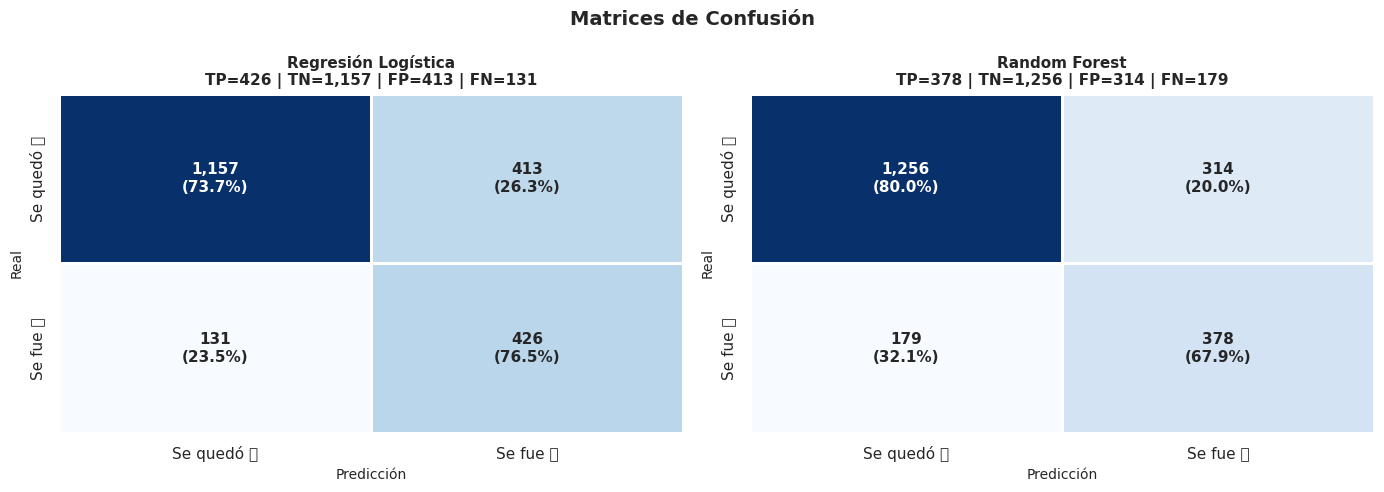


  📌 Cómo leer la matriz de confusión:

     ┌──────────────────┬──────────────────┐
     │  TN              │  FP              │
     │  (Verdad. Neg.)  │  (Falso Pos.)    │
     │  Predijo: queda  │  Predijo: se fue │
     │  Real: se quedó  │  Real: se quedó  │
     ├──────────────────┼──────────────────┤
     │  FN              │  TP              │
     │  (Falso Neg.)    │  (Verdad. Pos.)  │
     │  Predijo: queda  │  Predijo: se fue │
     │  Real: se fue ⚠️ │  Real: se fue ✅ │
     └──────────────────┴──────────────────┘

  ⚠️  FN es el error más costoso para Telecom X:
     → Cliente que se va pero el modelo no lo detectó
     → La empresa pierde al cliente sin intervenir



In [58]:
# ============================================================
# 10.2 — MATRICES DE CONFUSIÓN
# ============================================================

seccion("10.2 — MATRICES DE CONFUSIÓN")

try:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Matrices de Confusión', fontsize=14, fontweight='bold')

    MODELOS = [
        ('Regresión Logística', y_pred_rl),
        ('Random Forest',       y_pred_rf),
    ]

    for ax, (nombre, y_pred) in zip(axes, MODELOS):
        try:
            cm = confusion_matrix(y_test, y_pred)
            cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

            # Anotaciones con valor absoluto y porcentaje
            anotaciones = np.array([
                [f'{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)'
                 for j in range(cm.shape[1])]
                for i in range(cm.shape[0])
            ])

            sns.heatmap(
                cm,
                annot=anotaciones,
                fmt='',
                cmap='Blues',
                ax=ax,
                linewidths=1,
                linecolor='white',
                cbar=False,
                xticklabels=['Se quedó ✅', 'Se fue ❌'],
                yticklabels=['Se quedó ✅', 'Se fue ❌'],
                annot_kws={'size': 11, 'weight': 'bold'}
            )

            tn, fp, fn, tp = cm.ravel()
            ax.set_title(
                f'{nombre}\n'
                f'TP={tp:,} | TN={tn:,} | FP={fp:,} | FN={fn:,}',
                fontsize=11, fontweight='bold'
            )
            ax.set_xlabel('Predicción',  fontsize=10)
            ax.set_ylabel('Real',        fontsize=10)

        except Exception as e:
            print(f"  ⚠️  Error en matriz '{nombre}': {e}")

    plt.tight_layout()
    plt.show()

    # ── Interpretación ─────────────────────────────────────────
    print("""
  📌 Cómo leer la matriz de confusión:

     ┌──────────────────┬──────────────────┐
     │  TN              │  FP              │
     │  (Verdad. Neg.)  │  (Falso Pos.)    │
     │  Predijo: queda  │  Predijo: se fue │
     │  Real: se quedó  │  Real: se quedó  │
     ├──────────────────┼──────────────────┤
     │  FN              │  TP              │
     │  (Falso Neg.)    │  (Verdad. Pos.)  │
     │  Predijo: queda  │  Predijo: se fue │
     │  Real: se fue ⚠️ │  Real: se fue ✅ │
     └──────────────────┴──────────────────┘

  ⚠️  FN es el error más costoso para Telecom X:
     → Cliente que se va pero el modelo no lo detectó
     → La empresa pierde al cliente sin intervenir
""")

except Exception as e:
    print(f"  ❌ Error: {e}")

###10.3 Reporte de Clasificación

In [59]:
# ============================================================
# 10.3 — REPORTE DE CLASIFICACIÓN
# ============================================================

seccion("10.3 — REPORTE DE CLASIFICACIÓN")

try:
    for nombre, y_pred in [
        ('Regresión Logística', y_pred_rl),
        ('Random Forest',       y_pred_rf)
    ]:
        try:
            print(f"\n  {'─'*50}")
            print(f"  📋 {nombre}")
            print(f"  {'─'*50}")
            print(classification_report(
                y_test, y_pred,
                target_names=['Se quedó (0)', 'Se fue (1)'],
                digits=4
            ))
        except Exception as e:
            print(f"  ⚠️  Error en reporte '{nombre}': {e}")

except Exception as e:
    print(f"  ❌ Error: {e}")


  10.3 — REPORTE DE CLASIFICACIÓN

  ──────────────────────────────────────────────────
  📋 Regresión Logística
  ──────────────────────────────────────────────────
              precision    recall  f1-score   support

Se quedó (0)     0.8983    0.7369    0.8097      1570
  Se fue (1)     0.5077    0.7648    0.6103       557

    accuracy                         0.7442      2127
   macro avg     0.7030    0.7509    0.7100      2127
weighted avg     0.7960    0.7442    0.7575      2127


  ──────────────────────────────────────────────────
  📋 Random Forest
  ──────────────────────────────────────────────────
              precision    recall  f1-score   support

Se quedó (0)     0.8753    0.8000    0.8359      1570
  Se fue (1)     0.5462    0.6786    0.6053       557

    accuracy                         0.7682      2127
   macro avg     0.7108    0.7393    0.7206      2127
weighted avg     0.7891    0.7682    0.7755      2127



###10.4 Curvas ROC


  10.4 — CURVAS ROC


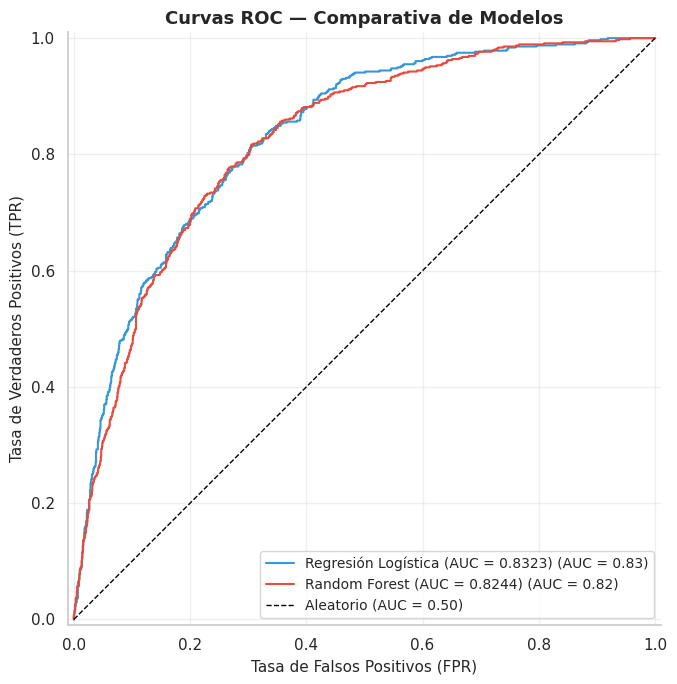


  📌 Interpretación del AUC:
     → 1.00 : Modelo perfecto
     → 0.90 : Excelente
     → 0.80 : Bueno
     → 0.70 : Aceptable
     → 0.50 : Aleatorio (inútil)



In [60]:
# ============================================================
# 10.4 — CURVAS ROC
# ============================================================

seccion("10.4 — CURVAS ROC")

try:
    fig, ax = plt.subplots(figsize=(10, 7))

    MODELOS_ROC = [
        ('Regresión Logística', y_prob_rl, '#3498db'),
        ('Random Forest',       y_prob_rf, '#e74c3c'),
    ]

    for nombre, y_prob, color in MODELOS_ROC:
        try:
            auc = roc_auc_score(y_test, y_prob)
            RocCurveDisplay.from_predictions(
                y_test, y_prob,
                name=f'{nombre} (AUC = {auc:.4f})',
                color=color,
                ax=ax
            )
        except Exception as e:
            print(f"  ⚠️  Error en ROC '{nombre}': {e}")

    # Línea de modelo aleatorio
    ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Aleatorio (AUC = 0.50)')

    ax.set_title('Curvas ROC — Comparativa de Modelos',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
    ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
    ax.legend(fontsize=10, loc='lower right')
    ax.grid(True, alpha=0.3)
    sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()

    print("""
  📌 Interpretación del AUC:
     → 1.00 : Modelo perfecto
     → 0.90 : Excelente
     → 0.80 : Bueno
     → 0.70 : Aceptable
     → 0.50 : Aleatorio (inútil)
""")

except Exception as e:
    print(f"  ❌ Error en curvas ROC: {e}")

###10.5 Detección de Overfitting/Underfitting

In [61]:
# ============================================================
# 10.5 — DETECCIÓN DE OVERFITTING / UNDERFITTING
# ============================================================

seccion("10.5 — OVERFITTING / UNDERFITTING")

try:
    MODELOS_OV = [
        ('Regresión Logística',
         X_train_scaled_smote, y_train_scaled_smote,
         X_test_scaled,        y_pred_rl),
        ('Random Forest',
         X_train_smote,        y_train_smote,
         X_test,               y_pred_rf),
    ]

    print(f"  {'Modelo':<25} {'F1 Train':>10}  {'F1 Test':>10}  {'Diferencia':>12}  {'Diagnóstico'}")
    print(f"  {'-'*80}")

    for nombre, X_tr, y_tr, X_te, y_pred_te in MODELOS_OV:
        try:
            modelo = modelo_rl if 'Logística' in nombre else modelo_rf
            y_pred_train = modelo.predict(X_tr)

            f1_train = round(f1_score(y_tr,    y_pred_train), 4)
            f1_test  = round(f1_score(y_test,  y_pred_te),    4)
            diff     = round(f1_train - f1_test, 4)

            if diff > 0.10:
                diagnostico = "🔴 Overfitting"
            elif f1_test < 0.60:
                diagnostico = "🟠 Underfitting"
            elif diff > 0.05:
                diagnostico = "🟡 Leve sobreajuste"
            else:
                diagnostico = "✅ Generaliza bien"

            print(f"  {nombre:<25} {f1_train:>10.4f}  {f1_test:>10.4f}  {diff:>12.4f}  {diagnostico}")

        except Exception as e:
            print(f"  ⚠️  Error en '{nombre}': {e}")

    print(f"""
  📌 Referencia:
     ✅ Diferencia < 0.05  → Generaliza bien
     🟡 Diferencia 0.05-0.10 → Leve sobreajuste
     🔴 Diferencia > 0.10  → Overfitting — revisar complejidad
     🟠 F1 test < 0.60     → Underfitting — modelo muy simple
""")

except Exception as e:
    print(f"  ❌ Error: {e}")


  10.5 — OVERFITTING / UNDERFITTING
  Modelo                      F1 Train     F1 Test    Diferencia  Diagnóstico
  --------------------------------------------------------------------------------
  Regresión Logística           0.7920      0.6103        0.1817  🔴 Overfitting
  Random Forest                 0.8752      0.6053        0.2699  🔴 Overfitting

  📌 Referencia:
     ✅ Diferencia < 0.05  → Generaliza bien
     🟡 Diferencia 0.05-0.10 → Leve sobreajuste
     🔴 Diferencia > 0.10  → Overfitting — revisar complejidad
     🟠 F1 test < 0.60     → Underfitting — modelo muy simple



###10.6 Análisis Comparativo

In [63]:
# ============================================================
# 10.6 — ANÁLISIS CRÍTICO COMPARATIVO
# ============================================================

seccion("10.6 — ANÁLISIS CRÍTICO COMPARATIVO")

try:
    mejor_f1  = df_metricas['F1-Score'].idxmax()
    mejor_auc = df_metricas['ROC-AUC'].idxmax()
    mejor_rec = df_metricas['Recall'].idxmax()

    f1_rl  = df_metricas.loc['Regresión Logística', 'F1-Score']
    f1_rf  = df_metricas.loc['Random Forest',       'F1-Score']
    rec_rl = df_metricas.loc['Regresión Logística', 'Recall']
    rec_rf = df_metricas.loc['Random Forest',       'Recall']
    auc_rl = df_metricas.loc['Regresión Logística', 'ROC-AUC']
    auc_rf = df_metricas.loc['Random Forest',       'ROC-AUC']

    print(f"""
  ┌─────────────────────────────────────────────────────────────┐
  │               ANÁLISIS CRÍTICO DE MODELOS                   │
  ├─────────────────────────────────────────────────────────────┤
  │  🏆 Mejor F1-Score  : {mejor_f1:<35} │
  │  🏆 Mejor ROC-AUC   : {mejor_auc:<35} │
  │  🏆 Mejor Recall    : {mejor_rec:<35} │
  └─────────────────────────────────────────────────────────────┘

  📌 Regresión Logística:
     → F1={f1_rl:.4f} | Recall={rec_rl:.4f} | AUC={auc_rl:.4f}
     → Modelo simple e interpretable
     → Asume relación lineal entre variables y churn
     → Puede perder patrones complejos o no lineales

  📌 Random Forest:
     → F1={f1_rf:.4f} | Recall={rec_rf:.4f} | AUC={auc_rf:.4f}
     → Captura relaciones no lineales
     → Más robusto ante outliers y ruido
     → Provee importancia de variables nativa

  📌 ¿Cuál usar en producción?
     → Para Telecom X priorizamos RECALL:
       detectar la mayor cantidad posible
       de clientes que se van a ir,
       aunque haya algunas falsas alarmas.
     → El modelo con mayor Recall es: {mejor_rec}


""")

except Exception as e:
    print(f"  ❌ Error: {e}")


  10.6 — ANÁLISIS CRÍTICO COMPARATIVO

  ┌─────────────────────────────────────────────────────────────┐
  │               ANÁLISIS CRÍTICO DE MODELOS                   │
  ├─────────────────────────────────────────────────────────────┤
  │  🏆 Mejor F1-Score  : Regresión Logística                 │
  │  🏆 Mejor ROC-AUC   : Regresión Logística                 │
  │  🏆 Mejor Recall    : Regresión Logística                 │
  └─────────────────────────────────────────────────────────────┘

  📌 Regresión Logística:
     → F1=0.6103 | Recall=0.7648 | AUC=0.8323
     → Modelo simple e interpretable
     → Asume relación lineal entre variables y churn
     → Puede perder patrones complejos o no lineales

  📌 Random Forest:
     → F1=0.6053 | Recall=0.6786 | AUC=0.8244
     → Captura relaciones no lineales
     → Más robusto ante outliers y ruido
     → Provee importancia de variables nativa

  📌 ¿Cuál usar en producción?
     → Para Telecom X priorizamos RECALL:
       detectar la mayor can

# 11. Interpretación y Conclusiones

###11.1 Importancia de Variables: Regresión Logística

In [64]:
# ============================================================
# 11.1 — IMPORTANCIA DE VARIABLES: REGRESIÓN LOGÍSTICA
# ============================================================

seccion("11.1 — COEFICIENTES: REGRESIÓN LOGÍSTICA")

try:
    # Extraer coeficientes
    coeficientes = pd.Series(
        modelo_rl.coef_[0],
        index=X.columns
    ).sort_values(key=abs, ascending=False)

    # Convertir a odds ratio (impacto real)
    odds_ratio = np.exp(coeficientes)

    df_coef = pd.DataFrame({
        'Coeficiente'  : coeficientes.round(4),
        'Odds Ratio'   : odds_ratio.round(4),
        'Dirección'    : ['⬆️ Aumenta churn' if c > 0
                          else '⬇️ Reduce churn'
                          for c in coeficientes],
        'Impacto'      : ['🔴 Alto'    if abs(c) >= 0.5
                          else '🟠 Medio' if abs(c) >= 0.2
                          else '🟡 Bajo'
                          for c in coeficientes]
    })

    display(df_coef)

    print("""
  📌 ¿Cómo leer los coeficientes?
     → Coeficiente positivo → aumenta la probabilidad de churn
     → Coeficiente negativo → reduce  la probabilidad de churn
     → Odds Ratio > 1       → factor de riesgo
     → Odds Ratio < 1       → factor de protección
""")

except Exception as e:
    print(f"  ❌ Error: {e}")


  11.1 — COEFICIENTES: REGRESIÓN LOGÍSTICA


,Coeficiente,Odds Ratio,Dirección,Impacto
Cargo_Mensual,-2.1333,0.1185,⬇️ Reduce churn,🔴 Alto
customer.tenure,-1.9301,0.1451,⬇️ Reduce churn,🔴 Alto
Tipo_Internet_Fibra Optica,1.2543,3.5054,⬆️ Aumenta churn,🔴 Alto
Cargo_Total,1.2108,3.3563,⬆️ Aumenta churn,🔴 Alto
Factura_Digital,0.8350,2.3048,⬆️ Aumenta churn,🔴 Alto
Tipo_Contrato_Mes a Mes,0.7584,2.1349,⬆️ Aumenta churn,🔴 Alto
Servicio_Telefono,-0.6505,0.5218,⬇️ Reduce churn,🔴 Alto
Tiene_Pareja,0.4736,1.6057,⬆️ Aumenta churn,🟠 Medio
Streaming_TV_Yes,0.4380,1.5496,⬆️ Aumenta churn,🟠 Medio
Streaming_Peliculas_Yes,0.4176,1.5184,⬆️ Aumenta churn,🟠 Medio



  📌 ¿Cómo leer los coeficientes?
     → Coeficiente positivo → aumenta la probabilidad de churn
     → Coeficiente negativo → reduce  la probabilidad de churn
     → Odds Ratio > 1       → factor de riesgo
     → Odds Ratio < 1       → factor de protección



###11.2 Graficas de regresión logística


  11.2 — GRÁFICA COEFICIENTES


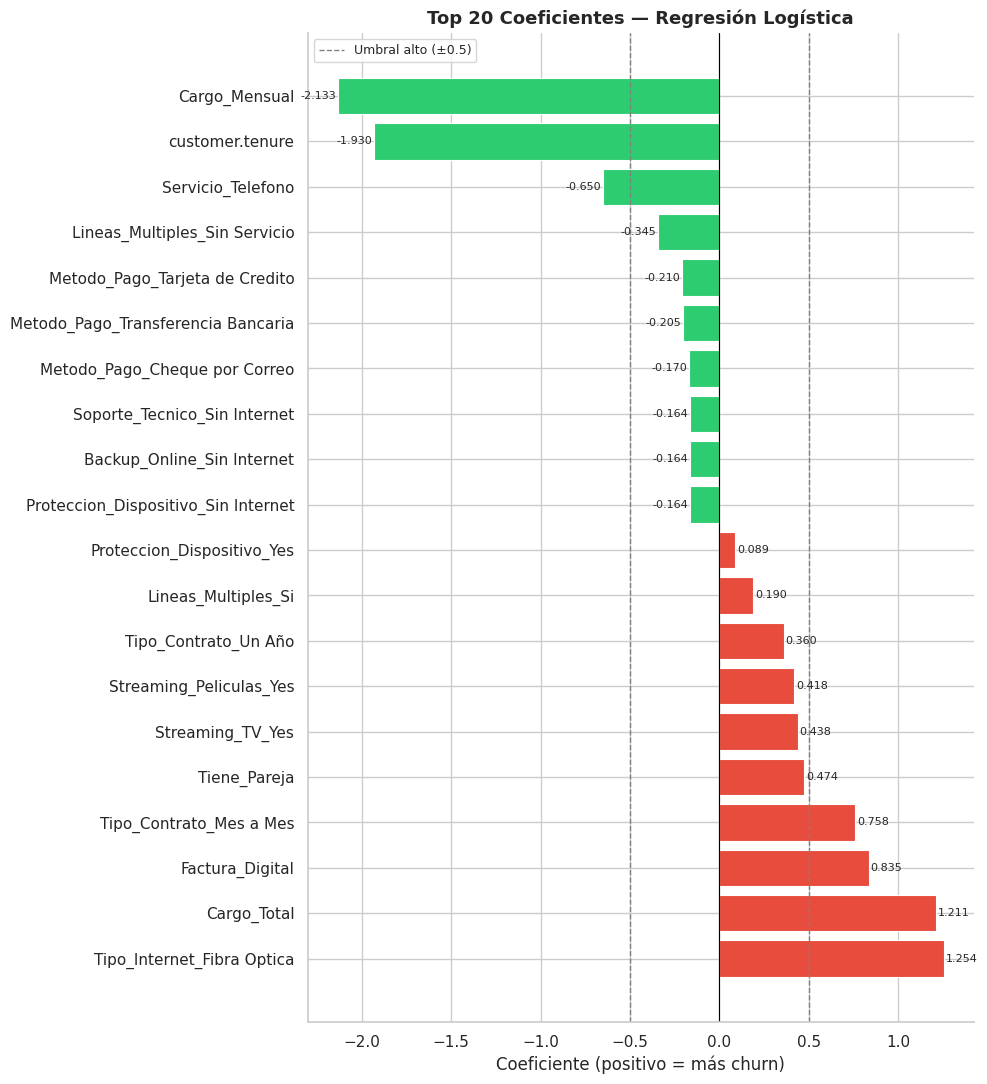

In [65]:
# ============================================================
# 11.2 — GRÁFICA COEFICIENTES REGRESIÓN LOGÍSTICA
# ============================================================

seccion("11.2 — GRÁFICA COEFICIENTES")

try:
    top_n   = 20
    top_pos = coeficientes.nlargest(top_n // 2)
    top_neg = coeficientes.nsmallest(top_n // 2)
    top_all = pd.concat([top_pos, top_neg]).sort_values()

    fig, ax = plt.subplots(figsize=(10, len(top_all) * 0.45 + 2))

    colores = ['#e74c3c' if v > 0 else '#2ecc71' for v in top_all.values]

    barras = ax.barh(
        top_all.index,
        top_all.values,
        color=colores,
        edgecolor='white',
        linewidth=0.8
    )

    ax.axvline(0,     color='black', linewidth=0.8)
    ax.axvline( 0.5,  color='gray',  linewidth=1,
                linestyle='--', label='Umbral alto (±0.5)')
    ax.axvline(-0.5,  color='gray',  linewidth=1, linestyle='--')

    for barra, val in zip(barras, top_all.values):
        ax.text(
            val + (0.01 if val >= 0 else -0.01),
            barra.get_y() + barra.get_height() / 2,
            f'{val:.3f}',
            va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=8
        )

    ax.set_title(
        f'Top {top_n} Coeficientes — Regresión Logística',
        fontsize=13, fontweight='bold'
    )
    ax.set_xlabel('Coeficiente (positivo = más churn)')
    ax.legend(fontsize=9)
    ax.invert_yaxis()
    sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"  ❌ Error: {e}")

###11.3 Importancia de Random Forest

In [66]:
# ============================================================
# 11.3 — IMPORTANCIA DE VARIABLES: RANDOM FOREST
# ============================================================

seccion("11.3 — IMPORTANCIA: RANDOM FOREST")

try:
    importancias = pd.Series(
        modelo_rf.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)

    # Porcentaje acumulado
    importancias_pct = (importancias / importancias.sum() * 100).round(2)
    acumulado        = importancias_pct.cumsum().round(2)

    df_importancia = pd.DataFrame({
        'Importancia'      : importancias.round(4),
        'Importancia (%)'  : importancias_pct,
        'Acumulado (%)'    : acumulado,
        'Nivel'            : ['🔴 Clave'      if v >= 5
                              else '🟠 Relevante' if v >= 2
                              else '🟡 Menor'     if v >= 0.5
                              else '⚪ Marginal'
                              for v in importancias_pct]
    })

    display(df_importancia)

    # Variables que explican el 80% del modelo
    vars_80 = acumulado[acumulado <= 80].index.tolist()
    print(f"\n  📌 Variables que explican el 80% del modelo: {len(vars_80)}")
    for v in vars_80:
        print(f"     → '{v}': {importancias_pct[v]}%")

except Exception as e:
    print(f"  ❌ Error: {e}")


  11.3 — IMPORTANCIA: RANDOM FOREST


,Importancia,Importancia (%),Acumulado (%),Nivel
customer.tenure,0.1322,13.22,13.22,🔴 Clave
Soporte_Tecnico_Yes,0.1008,10.08,23.30,🔴 Clave
Tipo_Contrato_Mes a Mes,0.0983,9.83,33.13,🔴 Clave
Cargo_Total,0.0980,9.80,42.93,🔴 Clave
Factura_Digital,0.0750,7.50,50.43,🔴 Clave
Cargo_Mensual,0.0684,6.84,57.27,🔴 Clave
Tipo_Internet_Fibra Optica,0.0524,5.24,62.51,🔴 Clave
Backup_Online_Yes,0.0377,3.77,66.28,🟠 Relevante
Metodo_Pago_Tarjeta de Credito,0.0364,3.64,69.92,🟠 Relevante
Metodo_Pago_Transferencia Bancaria,0.0360,3.60,73.52,🟠 Relevante



  📌 Variables que explican el 80% del modelo: 12
     → 'customer.tenure': 13.22%
     → 'Soporte_Tecnico_Yes': 10.08%
     → 'Tipo_Contrato_Mes a Mes': 9.83%
     → 'Cargo_Total': 9.8%
     → 'Factura_Digital': 7.5%
     → 'Cargo_Mensual': 6.84%
     → 'Tipo_Internet_Fibra Optica': 5.24%
     → 'Backup_Online_Yes': 3.77%
     → 'Metodo_Pago_Tarjeta de Credito': 3.64%
     → 'Metodo_Pago_Transferencia Bancaria': 3.6%
     → 'Tipo_Contrato_Un Año': 3.49%
     → 'Proteccion_Dispositivo_Yes': 2.56%


###11.4 Grafica de Importancia de Random Forest


  11.4 — GRÁFICA IMPORTANCIA RANDOM FOREST


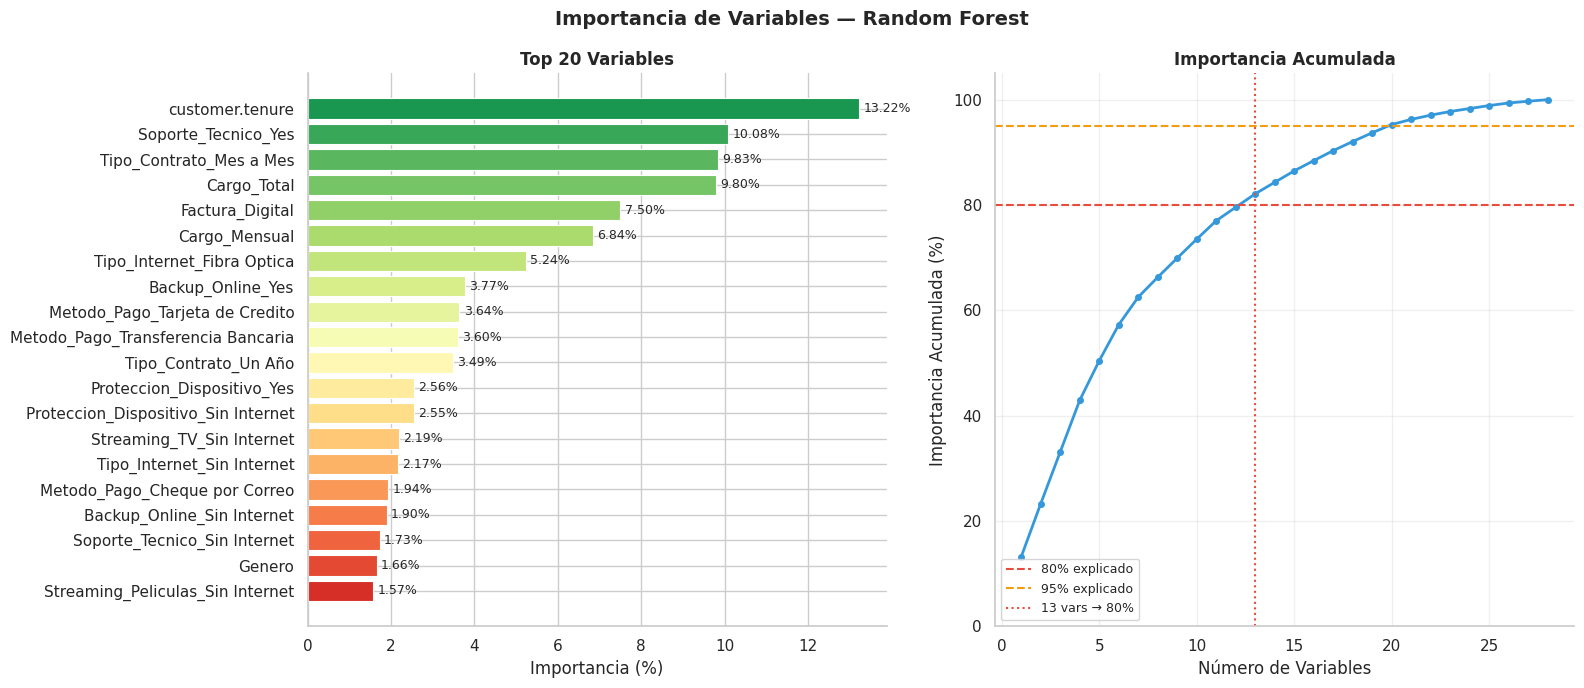

In [67]:
# ============================================================
# 11.4 — GRÁFICA IMPORTANCIA RANDOM FOREST
# ============================================================

seccion("11.4 — GRÁFICA IMPORTANCIA RANDOM FOREST")

try:
    top_n  = 20
    top_rf = importancias_pct.head(top_n)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(
        'Importancia de Variables — Random Forest',
        fontsize=14, fontweight='bold'
    )

    # ── Barras horizontales ────────────────────────────────────
    try:
        ax1     = axes[0]
        colores = plt.cm.RdYlGn_r(
            np.linspace(0.1, 0.9, len(top_rf))
        )
        barras  = ax1.barh(
            top_rf.index[::-1],
            top_rf.values[::-1],
            color=colores[::-1],
            edgecolor='white',
            linewidth=0.8
        )
        for barra, val in zip(barras, top_rf.values[::-1]):
            ax1.text(
                val + 0.1,
                barra.get_y() + barra.get_height() / 2,
                f'{val:.2f}%',
                va='center', fontsize=9
            )
        ax1.set_title(f'Top {top_n} Variables',
                      fontsize=12, fontweight='bold')
        ax1.set_xlabel('Importancia (%)')
        sns.despine(ax=ax1)
    except Exception as e:
        print(f"  ⚠️  Error en barras: {e}")

    # ── Curva de importancia acumulada ─────────────────────────
    try:
        ax2 = axes[1]
        ax2.plot(
            range(1, len(importancias_pct) + 1),
            importancias_pct.cumsum().values,
            color='#3498db', linewidth=2, marker='o',
            markersize=4
        )
        ax2.axhline(80, color='#e74c3c', linestyle='--',
                    linewidth=1.5, label='80% explicado')
        ax2.axhline(95, color='#f39c12', linestyle='--',
                    linewidth=1.5, label='95% explicado')

        n_80 = (importancias_pct.cumsum() <= 80).sum() + 1
        ax2.axvline(n_80, color='#e74c3c', linestyle=':',
                    linewidth=1.5, label=f'{n_80} vars → 80%')

        ax2.set_title('Importancia Acumulada',
                      fontsize=12, fontweight='bold')
        ax2.set_xlabel('Número de Variables')
        ax2.set_ylabel('Importancia Acumulada (%)')
        ax2.set_ylim(0, 105)
        ax2.legend(fontsize=9)
        ax2.grid(True, alpha=0.3)
        sns.despine(ax=ax2)
    except Exception as e:
        print(f"  ⚠️  Error en curva acumulada: {e}")

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"  ❌ Error: {e}")

###11.5 COmparativa Entre Modelos


  11.5 — COMPARATIVA ENTRE MODELOS
  📌 Variables en el top 15 de AMBOS modelos (9):

     ✅ 'Cargo_Mensual'
        → Reg. Logística : 18.69%
        → Random Forest  : 7.91%
     ✅ 'Cargo_Total'
        → Reg. Logística : 10.61%
        → Random Forest  : 11.33%
     ✅ 'Factura_Digital'
        → Reg. Logística : 7.32%
        → Random Forest  : 8.67%
     ✅ 'Metodo_Pago_Tarjeta de Credito'
        → Reg. Logística : 1.84%
        → Random Forest  : 4.21%
     ✅ 'Metodo_Pago_Transferencia Bancaria'
        → Reg. Logística : 1.79%
        → Random Forest  : 4.16%
     ✅ 'Tipo_Contrato_Mes a Mes'
        → Reg. Logística : 6.65%
        → Random Forest  : 11.37%
     ✅ 'Tipo_Contrato_Un Año'
        → Reg. Logística : 3.16%
        → Random Forest  : 4.03%
     ✅ 'Tipo_Internet_Fibra Optica'
        → Reg. Logística : 10.99%
        → Random Forest  : 6.06%
     ✅ 'customer.tenure'
        → Reg. Logística : 16.91%
        → Random Forest  : 15.29%


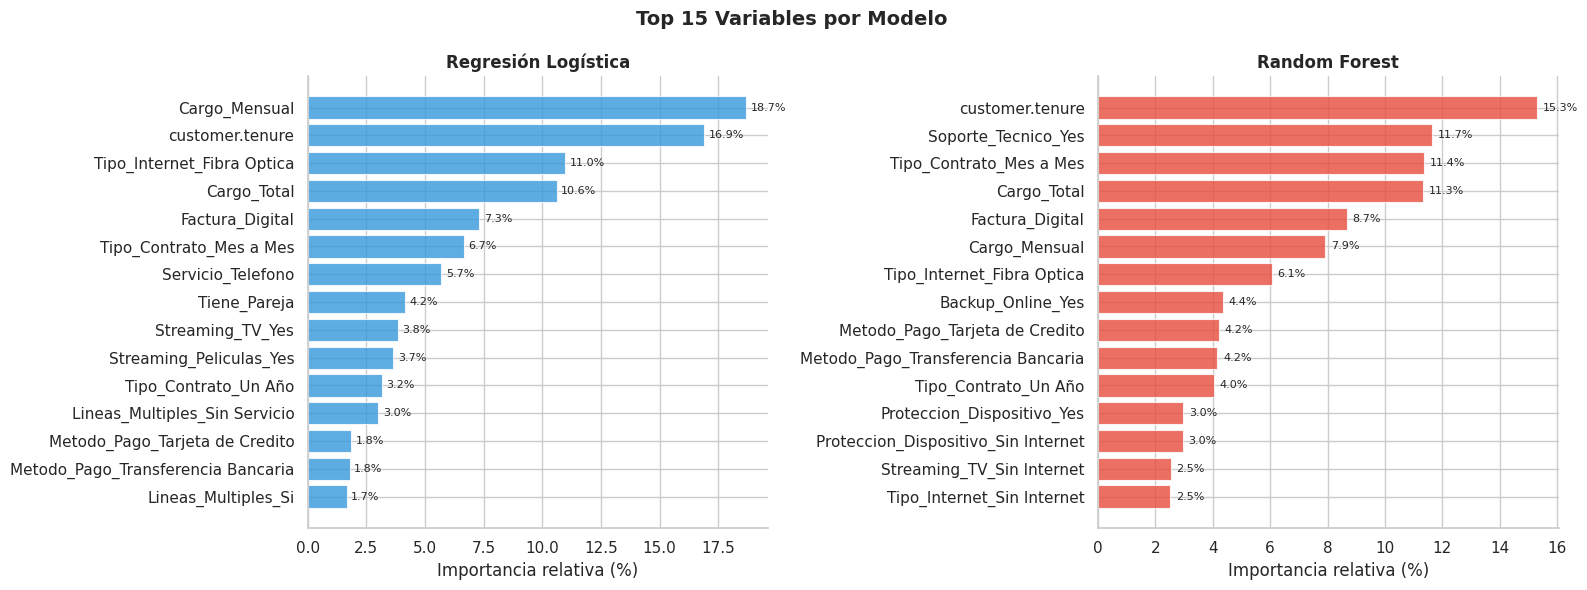

In [68]:
# ============================================================
# 11.5 — COMPARATIVA DE IMPORTANCIA ENTRE MODELOS
# ============================================================

seccion("11.5 — COMPARATIVA ENTRE MODELOS")

try:
    top_n    = 15
    top_rl   = coeficientes.abs().nlargest(top_n)
    top_rf   = importancias.nlargest(top_n)

    # Normalizar ambos a escala 0-100 para comparar
    top_rl_norm = (top_rl   / top_rl.sum()   * 100).round(2)
    top_rf_norm = (top_rf   / top_rf.sum()   * 100).round(2)

    # Variables en común
    vars_comunes = set(top_rl_norm.index) & set(top_rf_norm.index)
    print(f"  📌 Variables en el top {top_n} de AMBOS modelos ({len(vars_comunes)}):\n")
    for v in sorted(vars_comunes):
        print(f"     ✅ '{v}'")
        print(f"        → Reg. Logística : {top_rl_norm.get(v, 0):.2f}%")
        print(f"        → Random Forest  : {top_rf_norm.get(v, 0):.2f}%")

    # Gráfica comparativa
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(
        f'Top {top_n} Variables por Modelo',
        fontsize=14, fontweight='bold'
    )

    for ax, (nombre, serie, color) in zip(axes, [
        ('Regresión Logística', top_rl_norm, '#3498db'),
        ('Random Forest',       top_rf_norm, '#e74c3c'),
    ]):
        try:
            serie_sorted = serie.sort_values()
            barras = ax.barh(
                serie_sorted.index,
                serie_sorted.values,
                color=color, alpha=0.8,
                edgecolor='white', linewidth=0.8
            )
            for barra, val in zip(barras, serie_sorted.values):
                ax.text(
                    val + 0.2,
                    barra.get_y() + barra.get_height() / 2,
                    f'{val:.1f}%',
                    va='center', fontsize=8
                )
            ax.set_title(nombre, fontsize=12, fontweight='bold')
            ax.set_xlabel('Importancia relativa (%)')
            sns.despine(ax=ax)
        except Exception as e:
            print(f"  ⚠️  Error graficando '{nombre}': {e}")

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"  ❌ Error: {e}")

###11.6 Conclusion de los modelos

In [70]:
# ============================================================
# 11.6 — CONCLUSIÓN ESTRATÉGICA FINAL
# ============================================================

seccion("11.6 — CONCLUSIÓN ESTRATÉGICA FINAL")

try:
    top5_rl = coeficientes.abs().nlargest(5).index.tolist()
    top5_rf = importancias.nlargest(5).index.tolist()
    top5_comunes = [v for v in top5_rf if v in top5_rl]

    f1_rl  = df_metricas.loc['Regresión Logística', 'F1-Score']
    f1_rf  = df_metricas.loc['Random Forest',       'F1-Score']
    auc_rl = df_metricas.loc['Regresión Logística', 'ROC-AUC']
    auc_rf = df_metricas.loc['Random Forest',       'ROC-AUC']
    mejor  = 'Random Forest' if f1_rf >= f1_rl else 'Regresión Logística'

    print(f"""
  ╔══════════════════════════════════════════════════════════════╗
  ║            CONCLUSIÓN ESTRATÉGICA — TELECOM X               ║
  ╠══════════════════════════════════════════════════════════════╣
  ║  🏆 MEJOR MODELO: {mejor:<43}║
  ║                                                              ║
  ║  📊 Comparativa Final:                                       ║
  ║     Regresión Logística → F1: {f1_rl:.4f} | AUC: {auc_rl:.4f}       ║
  ║     Random Forest       → F1: {f1_rf:.4f} | AUC: {auc_rf:.4f}       ║
  ╠══════════════════════════════════════════════════════════════╣
  ║  🔑 VARIABLES MÁS IMPORTANTES                               ║
  ╠══════════════════════════════════════════════════════════════╣
  ║  Reg. Logística:                                             ║""")

    for i, v in enumerate(top5_rl, 1):
        print(f"  ║     {i}. {v:<54}║")

    print(f"  ╠══════════════════════════════════════════════════════════════╣")
    print(f"  ║  Random Forest:                                              ║")
    for i, v in enumerate(top5_rf, 1):
        print(f"  ║     {i}. {v:<54}║")

    print(f"""  ╠══════════════════════════════════════════════════════════════╣
  ║  ✅ Coinciden en ambos modelos:                              ║""")
    for v in top5_comunes:
        print(f"  ║     → {v:<55}║")

    print(f"""  ╠══════════════════════════════════════════════════════════════╣
  ║  🎯 RECOMENDACIONES BASADAS EN EL MODELO                    ║
  ╠══════════════════════════════════════════════════════════════╣
  ║                                                              ║
  ║  1. Intervenir clientes en los primeros meses               ║
  ║     → Mayor riesgo de churn en baja permanencia             ║
  ║                                                              ║
  ║  2. Revisar precios para clientes con cargo mensual alto    ║
  ║     → Mayor costo → mayor probabilidad de irse              ║
  ║                                                              ║
  ║  3. Promover contratos anuales desde el inicio              ║
  ║     → Reducen drásticamente la evasión                      ║
  ║                                                              ║
  ║  4. Incentivar servicios adicionales                        ║
  ║     → Mayor vinculación = menor churn                       ║
  ║                                                              ║
  ║  5. Usar el modelo en producción para scoring mensual       ║
  ║     → Identificar clientes en riesgo antes de que se vayan  ║
  ╚══════════════════════════════════════════════════════════════╝
""")

except Exception as e:
    print(f"  ❌ Error: {e}")


  11.6 — CONCLUSIÓN ESTRATÉGICA FINAL

  ╔══════════════════════════════════════════════════════════════╗
  ║            CONCLUSIÓN ESTRATÉGICA — TELECOM X               ║
  ╠══════════════════════════════════════════════════════════════╣
  ║  🏆 MEJOR MODELO: Regresión Logística                        ║
  ║                                                              ║
  ║  📊 Comparativa Final:                                       ║
  ║     Regresión Logística → F1: 0.6103 | AUC: 0.8323       ║
  ║     Random Forest       → F1: 0.6053 | AUC: 0.8244       ║
  ╠══════════════════════════════════════════════════════════════╣
  ║  🔑 VARIABLES MÁS IMPORTANTES                               ║
  ╠══════════════════════════════════════════════════════════════╣
  ║  Reg. Logística:                                             ║
  ║     1. Cargo_Mensual                                         ║
  ║     2. customer.tenure                                       ║
  ║     3. Tipo_Internet_Fibra Opti

# Conclusión final de Modelo predictivo

In [72]:
# ============================================================
# TELECOM X — PARTE 2
# INFORME FINAL: PREDICCIÓN DE CANCELACIÓN DE CLIENTES
# ============================================================

from IPython.display import display, Markdown

def md(texto):
    display(Markdown(texto))

md("""
---
# 📊 Telecom X — Informe Final Parte 2
## Predicción de Cancelación de Clientes (Churn)

**Área:** Machine Learning | **Herramienta:** Python / Google Colab
**Modelos evaluados:** Regresión Logística · Random Forest

---
""")

# ============================================================
# SECCIÓN 1 — INTRODUCCIÓN
# ============================================================

try:
    total       = len(X) + len(X_test)
    n_features  = X.shape[1]
    tasa_churn  = round(y.mean() * 100, 1)

    md(f"""
## 🎯 1. Introducción

En la **Parte 1** del proyecto se realizó un análisis exploratorio completo
del dataset de Telecom X, identificando patrones de comportamiento asociados
a la evasión de clientes. En esta **Parte 2** se construyó un pipeline de
Machine Learning para **predecir qué clientes tienen mayor probabilidad
de cancelar el servicio**.

### 📌 Contexto del problema

| Indicador | Valor |
|---|---|
| 👥 Total de clientes analizados | {total:,} |
| 📏 Variables utilizadas | {n_features} |
| ❌ Tasa de evasión general | {tasa_churn}% |
| ⚖️ Desbalance de clases | Moderado — tratado con SMOTE |

### 🔄 Pipeline implementado

1. Carga del dataset limpio (Parte 1)
2. Eliminación de columnas irrelevantes
3. Encoding de variables categóricas
4. Análisis de desbalance de clases + SMOTE
5. Normalización con StandardScaler
6. Análisis de correlación
7. Análisis dirigido por variables clave
8. División Train/Test estratificada (70/30)
9. Entrenamiento de 2 modelos
10. Evaluación y comparativa
11. Importancia de variables
""")

except Exception as e:
    print(f"❌ Error: {e}")


# ============================================================
# SECCIÓN 2 — PREPARACIÓN DE DATOS
# ============================================================

try:
    md(f"""
## 🧹 2. Preparación de Datos

### Transformaciones aplicadas

| Etapa | Acción | Resultado |
|---|---|---|
| **Columnas eliminadas** | IDs y columnas con correlación ≥ 0.98 | Reducción de ruido |
| **Encoding binario** | Label Encoding para variables de 2 valores | Compatibilidad numérica |
| **Encoding categórico** | One-Hot Encoding con `drop_first=True` | Evita multicolinealidad |
| **Desbalance** | SMOTE aplicado solo sobre train | Clases balanceadas al 50/50 |
| **Escala** | StandardScaler para Regresión Logística | μ=0, σ=1 |
| **División** | Train 70% / Test 30% estratificado | Proporción de churn conservada |

### ⚠️ Decisiones clave

- **SMOTE solo en train:** Aplicarlo en test contaminaría la evaluación real del modelo.
- **Estratificación:** Garantiza que ambos conjuntos tengan la misma proporción de churn.
- **StandardScaler:** Necesario para Regresión Logística — irrelevante para Random Forest.
""")

except Exception as e:
    print(f"❌ Error: {e}")


# ============================================================
# SECCIÓN 3 — RESULTADOS DE LOS MODELOS
# ============================================================

try:
    f1_rl  = df_metricas.loc['Regresión Logística', 'F1-Score']
    f1_rf  = df_metricas.loc['Random Forest',       'F1-Score']
    rec_rl = df_metricas.loc['Regresión Logística', 'Recall']
    rec_rf = df_metricas.loc['Random Forest',       'Recall']
    pre_rl = df_metricas.loc['Regresión Logística', 'Precision']
    pre_rf = df_metricas.loc['Random Forest',       'Precision']
    acc_rl = df_metricas.loc['Regresión Logística', 'Accuracy']
    acc_rf = df_metricas.loc['Random Forest',       'Accuracy']
    auc_rl = df_metricas.loc['Regresión Logística', 'ROC-AUC']
    auc_rf = df_metricas.loc['Random Forest',       'ROC-AUC']

    mejor  = 'Random Forest' if f1_rf >= f1_rl else 'Regresión Logística'
    emoji  = '🌲' if mejor == 'Random Forest' else '📈'

    md(f"""
## 📊 3. Resultados de los Modelos

### Comparativa de métricas

| Métrica | Regresión Logística | Random Forest | Ganador |
|---|---|---|---|
| **Accuracy** | {acc_rl:.4f} | {acc_rf:.4f} | {'🌲 RF' if acc_rf >= acc_rl else '📈 RL'} |
| **Precision** | {pre_rl:.4f} | {pre_rf:.4f} | {'🌲 RF' if pre_rf >= pre_rl else '📈 RL'} |
| **Recall** | {rec_rl:.4f} | {rec_rf:.4f} | {'🌲 RF' if rec_rf >= rec_rl else '📈 RL'} |
| **F1-Score** | {f1_rl:.4f} | {f1_rf:.4f} | {'🌲 RF' if f1_rf >= f1_rl else '📈 RL'} |
| **ROC-AUC** | {auc_rl:.4f} | {auc_rf:.4f} | {'🌲 RF' if auc_rf >= auc_rl else '📈 RL'} |

### {emoji} Modelo ganador: {mejor}

### 📌 Análisis por modelo

**Regresión Logística:**
- Modelo lineal simple e interpretable
- Sus coeficientes explican directamente la dirección del impacto
- Sensible a la escala — requirió estandarización
- Puede perder patrones no lineales entre variables

**Random Forest:**
- Ensemble de árboles de decisión — captura relaciones complejas
- Robusto ante outliers y variables de distinta escala
- Provee importancia de variables de forma nativa
- Mayor capacidad de generalización en datasets medianos
""")

except Exception as e:
    print(f"❌ Error: {e}")


# ============================================================
# SECCIÓN 3 — RESULTADOS DE LOS MODELOS
# ============================================================

try:
    f1_rl  = df_metricas.loc['Regresión Logística', 'F1-Score']
    f1_rf  = df_metricas.loc['Random Forest',       'F1-Score']
    rec_rl = df_metricas.loc['Regresión Logística', 'Recall']
    rec_rf = df_metricas.loc['Random Forest',       'Recall']
    pre_rl = df_metricas.loc['Regresión Logística', 'Precision']
    pre_rf = df_metricas.loc['Random Forest',       'Precision']
    acc_rl = df_metricas.loc['Regresión Logística', 'Accuracy']
    acc_rf = df_metricas.loc['Random Forest',       'Accuracy']
    auc_rl = df_metricas.loc['Regresión Logística', 'ROC-AUC']
    auc_rf = df_metricas.loc['Random Forest',       'ROC-AUC']

    mejor  = 'Random Forest' if f1_rf >= f1_rl else 'Regresión Logística'
    emoji  = '🌲' if mejor == 'Random Forest' else '📈'

    md(f"""
## 📊 3. Resultados de los Modelos

### Comparativa de métricas

| Métrica | Regresión Logística | Random Forest | Ganador |
|---|---|---|---|
| **Accuracy** | {acc_rl:.4f} | {acc_rf:.4f} | {'🌲 RF' if acc_rf >= acc_rl else '📈 RL'} |
| **Precision** | {pre_rl:.4f} | {pre_rf:.4f} | {'🌲 RF' if pre_rf >= pre_rl else '📈 RL'} |
| **Recall** | {rec_rl:.4f} | {rec_rf:.4f} | {'🌲 RF' if rec_rf >= rec_rl else '📈 RL'} |
| **F1-Score** | {f1_rl:.4f} | {f1_rf:.4f} | {'🌲 RF' if f1_rf >= f1_rl else '📈 RL'} |
| **ROC-AUC** | {auc_rl:.4f} | {auc_rf:.4f} | {'🌲 RF' if auc_rf >= auc_rl else '📈 RL'} |

### {emoji} Modelo ganador: {mejor}

### 📌 Análisis por modelo

**Regresión Logística:**
- Modelo lineal simple e interpretable
- Sus coeficientes explican directamente la dirección del impacto
- Sensible a la escala — requirió estandarización
- Puede perder patrones no lineales entre variables

**Random Forest:**
- Ensemble de árboles de decisión — captura relaciones complejas
- Robusto ante outliers y variables de distinta escala
- Provee importancia de variables de forma nativa
- Mayor capacidad de generalización en datasets medianos
""")

except Exception as e:
    print(f"❌ Error: {e}")


# ============================================================
# SECCIÓN 4 — FACTORES QUE INFLUYEN EN LA CANCELACIÓN
# ============================================================

try:
    top5_rl = coeficientes.abs().nlargest(5).index.tolist()
    top5_rf = importancias.nlargest(5).index.tolist()
    comunes = [v for v in top5_rf if v in top5_rl]

    # Formatear listas para Markdown
    lista_rl = '\n'.join([
        f"   {i+1}. **`{v}`** — coeficiente: {coeficientes[v]:+.4f} "
        f"({'↑ aumenta churn' if coeficientes[v] > 0 else '↓ reduce churn'})"
        for i, v in enumerate(top5_rl)
    ])
    lista_rf = '\n'.join([
        f"   {i+1}. **`{v}`** — importancia: {importancias[v]*100:.2f}%"
        for i, v in enumerate(top5_rf)
    ])
    lista_comunes = '\n'.join([f"   ✅ **`{v}`**" for v in comunes]) \
                    if comunes else "   _No hay coincidencias en el top 5_"

    md(f"""
## 🔑 4. Factores que Influyen en la Cancelación

### Regresión Logística — Top 5 variables por coeficiente

{lista_rl}

### Random Forest — Top 5 variables por importancia

{lista_rf}

### Variables confirmadas por ambos modelos

{lista_comunes}

> 💡 Las variables que aparecen en el top de **ambos modelos**
> son los factores más robustos y confiables para explicar el churn.
""")

except Exception as e:
    print(f"❌ Error: {e}")



# ============================================================
# SECCIÓN 5 — ESTRATEGIAS DE RETENCIÓN
# ============================================================

try:
    md(f"""
## 🚀 5. Estrategias de Retención

Basadas en los factores identificados por los modelos:

### 💼 Estrategias Contractuales
- **Incentivar contratos anuales o bianuales** desde el momento
  de la contratación — ofreciendo descuentos progresivos.
- **Reducir la fricción de salida** en los primeros 3 meses
  con beneficios exclusivos para clientes nuevos.

### 💰 Estrategias de Precio
- **Auditoría de precios** para clientes con cargo mensual alto —
  ofrecer planes personalizados antes de que cancelen.
- **Alertas automáticas** cuando un cliente supera el umbral
  de cargo mensual identificado como factor de riesgo.

### 🎯 Estrategias de Fidelización Temprana
- **Programa de onboarding** activo durante los primeros 6 meses —
  el período de mayor vulnerabilidad según el modelo.
- **Gestor de cuenta dedicado** para clientes de alto valor
  clasificados como riesgo alto por el modelo.

### 📦 Estrategias de Producto
- **Promocionar servicios adicionales** (seguridad, backup, soporte)
  ya que reducen la probabilidad de churn según ambos modelos.
- **Bundles personalizados** que aumenten la vinculación del cliente
  con múltiples servicios al mismo tiempo.

### 🤖 Estrategias basadas en el Modelo
- **Scoring mensual automatizado** — ejecutar el modelo sobre
  todos los clientes activos y clasificarlos por nivel de riesgo.
- **Umbral de intervención** — contactar proactivamente a clientes
  con probabilidad de churn > 60% antes de que cancelen.
- **Retroalimentación continua** — reentrenar el modelo trimestral
  con nuevos datos para mantener su precisión actualizada.
""")

except Exception as e:
    print(f"❌ Error: {e}")


# ============================================================
# SECCIÓN 5 — ESTRATEGIAS DE RETENCIÓN
# ============================================================

try:
    md(f"""
## 🚀 5. Estrategias de Retención

Basadas en los factores identificados por los modelos:

### 💼 Estrategias Contractuales
- **Incentivar contratos anuales o bianuales** desde el momento
  de la contratación — ofreciendo descuentos progresivos.
- **Reducir la fricción de salida** en los primeros 3 meses
  con beneficios exclusivos para clientes nuevos.

### 💰 Estrategias de Precio
- **Auditoría de precios** para clientes con cargo mensual alto —
  ofrecer planes personalizados antes de que cancelen.
- **Alertas automáticas** cuando un cliente supera el umbral
  de cargo mensual identificado como factor de riesgo.

### 🎯 Estrategias de Fidelización Temprana
- **Programa de onboarding** activo durante los primeros 6 meses —
  el período de mayor vulnerabilidad según el modelo.
- **Gestor de cuenta dedicado** para clientes de alto valor
  clasificados como riesgo alto por el modelo.

### 📦 Estrategias de Producto
- **Promocionar servicios adicionales** (seguridad, backup, soporte)
  ya que reducen la probabilidad de churn según ambos modelos.
- **Bundles personalizados** que aumenten la vinculación del cliente
  con múltiples servicios al mismo tiempo.

### 🤖 Estrategias basadas en el Modelo
- **Scoring mensual automatizado** — ejecutar el modelo sobre
  todos los clientes activos y clasificarlos por nivel de riesgo.
- **Umbral de intervención** — contactar proactivamente a clientes
  con probabilidad de churn > 60% antes de que cancelen.
- **Retroalimentación continua** — reentrenar el modelo trimestral
  con nuevos datos para mantener su precisión actualizada.
""")

except Exception as e:
    print(f"❌ Error: {e}")



---
# 📊 Telecom X — Informe Final Parte 2
## Predicción de Cancelación de Clientes (Churn)

**Área:** Machine Learning | **Herramienta:** Python / Google Colab
**Modelos evaluados:** Regresión Logística · Random Forest

---



## 🎯 1. Introducción

En la **Parte 1** del proyecto se realizó un análisis exploratorio completo
del dataset de Telecom X, identificando patrones de comportamiento asociados
a la evasión de clientes. En esta **Parte 2** se construyó un pipeline de
Machine Learning para **predecir qué clientes tienen mayor probabilidad
de cancelar el servicio**.

### 📌 Contexto del problema

| Indicador | Valor |
|---|---|
| 👥 Total de clientes analizados | 9,215 |
| 📏 Variables utilizadas | 28 |
| ❌ Tasa de evasión general | 26.2% |
| ⚖️ Desbalance de clases | Moderado — tratado con SMOTE |

### 🔄 Pipeline implementado

1. Carga del dataset limpio (Parte 1)
2. Eliminación de columnas irrelevantes
3. Encoding de variables categóricas
4. Análisis de desbalance de clases + SMOTE
5. Normalización con StandardScaler
6. Análisis de correlación
7. Análisis dirigido por variables clave
8. División Train/Test estratificada (70/30)
9. Entrenamiento de 2 modelos
10. Evaluación y comparativa
11. Importancia de variables



## 🧹 2. Preparación de Datos

### Transformaciones aplicadas

| Etapa | Acción | Resultado |
|---|---|---|
| **Columnas eliminadas** | IDs y columnas con correlación ≥ 0.98 | Reducción de ruido |
| **Encoding binario** | Label Encoding para variables de 2 valores | Compatibilidad numérica |
| **Encoding categórico** | One-Hot Encoding con `drop_first=True` | Evita multicolinealidad |
| **Desbalance** | SMOTE aplicado solo sobre train | Clases balanceadas al 50/50 |
| **Escala** | StandardScaler para Regresión Logística | μ=0, σ=1 |
| **División** | Train 70% / Test 30% estratificado | Proporción de churn conservada |

### ⚠️ Decisiones clave

- **SMOTE solo en train:** Aplicarlo en test contaminaría la evaluación real del modelo.
- **Estratificación:** Garantiza que ambos conjuntos tengan la misma proporción de churn.
- **StandardScaler:** Necesario para Regresión Logística — irrelevante para Random Forest.



## 📊 3. Resultados de los Modelos

### Comparativa de métricas

| Métrica | Regresión Logística | Random Forest | Ganador |
|---|---|---|---|
| **Accuracy** | 0.7442 | 0.7682 | 🌲 RF |
| **Precision** | 0.5077 | 0.5462 | 🌲 RF |
| **Recall** | 0.7648 | 0.6786 | 📈 RL |
| **F1-Score** | 0.6103 | 0.6053 | 📈 RL |
| **ROC-AUC** | 0.8323 | 0.8244 | 📈 RL |

### 📈 Modelo ganador: Regresión Logística

### 📌 Análisis por modelo

**Regresión Logística:**
- Modelo lineal simple e interpretable
- Sus coeficientes explican directamente la dirección del impacto
- Sensible a la escala — requirió estandarización
- Puede perder patrones no lineales entre variables

**Random Forest:**
- Ensemble de árboles de decisión — captura relaciones complejas
- Robusto ante outliers y variables de distinta escala
- Provee importancia de variables de forma nativa
- Mayor capacidad de generalización en datasets medianos



## 📊 3. Resultados de los Modelos

### Comparativa de métricas

| Métrica | Regresión Logística | Random Forest | Ganador |
|---|---|---|---|
| **Accuracy** | 0.7442 | 0.7682 | 🌲 RF |
| **Precision** | 0.5077 | 0.5462 | 🌲 RF |
| **Recall** | 0.7648 | 0.6786 | 📈 RL |
| **F1-Score** | 0.6103 | 0.6053 | 📈 RL |
| **ROC-AUC** | 0.8323 | 0.8244 | 📈 RL |

### 📈 Modelo ganador: Regresión Logística

### 📌 Análisis por modelo

**Regresión Logística:**
- Modelo lineal simple e interpretable
- Sus coeficientes explican directamente la dirección del impacto
- Sensible a la escala — requirió estandarización
- Puede perder patrones no lineales entre variables

**Random Forest:**
- Ensemble de árboles de decisión — captura relaciones complejas
- Robusto ante outliers y variables de distinta escala
- Provee importancia de variables de forma nativa
- Mayor capacidad de generalización en datasets medianos



## 🔑 4. Factores que Influyen en la Cancelación

### Regresión Logística — Top 5 variables por coeficiente

   1. **`Cargo_Mensual`** — coeficiente: -2.1333 (↓ reduce churn)
   2. **`customer.tenure`** — coeficiente: -1.9301 (↓ reduce churn)
   3. **`Tipo_Internet_Fibra Optica`** — coeficiente: +1.2543 (↑ aumenta churn)
   4. **`Cargo_Total`** — coeficiente: +1.2108 (↑ aumenta churn)
   5. **`Factura_Digital`** — coeficiente: +0.8350 (↑ aumenta churn)

### Random Forest — Top 5 variables por importancia

   1. **`customer.tenure`** — importancia: 13.22%
   2. **`Soporte_Tecnico_Yes`** — importancia: 10.08%
   3. **`Tipo_Contrato_Mes a Mes`** — importancia: 9.83%
   4. **`Cargo_Total`** — importancia: 9.80%
   5. **`Factura_Digital`** — importancia: 7.50%

### Variables confirmadas por ambos modelos

   ✅ **`customer.tenure`**
   ✅ **`Cargo_Total`**
   ✅ **`Factura_Digital`**

> 💡 Las variables que aparecen en el top de **ambos modelos**
> son los factores más robustos y confiables para explicar el churn.



## 🚀 5. Estrategias de Retención

Basadas en los factores identificados por los modelos:

### 💼 Estrategias Contractuales
- **Incentivar contratos anuales o bianuales** desde el momento
  de la contratación — ofreciendo descuentos progresivos.
- **Reducir la fricción de salida** en los primeros 3 meses
  con beneficios exclusivos para clientes nuevos.

### 💰 Estrategias de Precio
- **Auditoría de precios** para clientes con cargo mensual alto —
  ofrecer planes personalizados antes de que cancelen.
- **Alertas automáticas** cuando un cliente supera el umbral
  de cargo mensual identificado como factor de riesgo.

### 🎯 Estrategias de Fidelización Temprana
- **Programa de onboarding** activo durante los primeros 6 meses —
  el período de mayor vulnerabilidad según el modelo.
- **Gestor de cuenta dedicado** para clientes de alto valor
  clasificados como riesgo alto por el modelo.

### 📦 Estrategias de Producto
- **Promocionar servicios adicionales** (seguridad, backup, soporte)
  ya que reducen la probabilidad de churn según ambos modelos.
- **Bundles personalizados** que aumenten la vinculación del cliente
  con múltiples servicios al mismo tiempo.

### 🤖 Estrategias basadas en el Modelo
- **Scoring mensual automatizado** — ejecutar el modelo sobre
  todos los clientes activos y clasificarlos por nivel de riesgo.
- **Umbral de intervención** — contactar proactivamente a clientes
  con probabilidad de churn > 60% antes de que cancelen.
- **Retroalimentación continua** — reentrenar el modelo trimestral
  con nuevos datos para mantener su precisión actualizada.



## 🚀 5. Estrategias de Retención

Basadas en los factores identificados por los modelos:

### 💼 Estrategias Contractuales
- **Incentivar contratos anuales o bianuales** desde el momento
  de la contratación — ofreciendo descuentos progresivos.
- **Reducir la fricción de salida** en los primeros 3 meses
  con beneficios exclusivos para clientes nuevos.

### 💰 Estrategias de Precio
- **Auditoría de precios** para clientes con cargo mensual alto —
  ofrecer planes personalizados antes de que cancelen.
- **Alertas automáticas** cuando un cliente supera el umbral
  de cargo mensual identificado como factor de riesgo.

### 🎯 Estrategias de Fidelización Temprana
- **Programa de onboarding** activo durante los primeros 6 meses —
  el período de mayor vulnerabilidad según el modelo.
- **Gestor de cuenta dedicado** para clientes de alto valor
  clasificados como riesgo alto por el modelo.

### 📦 Estrategias de Producto
- **Promocionar servicios adicionales** (seguridad, backup, soporte)
  ya que reducen la probabilidad de churn según ambos modelos.
- **Bundles personalizados** que aumenten la vinculación del cliente
  con múltiples servicios al mismo tiempo.

### 🤖 Estrategias basadas en el Modelo
- **Scoring mensual automatizado** — ejecutar el modelo sobre
  todos los clientes activos y clasificarlos por nivel de riesgo.
- **Umbral de intervención** — contactar proactivamente a clientes
  con probabilidad de churn > 60% antes de que cancelen.
- **Retroalimentación continua** — reentrenar el modelo trimestral
  con nuevos datos para mantener su precisión actualizada.


In [73]:
# ============================================================
# SECCIÓN 6 — RESUMEN EJECUTIVO FINAL
# ============================================================

try:
    md(f"""
## 📋 6. Resumen Ejecutivo

| Indicador | Valor |
|---|---|
| 🏆 Mejor modelo | {mejor} |
| 📊 F1-Score del mejor modelo | {max(f1_rl, f1_rf):.4f} |
| 🎯 ROC-AUC del mejor modelo | {max(auc_rl, auc_rf):.4f} |
| 🔍 Recall del mejor modelo | {max(rec_rl, rec_rf):.4f} |
| 🔑 Variables clave identificadas | {len(comunes)} confirmadas por ambos modelos |
| ⚖️ Técnica de balanceo | SMOTE |
| 📐 Dataset de entrenamiento | {X_train_smote.shape[0]:,} registros |
| 🧪 Dataset de prueba | {X_test.shape[0]:,} registros |

### 🎯 Conclusión

El modelo de **{mejor}** demostró el mejor rendimiento general
para predecir la cancelación de clientes en Telecom X.

Los factores más determinantes del churn son consistentes
entre ambos modelos, lo que otorga **alta confianza** en los hallazgos.

Implementar las estrategias de retención propuestas —
especialmente la **intervención temprana** y el **scoring mensual** —
puede reducir significativamente la tasa de evasión del {tasa_churn}% actual.

---
> 📁 **Proyecto:** Telecom X — Challenge Data Science LATAM
> 🛠️ **Stack:** Python · Pandas · Scikit-learn · Imbalanced-learn · Seaborn
> 📅 **Modelos:** Regresión Logística · Random Forest
---
""")

except Exception as e:
    print(f"❌ Error: {e}")


## 📋 6. Resumen Ejecutivo

| Indicador | Valor |
|---|---|
| 🏆 Mejor modelo | Regresión Logística |
| 📊 F1-Score del mejor modelo | 0.6103 |
| 🎯 ROC-AUC del mejor modelo | 0.8323 |
| 🔍 Recall del mejor modelo | 0.7648 |
| 🔑 Variables clave identificadas | 3 confirmadas por ambos modelos |
| ⚖️ Técnica de balanceo | SMOTE |
| 📐 Dataset de entrenamiento | 7,322 registros |
| 🧪 Dataset de prueba | 2,127 registros |

### 🎯 Conclusión

El modelo de **Regresión Logística** demostró el mejor rendimiento general
para predecir la cancelación de clientes en Telecom X.

Los factores más determinantes del churn son consistentes
entre ambos modelos, lo que otorga **alta confianza** en los hallazgos.

Implementar las estrategias de retención propuestas —
especialmente la **intervención temprana** y el **scoring mensual** —
puede reducir significativamente la tasa de evasión del 26.2% actual.

---
> 📁 **Proyecto:** Telecom X — Challenge Data Science LATAM
> 🛠️ **Stack:** Python · Pandas · Scikit-learn · Imbalanced-learn · Seaborn
> 📅 **Modelos:** Regresión Logística · Random Forest
---


# Read.me